# SeamlessM4T v2 Large: Structured Compression 2.3B to ~1B

## Compression Pipeline
| Phase | Technique | Paper | Expected |
|-------|-----------|-------|----------|
| 0 | Baseline benchmark | - | reference |
| 1 | Vocabulary/Embedding pruning | Asahi (EMNLP 2023) | -200M |
| 2 | Text encoder removal (S2S-only) | Architecture analysis | -350M |
| 3 | Text decoder iterative layer pruning | Moslem (IWSLT 2025) | -150M |
| 4 | Speech encoder iterative layer pruning | ShortGPT (ACL 2025) | -150M |
| 5 | Width pruning (FLAP on FFN + heads) | FLAP (AAAI 2024) | -200M |
| 6 | T2U model pruning | Iterative layer pruning | -50M |
| 7 | Recovery fine-tuning (LoRA + S2TT CE) | Moslem (IWSLT 2025) | quality up |
| 8 | Final benchmark + paper table | - | - |

## Setup Cells 1-8
Run these at the **start of every** Kaggle session.

In [1]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil
import warnings; warnings.filterwarnings('ignore')

# ── Platform detection ────────────────────────────────────────────────────────
ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE  # safe assumption for this notebook
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

# ── Path layout ───────────────────────────────────────────────────────────────
# Kaggle : rclone syncs to/from gdrive:cse465v5/  ←→  /kaggle/working/
# Colab  : Google Drive is mounted at /content/drive/MyDrive/
#          We work DIRECTLY inside the mounted folder — no copying, no rclone.
GDRIVE_MOUNT   = '/content/drive/MyDrive/cse465v5'   # <-- your Drive folder
KAGGLE_WORK    = '/kaggle/working'

WORK_DIR  = KAGGLE_WORK    if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'

# rclone remote root (Kaggle only — unused on Colab)
GDRIVE_ROOT = 'gdrive:cse465v5'


In [2]:
# Mount Google Drive — only needed on Colab.
# On Kaggle, rclone handles the remote; skip this cell entirely there.
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f'Drive mounted. Working folder: {GDRIVE_MOUNT}')
    # if not os.path.exists(GDRIVE_MOUNT):
    #     os.makedirs(GDRIVE_MOUNT, exist_ok=True)
    #     print(f'Created {GDRIVE_MOUNT}')
    # else:
    #     print(f'Folder exists: {GDRIVE_MOUNT}')
else:
    print('Kaggle: skipping Drive mount.')

Kaggle: skipping Drive mount.


In [3]:
for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')
print(f'Checkpts : {CKPT_DIR}')

Platform : kaggle
Work dir : /kaggle/working
Checkpts : /kaggle/working/checkpoints


In [4]:
# rclone is only needed on Kaggle. On Colab we use the mounted Drive directly.
if ON_KAGGLE:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
    print(ver.stdout.split('\n')[0])
else:
    print('Colab: rclone not needed — using mounted Google Drive directly.')
    print(f'Drive path: {GDRIVE_MOUNT}')
    if not os.path.exists('/content/drive/MyDrive'):
        print('WARNING: Drive does not appear to be mounted. Run Cell 22 (drive.mount) first.')
    else:
        print('Drive mount: OK')

rclone v1.73.4


In [5]:
def _get_secret(key):
    """Fetch a secret from Kaggle Secrets or Colab userdata."""
    if ON_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret(key)
        except Exception as e:
            raise RuntimeError(f'Kaggle secret {key!r} not found: {e}')
    else:
        try:
            from google.colab import userdata
            return userdata.get(key)
        except Exception as e:
            raise RuntimeError(
                f'Colab secret {key!r} not found. '
                f'Add it via the 🔑 Secrets panel in Colab: {e}')

if ON_KAGGLE:
    # rclone config is only needed on Kaggle
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive root:' if r.returncode == 0 else 'rclone FAILED:')
    print(r.stdout[:300] or r.stderr[:300])
else:
    print('Colab: skipping rclone config — using mounted Drive.')
    print(f'Working directory on Drive: {WORK_DIR}')

Drive root:
           0 2026-04-11 05:42:37        -1 .ipynb_checkpoints
           0 2026-04-17 11:03:10        -1 Colab Notebooks
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-12 12:42:04        -1 cse465v5
           0 2026-04-1


In [6]:
if ON_KAGGLE:
    print('[audio] Syncing audio to rclone remote...')
    r = subprocess.run(
        f'rclone sync "{AUDIO_DIR}/" "{GDRIVE_ROOT}/audio/"',
        shell=True,
        capture_output=True,
        text=True
    )

    if r.returncode != 0:
        print(f'[audio] WARNING: {r.stderr[:300]}')
    else:
        print('[audio] Sync complete.')

else:
    print(f'[audio] Colab: files already in Google Drive at {AUDIO_DIR} (no sync needed)')

[audio] Syncing audio to rclone remote...
[audio] Sync complete.


In [7]:
if ON_KAGGLE:
    print('[figures] Syncing figures to rclone remote...')
    r = subprocess.run(
        f'rclone sync "{FIG_DIR}/" "{GDRIVE_ROOT}/figures/"',
        shell=True,
        capture_output=True,
        text=True
    )

    if r.returncode != 0:
        print(f'[figure] WARNING: {r.stderr[:300]}')
    else:
        print('[figure] Sync complete.')

else:
    print(f'[figure] Colab: files already in Google Drive at {FIG_DIR} (no sync needed)')

[figures] Syncing figures to rclone remote...
[figure] Sync complete.


In [8]:
# !rm -rf /content/drive

In [9]:
# !fusermount -u /content/drive

In [10]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers', 'datasets', 'torchaudio', 'speechbrain',
    'peft', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn',
], check=True)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 39.9 MB/s eta 0:00:00
All packages installed.


In [11]:
if ON_KAGGLE:
    print('Pulling checkpoints from Google Drive via rclone...')
    r = subprocess.run(
        f'rclone sync {GDRIVE_ROOT}/checkpoints/ {CKPT_DIR}/',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'WARNING: rclone sync failed:\n{r.stderr[:300]}')
    else:
        print('rclone sync OK.')
else:
    print(f'Colab: checkpoints are on mounted Drive at {CKPT_DIR}')
    print('No sync needed — reading directly from Drive.')

files = sorted(os.listdir(CKPT_DIR)) if os.path.isdir(CKPT_DIR) else []
if files:
    print(f'{len(files)} file(s) found:')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>8.1f} MB')
else:
    print('No checkpoints yet.')

Pulling checkpoints from Google Drive via rclone...
rclone sync OK.
16 file(s) found:
  all_summaries_step000000.pt                                  0.0 MB
  phase0_baseline_step000000.pt                                0.0 MB
  phase1_benchmark_step000000.pt                               0.0 MB
  phase1_vocab_step000000.pt                                   0.1 MB
  phase3_benchmark_step000000.pt                               0.0 MB
  phase3_dec_pruning_step000000.pt                             0.0 MB
  phase4_benchmark_step000000.pt                               0.0 MB
  phase4_enc_pruning_step000000.pt                             0.0 MB
  phase5_benchmark2_step000000.pt                              0.0 MB
  phase5_benchmark_step000000.pt                               0.0 MB
  phase5_flap (base)_step000000.pt                             0.0 MB
  phase5_flap_step000000.pt                                    0.0 MB
  phase6_benchmark_step000000.pt                               0.0 MB
  ph

In [12]:
# os.listdir('/content/drive/MyDrive/cse465v5/checkpoints')

In [13]:
import torch
from datetime import datetime

_CUSTOM_STATE_FILE = '_custom_state.pt'
_PRUNING_MANIFEST = 'pruning_manifest.pt'  # optional extra metadata (e.g. T2U removal log copy)

def _rclone_push(local_path, remote_subpath):
    """Push a single file or folder to rclone remote. Kaggle only."""
    if not ON_KAGGLE:
        return  # Colab writes directly to Drive — nothing to push
    r = subprocess.run(
        f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/"',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[rclone] WARNING: push failed for {local_path}: {r.stderr[:200]}')

def _rclone_pull_model(stage_name):
    """Pull models/<stage_name> from rclone remote into local MODEL_DIR. Kaggle only."""
    if not ON_KAGGLE:
        return  # Colab reads directly from Drive — nothing to pull
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    r = subprocess.run(
        f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{local}/"',
        shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'[rclone] model pull failed for {stage_name}: {r.stderr[:300]}')
    print(f'[rclone] Pulled {stage_name} → {local}')

# ── Checkpoint helpers ────────────────────────────────────────────────────────

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    path  = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')

    # On Kaggle, push to rclone remote so it survives session end
    if ON_KAGGLE:
        _rclone_push(path, 'checkpoints')

    # Prune old local copies
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        if os.path.exists(f):
            os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive(names=None):
    if ON_KAGGLE:
        print('[ckpt] Syncing checkpoints from rclone remote...')
        r = subprocess.run(
            f'rclone sync "{GDRIVE_ROOT}/checkpoints/" "{CKPT_DIR}/"',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[ckpt] WARNING: {r.stderr[:300]}')
    else:
        print(f'[ckpt] Colab: reading directly from {CKPT_DIR} (no sync needed)')

    files = sorted(os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else []
    print(f'[ckpt] {len(files)} checkpoint(s) available')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>7.1f} MB')

# ── Config sync: make config.json match actual architecture ───────────────────

def _find_layers(component):
    """Find the main transformer-layer ModuleList inside a component."""
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0:
            return mod
    return None


def _get_t2u_encoder_decoder(mdl):
    """SeamlessM4Tv2: stacks live under t2u_model.model.{encoder,decoder}, not t2u_model.{encoder,decoder}."""
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is None:
        return None, None
    inner = getattr(t2u, 'model', None)
    if inner is None:
        return None, None
    enc = getattr(inner, 'encoder', None)
    dec = getattr(inner, 'decoder', None)
    return enc, dec


def _infer_t2u_layer_counts_from_checkpoint_dir(model_dir):
    """
    Infer actual T2U encoder/decoder depth from saved weights (fixes legacy saves
    where config.json still had full 6+6 layers).
    Self-contained (no load_hf_weights_dict): works in minimal notebooks and any cell order.
    Returns (enc_n, dec_n) or (None, None) if not inferable.
    """
    import os
    sd = None
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            sd = load_file(safe)
        except ImportError:
            pass
    if sd is None:
        pt = os.path.join(model_dir, 'pytorch_model.bin')
        if os.path.isfile(pt):
            blob = torch.load(pt, map_location='cpu', weights_only=False)
            if isinstance(blob, dict) and 'model' in blob:
                inner = blob['model']
                if isinstance(inner, dict):
                    sd = inner
                else:
                    sd = blob
            else:
                sd = blob
    if not sd:
        return None, None
    pref_e = 't2u_model.model.encoder.layers.'
    pref_d = 't2u_model.model.decoder.layers.'
    enc_idx, dec_idx = set(), set()
    for k in sd:
        if k.startswith(pref_e):
            rest = k[len(pref_e):].split('.', 1)[0]
            if rest.isdigit():
                enc_idx.add(int(rest))
        elif k.startswith(pref_d):
            rest = k[len(pref_d):].split('.', 1)[0]
            if rest.isdigit():
                dec_idx.add(int(rest))
    enc_n = (max(enc_idx) + 1) if enc_idx else None
    dec_n = (max(dec_idx) + 1) if dec_idx else None
    return enc_n, dec_n


def _sync_config_to_architecture(mdl):
    """
    Walk the model, count actual layers / dimensions, and update every
    config field that from_pretrained uses to build the architecture.
    This guarantees the saved config.json matches the saved weights.
    """
    cfg = mdl.config
    updates = {}

    def _set(key, new_val):
        if hasattr(cfg, key) and getattr(cfg, key) != new_val:
            updates[key] = (getattr(cfg, key), new_val)
            setattr(cfg, key, new_val)

    # ── vocab ──
    if hasattr(mdl, 'shared') and hasattr(mdl.shared, 'num_embeddings'):
        _set('vocab_size', mdl.shared.num_embeddings)

    # ── text decoder ──
    if hasattr(mdl, 'text_decoder'):
        layers = _find_layers(mdl.text_decoder)
        if layers is not None:
            _set('decoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('decoder_ffn_dim', first.ffn.fc1.out_features)

    # ── text encoder ──
    if hasattr(mdl, 'text_encoder'):
        layers = _find_layers(mdl.text_encoder)
        if layers is not None:
            _set('encoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('encoder_ffn_dim', first.ffn.fc1.out_features)

    # ── speech encoder (nested: speech_encoder.encoder.layers etc.) ──
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        layers = None
        for parent in [enc, getattr(enc, 'encoder', None)]:
            if parent is not None:
                layers = _find_layers(parent)
                if layers is not None:
                    break
        if layers is None:
            for _, child in enc.named_children():
                layers = _find_layers(child)
                if layers is not None:
                    break
        if layers is not None:
            _set('speech_encoder_layers', len(layers))
            first = layers[0]
            for ffn_path in ['ffn', 'feed_forward']:
                ffn = getattr(first, ffn_path, None)
                if ffn is not None:
                    fc = getattr(ffn, 'intermediate_dense', getattr(ffn, 'fc1', None))
                    if fc is not None and hasattr(fc, 'out_features'):
                        _set('speech_encoder_intermediate_size', fc.out_features)
                    break

    # ── T2U model (v2 stacks: t2u_model.model.encoder / .decoder) ──
    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
    if t2u_enc is not None:
        layers = _find_layers(t2u_enc)
        if layers is not None:
            _set('t2u_encoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('t2u_encoder_ffn_dim', first.ffn.fc1.out_features)
    if t2u_dec is not None:
        layers = _find_layers(t2u_dec)
        if layers is not None:
            _set('t2u_decoder_layers', len(layers))
            first = layers[0]
            if hasattr(first, 'ffn') and hasattr(first.ffn, 'fc1'):
                _set('t2u_decoder_ffn_dim', first.ffn.fc1.out_features)

    # Sub-module config uses stripped names (encoder_layers / decoder_layers)
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is not None and hasattr(t2u, 'config'):
        tc = t2u.config
        if t2u_enc is not None:
            layers = _find_layers(t2u_enc)
            if layers is not None and hasattr(tc, 'encoder_layers'):
                if getattr(tc, 'encoder_layers', None) != len(layers):
                    print(f'  t2u_model.config.encoder_layers: {getattr(tc, "encoder_layers", None)} -> {len(layers)}')
                    tc.encoder_layers = len(layers)
        if t2u_dec is not None:
            layers = _find_layers(t2u_dec)
            if layers is not None and hasattr(tc, 'decoder_layers'):
                if getattr(tc, 'decoder_layers', None) != len(layers):
                    print(f'  t2u_model.config.decoder_layers: {getattr(tc, "decoder_layers", None)} -> {len(layers)}')
                    tc.decoder_layers = len(layers)

    if updates:
        for k, (old, new) in updates.items():
            print(f'  config.{k}: {old} -> {new}')
    return updates

# ── Custom state sidecar (vocab remap, etc.) ──────────────────────────────────

_CUSTOM_ATTR_NAMES = ['_vocab_remap_to_old']

def _save_custom_state(mdl, path):
    """Save non-standard model attributes (e.g. vocab remap) as a sidecar file."""
    state = {}
    for attr in _CUSTOM_ATTR_NAMES:
        if hasattr(mdl, attr):
            state[attr] = getattr(mdl, attr)
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    """Restore non-standard model attributes from the sidecar file."""
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath):
        return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items():
        setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

# ── device consolidation ──────────────────────────────────────────────────────

def _consolidate_to_single_gpu(mdl):
    """Move model to cuda:0 if split across devices by device_map='auto'."""
    if not (hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1):
        return mdl
    print('  Multi-device map detected, consolidating to cuda:0...')
    from accelerate.hooks import remove_hook_from_submodules
    try:
        remove_hook_from_submodules(mdl)
    except AttributeError:
        # accelerate + PeftModel: hook detach/delattr can fail on root; .to() still works
        pass
    mdl = mdl.to('cuda:0')
    if hasattr(mdl, 'hf_device_map') and isinstance(getattr(mdl, 'hf_device_map', None), dict):
        try:
            d0 = torch.device('cuda:0')
            mdl.hf_device_map = {k: d0 for k in mdl.hf_device_map}
        except Exception:
            pass
    torch.cuda.empty_cache()
    print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl


# ── Model save / load ─────────────────────────────────────────────────────────

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    """
    Save model weights + processor to MODEL_DIR/<stage_name>.

    Why not torch.save(model) alone?
    - HuggingFace needs config.json, tokenizer, preprocessor_config.json,
      generation_config.json, etc. Processor + trimmed vocab (id_to_text,
      lang code maps) live outside nn.Module state_dict.
    - We therefore use save_pretrained (canonical HF layout) and add:
        * _sync_config_to_architecture + sync_model_config so layer counts
          match pruned ModuleLists (avoids MISSING / surprise init on load).
        * _custom_state.pt for non-pickled attrs (_vocab_remap_to_old).
        * pruning_manifest.pt for optional bookkeeping (e.g. T2u removal log).

    manifest_extra: optional dict merged into pruning_manifest.pt (e.g.
        {'t2u_removed': all_removed} for Phase 6).
    """
    target_dir = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target_dir, exist_ok=True)
    print(f'[model] Saving {stage_name} → {target_dir} ...')

    _sync_config_to_architecture(mdl)
    try:
        sync_model_config(mdl)
    except Exception as e:
        print(f'  [model] sync_model_config skipped: {e}')
    _save_custom_state(mdl, target_dir)

    man = {'stage_name': stage_name}
    if manifest_extra:
        man.update(manifest_extra)
    torch.save(man, os.path.join(target_dir, _PRUNING_MANIFEST))
    print(f'  Saved {_PRUNING_MANIFEST} keys={list(man.keys())}')

    try:
        mdl.save_pretrained(target_dir, safe_serialization=True)
    except Exception as e:
        print(f'  [model] safe_serialization failed ({e}); saving .bin')
        mdl.save_pretrained(target_dir)
    proc.save_pretrained(target_dir)

    total = sum(os.path.getsize(f'{target_dir}/{f}')
                for f in os.listdir(target_dir)) / 1e6
    print(f'[model] Local save done. {total:.0f} MB in {len(os.listdir(target_dir))} files.')

    if ON_KAGGLE:
        print(f'[model] Pushing to rclone remote...')
        r = subprocess.run(
            f'rclone sync "{target_dir}/" "{GDRIVE_ROOT}/models/{stage_name}/"',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'[model] WARNING: rclone push failed: {r.stderr[:300]}')
        else:
            rv = subprocess.run(
                f'rclone ls "{GDRIVE_ROOT}/models/{stage_name}/"',
                shell=True, capture_output=True, text=True)
            n_remote = len(rv.stdout.strip().splitlines()) if rv.stdout.strip() else 0
            print(f'[model] Verified {n_remote} files on remote.')
    else:
        print(f'[model] Colab: saved directly to Drive. No additional sync needed.')


def load_hf_weights_dict(model_dir):
    """Load flat state_dict from HF save (safetensors or pytorch_model.bin)."""
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            return load_file(safe)
        except ImportError:
            print('  [model] safetensors not installed; cannot read model.safetensors')
    pt = os.path.join(model_dir, 'pytorch_model.bin')
    if os.path.isfile(pt):
        blob = torch.load(pt, map_location='cpu', weights_only=False)
        if isinstance(blob, dict) and 'model' in blob:
            inner = blob['model']
            if isinstance(inner, dict):
                return inner
        return blob
    return None


def load_model_from_drive(stage_name):
    """
    Load a model from MODEL_DIR/<stage_name>.
    - Colab:  reads directly from mounted Drive.
    - Kaggle: checks local cache first; pulls from rclone remote if missing.
    """
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor
    local = f'{MODEL_DIR}/{stage_name}'

    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache, pulling from remote...')
        _rclone_pull_model(stage_name)

    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Path not found or empty: {local}')

    weight_files = [f for f in os.listdir(local)
                    if f.endswith('.safetensors') or f.endswith('.bin')]
    if not weight_files:
        raise RuntimeError(f'[model] No weight files in {local}')

    print(f'[model] Loading {stage_name} from {local} ...')
    from transformers import AutoConfig
    cfg = AutoConfig.from_pretrained(local)
    enc_n, dec_n = _infer_t2u_layer_counts_from_checkpoint_dir(local)
    if enc_n is not None and getattr(cfg, 't2u_encoder_layers', None) != enc_n:
        print(f'  [model] Repair T2U encoder depth from weights: {cfg.t2u_encoder_layers} -> {enc_n}')
        cfg.t2u_encoder_layers = enc_n
    if dec_n is not None and getattr(cfg, 't2u_decoder_layers', None) != dec_n:
        print(f'  [model] Repair T2U decoder depth from weights: {cfg.t2u_decoder_layers} -> {dec_n}')
        cfg.t2u_decoder_layers = dec_n
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, config=cfg, torch_dtype=torch.float16, device_map='auto')
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    pm = os.path.join(local, _PRUNING_MANIFEST)
    if os.path.isfile(pm):
        meta = torch.load(pm, map_location='cpu', weights_only=False)
        print(f'  [model] pruning_manifest: {list(meta.keys())}')
    mdl.eval()
    return mdl, proc

print('I/O helpers ready.')
print(f'  Platform  : {PLATFORM}')
print(f'  Model dir : {MODEL_DIR}')
print(f'  Ckpt dir  : {CKPT_DIR}')
if ON_KAGGLE:
    print(f'  rclone    : {GDRIVE_ROOT}')
else:
    print(f'  Drive     : mounted at /content/drive, working in {GDRIVE_MOUNT}')


I/O helpers ready.
  Platform  : kaggle
  Model dir : /kaggle/working/models
  Ckpt dir  : /kaggle/working/checkpoints
  rclone    : gdrive:cse465v5


In [14]:
sync_checkpoints_from_drive()

[ckpt] Syncing checkpoints from rclone remote...
[ckpt] 16 checkpoint(s) available
  all_summaries_step000000.pt                                 0.0 MB
  phase0_baseline_step000000.pt                               0.0 MB
  phase1_benchmark_step000000.pt                              0.0 MB
  phase1_vocab_step000000.pt                                  0.1 MB
  phase3_benchmark_step000000.pt                              0.0 MB
  phase3_dec_pruning_step000000.pt                            0.0 MB
  phase4_benchmark_step000000.pt                              0.0 MB
  phase4_enc_pruning_step000000.pt                            0.0 MB
  phase5_benchmark2_step000000.pt                             0.0 MB
  phase5_benchmark_step000000.pt                              0.0 MB
  phase5_flap (base)_step000000.pt                            0.0 MB
  phase5_flap_step000000.pt                                   0.0 MB
  phase6_benchmark_step000000.pt                              0.0 MB
  phase6_t2u_pruning

In [15]:
def save_figure(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}', dpi=150, bbox_inches='tight')
    if ON_KAGGLE:
        _rclone_push(f'{FIG_DIR}/{name}', 'figures')

import torchaudio, numpy as np
from IPython.display import Audio as IPAudio, display

def play(audio, sr, label=''):
    if hasattr(audio, 'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_audio(audio, sr, filename, label=''):
    path = f'{AUDIO_DIR}/{filename}'
    if hasattr(audio, 'numpy'): t = audio.squeeze().unsqueeze(0).float()
    else: t = torch.tensor(audio).unsqueeze(0).float()
    torchaudio.save(path, t, sr)
    mb = os.path.getsize(path) / 1e6
    print(f'[audio] Saved {filename} ({mb:.1f} MB)')

print('Audio helpers ready.')

Audio helpers ready.


In [16]:
import os
import glob
import torch
from datetime import datetime

def session_status():
    print('=' * 60)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')

    # Gathering files from the checkpoint directory
    if os.path.exists(CKPT_DIR):
        local_files = [f for f in glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True) if os.path.isfile(f)]
        print(f'  Checkpoint files in {CKPT_DIR}: {len(local_files)}')
        for f in sorted(local_files)[:20]:
            rel_path = os.path.relpath(f, CKPT_DIR)
            print(f'    {rel_path:<50} {os.path.getsize(f)/1e6:>8.1f} MB')
    else:
        print(f'  Directory not found: {CKPT_DIR}')

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f'  GPU: {torch.cuda.get_device_name(0)}')
        print(f'  VRAM: {props.total_memory / 1e9:.1f} GB')

    print('=' * 60)

session_status()

  Platform : kaggle   Time : 2026-04-18 10:40
  Checkpoint files in /kaggle/working/checkpoints: 16
    all_summaries_step000000.pt                             0.0 MB
    phase0_baseline_step000000.pt                           0.0 MB
    phase1_benchmark_step000000.pt                          0.0 MB
    phase1_vocab_step000000.pt                              0.1 MB
    phase3_benchmark_step000000.pt                          0.0 MB
    phase3_dec_pruning_step000000.pt                        0.0 MB
    phase4_benchmark_step000000.pt                          0.0 MB
    phase4_enc_pruning_step000000.pt                        0.0 MB
    phase5_benchmark2_step000000.pt                         0.0 MB
    phase5_benchmark_step000000.pt                          0.0 MB
    phase5_flap (base)_step000000.pt                        0.0 MB
    phase5_flap_step000000.pt                               0.0 MB
    phase6_benchmark_step000000.pt                          0.0 MB
    phase6_t2u_pruning_step00

## Core Library: Model, Benchmark, Plotting

In [17]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, matplotlib, seaborn as sns
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_style('whitegrid')

def count_params(module):
    return sum(p.numel() for p in module.parameters()) / 1e6

def count_params_detailed(model):
    bd = {}
    for name, child in model.named_children():
        bd[name] = count_params(child)
    bd['TOTAL'] = count_params(model)
    return bd

def print_model_breakdown(model, title='Model Breakdown'):
    bd = count_params_detailed(model)
    print(f'\n--- {title} ---')
    total = bd.pop('TOTAL')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M')
    print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1e9
        r = torch.cuda.memory_reserved() / 1e9
        print(f'  GPU mem: {a:.2f} GB alloc / {r:.2f} GB reserved')

print('Core utilities ready.')

Core utilities ready.


In [18]:
# CORE CELL
# ── MMS-ASR setup (Bengali ASR for ASR-BLEU metric) ─────────────────────────
# facebook/mms-1b-all uses Wav2Vec2ForCTC + adapter per language.
# Bengali ISO-639-3 code = "ben" (same as SeamlessM4T's tgt_lang).
# Load once, reuse across all benchmark calls.
 
import gc as _stdlib_gc
 
_MMS_MODEL_ID = "facebook/mms-1b-all"
_MMS_LANG     = "ben"   # Bengali ISO-639-3
 
_mms_asr_model     = None
_mms_asr_processor = None
 
def _ensure_mms_loaded():
    """Lazy-load MMS ASR model and Bengali adapter. Cached after first call."""
    global _mms_asr_model, _mms_asr_processor
    if _mms_asr_model is not None:
        return
    from transformers import Wav2Vec2ForCTC, AutoProcessor
    print(f"[MMS-ASR] Loading {_MMS_MODEL_ID}  lang={_MMS_LANG}...")
    _mms_asr_processor = AutoProcessor.from_pretrained(
        _MMS_MODEL_ID, target_lang=_MMS_LANG
    )
    _mms_asr_model = Wav2Vec2ForCTC.from_pretrained(
        _MMS_MODEL_ID,
        target_lang=_MMS_LANG,
        ignore_mismatched_sizes=True,
        torch_dtype=torch.float16,
    )
    _mms_asr_model.load_adapter(_MMS_LANG)
    _mms_asr_model = _mms_asr_model.eval()
    # Keep MMS on CPU to not fight for VRAM with the main model.
    # Move to cuda only if there is room; otherwise keep on CPU (slower but safe).
    try:
        _mms_asr_model = _mms_asr_model.to("cuda:0")
    except RuntimeError:
        pass
    print("[MMS-ASR] Ready.")
 
 
def asr_transcribe(audio_np, sr=16000):
    """
    Transcribe Bengali audio with MMS ASR (facebook/mms-1b-all).
    audio_np: numpy float32 array at 16 kHz.
    Returns: transcription string.
    """
    _ensure_mms_loaded()
    if audio_np is None or len(audio_np) < 400:
        return ""
    import torchaudio
    # Resample if needed
    if sr != 16000:
        audio_np = torchaudio.functional.resample(
            torch.tensor(audio_np), sr, 16000
        ).numpy()
    device = next(_mms_asr_model.parameters()).device
    inputs = _mms_asr_processor(
        audio_np, sampling_rate=16000, return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = _mms_asr_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return _mms_asr_processor.batch_decode(pred_ids)[0].strip()
 
 
def compute_asr_bleu(audio_np, ref_text, sr=16000):
    """
    ASR-BLEU: transcribe audio with MMS → BLEU against reference text.
    Returns (asr_text, bleu_score).
    """
    try:
        hyp = asr_transcribe(audio_np, sr)
        bleu = compute_bleu(hyp, ref_text) if hyp.strip() else 0.0
        return hyp, bleu
    except Exception as e:
        return "", 0.0
 
 
def compute_asr_chrf(audio_np, ref_text, sr=16000):
    """ASR-ChrF: transcribe audio → ChrF against reference text."""
    try:
        hyp = asr_transcribe(audio_np, sr)
        return hyp, compute_chrf(hyp, ref_text) if hyp.strip() else 0.0
    except Exception:
        return "", 0.0
 
 
print("MMS-ASR helpers ready  (lazy-loaded on first use).")

MMS-ASR helpers ready  (lazy-loaded on first use).


In [19]:
from sacrebleu.metrics import BLEU, CHRF

_bleu = BLEU(effective_order=True)
_chrf = CHRF()


def find_layers_attr(component):
    for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
        if hasattr(component, attr): return attr
    return None

def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def _remap_ids_for_decode(mdl, ids):
    """Remap trimmed vocab IDs back to original IDs for tokenizer decoding."""
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    """Device where speech inputs should be placed (first speech encoder param)."""
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

def run_s2st(mdl, wav, tgt_lang='ben'):
    """Full S2ST: returns (text, audio_numpy). Falls back to text-only if vocoder fails."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    with torch.no_grad():
        try:
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
            wav_out = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            return text, wav_out
        except RuntimeError:
            # Vocoder fails when T2U produces a very short unit sequence (<3 units).
            # Fall back to text-only to still get BLEU/ChrF for this sample.
            print("failed running s2tonly")
            text = run_s2t_only(mdl, wav, tgt_lang)
            return text, np.zeros(16000)

# ── Add this function to Cell 13 (alongside run_s2t_only) ────────────────────

def run_s2t_only(mdl, wav, tgt_lang='ben'):
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}

    orig_voc = mdl.vocoder
    inp_device = next(iter(inputs.values())).device

    class _NoOpVocoder(nn.Module):
        def forward(self, *args, **kwargs):
            return torch.zeros(1, 1, device=inp_device), [1]

    mdl.vocoder = _NoOpVocoder()
    try:
        with torch.no_grad():
            out = mdl.generate(**inputs, tgt_lang=tgt_lang,
                               return_intermediate_token_ids=True)
    finally:
        mdl.vocoder = orig_voc

    text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    return processor.batch_decode(text_ids, skip_special_tokens=True)[0]


def sync_model_config(mdl):
    """
    After structural pruning, sync config layer counts to actual module counts.
    Without this, generate()'s beam search indexes past_key_values by layer
    number from config and throws IndexError when layers have been removed.
    """
    # Speech encoder (SeamlessM4Tv2 uses flat config.speech_encoder_layers)
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            if hasattr(mdl.config, 'speech_encoder_layers'):
                old = mdl.config.speech_encoder_layers
                if old != actual:
                    mdl.config.speech_encoder_layers = actual
                    print(f'  [config] speech_encoder_layers: {old} -> {actual}')
            if hasattr(mdl.config, 'speech_encoder_config') and hasattr(
                    mdl.config.speech_encoder_config, 'num_hidden_layers'):
                old = mdl.config.speech_encoder_config.num_hidden_layers
                if old != actual:
                    mdl.config.speech_encoder_config.num_hidden_layers = actual
                    print(f'  [config] speech_encoder_config.num_hidden_layers: {old} -> {actual}')
            subcfg = getattr(mdl.speech_encoder, 'config', None)
            if subcfg is not None and hasattr(subcfg, 'num_hidden_layers'):
                old2 = subcfg.num_hidden_layers
                if old2 != actual:
                    subcfg.num_hidden_layers = actual
                    print(f'  [config] speech_encoder.config.num_hidden_layers: {old2} -> {actual}')

    # Text decoder
    if hasattr(mdl, 'text_decoder'):
        dec = mdl.text_decoder
        la = find_layers_attr(dec)
        if la:
            actual = len(getattr(dec, la))
            if hasattr(mdl.config, 'decoder_layers'):
                old = mdl.config.decoder_layers
                if old != actual:
                    mdl.config.decoder_layers = actual
                    print(f'  [config] decoder_layers: {old} -> {actual}')
            # also patch text_decoder config if it has its own
            if hasattr(dec, 'config') and hasattr(dec.config, 'decoder_layers'):
                dec.config.decoder_layers = actual

    # T2U model (v2: t2u_model.model.encoder / .decoder)
    if hasattr(mdl, 't2u_model'):
        t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
        for sub, comp, cfg_key in [
            ('encoder', t2u_enc, 't2u_encoder_layers'),
            ('decoder', t2u_dec, 't2u_decoder_layers'),
        ]:
            if comp is None:
                continue
            la = find_layers_attr(comp)
            if la:
                actual = len(getattr(comp, la))
                if hasattr(mdl.config, cfg_key):
                    old = getattr(mdl.config, cfg_key)
                    if old != actual:
                        setattr(mdl.config, cfg_key, actual)
                        print(f'  [config] {cfg_key}: {old} -> {actual}')
        t2u = mdl.t2u_model
        if hasattr(t2u, 'config'):
            tc = t2u.config
            if t2u_enc is not None:
                la = find_layers_attr(t2u_enc)
                if la and hasattr(tc, 'encoder_layers'):
                    actual = len(getattr(t2u_enc, la))
                    old = getattr(tc, 'encoder_layers', None)
                    if old != actual:
                        tc.encoder_layers = actual
                        print(f'  [config] t2u_model.config.encoder_layers: {old} -> {actual}')
            if t2u_dec is not None:
                la = find_layers_attr(t2u_dec)
                if la and hasattr(tc, 'decoder_layers'):
                    actual = len(getattr(t2u_dec, la))
                    old = getattr(tc, 'decoder_layers', None)
                    if old != actual:
                        tc.decoder_layers = actual
                        print(f'  [config] t2u_model.config.decoder_layers: {old} -> {actual}')

    print('  [config] sync done.')

def remap_label_ids(token_ids, mdl):
    """
    Map tokenizer output IDs (original tokenizer space) -> trimmed model embedding space.
    Supports [seq_len] or [batch, seq_len]. Positions already -100 stay -100.
    """
    if not hasattr(mdl, '_vocab_remap_to_old'):
        return token_ids
    remap = mdl._vocab_remap_to_old
    old_to_new = {old.item(): new for new, old in enumerate(remap)}
    if token_ids.dim() == 1:
        return torch.tensor(
            [(-100 if t in (-100, -1) else old_to_new.get(t, -100))
             for t in token_ids.tolist()],
            dtype=token_ids.dtype, device=token_ids.device)
    out = token_ids.clone()
    for bi in range(out.shape[0]):
        for j in range(out.shape[1]):
            t = out[bi, j].item()
            if t in (-100, -1):
                continue
            out[bi, j] = old_to_new.get(t, -100)
    return out

def run_benchmark(mdl, samples, label='model', tgt_lang='ben', save_n=4):
    """
    Benchmark using text-only generation for BLEU/ChrF/RTF (fast, no vocoder).
    Full S2ST is only run for the first save_n samples to save audio clips.
    RTF reflects the speech-encoder + text-decoder cost, which is what matters
    for quality-per-compute comparisons across pruning phases.
    """
    print(f'\n{"="*60}\n  BENCHMARK: {label}\n  Samples: {len(samples)}  Target: {tgt_lang}\n{"="*60}\n')
    gpu_mem()
    results = []
    for i, s in enumerate(samples):
        try:
            dur = len(s['wav']) / 16000
            t0 = time.time()
            pred_text = run_s2t_only(mdl, s['wav'], tgt_lang=tgt_lang)
            elapsed = time.time() - t0
            rtf  = elapsed / dur
            bleu = compute_bleu(pred_text, s['ref'])
            chrf = compute_chrf(pred_text, s['ref'])
            print(f'  [{i+1:>2}/{len(samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}  id={s["id"]}')
            print(f'              pred: {pred_text[:80]}')
            if save_n > 0 and i < save_n:
                _, out_wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_lang)
                save_audio(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                play(s['wav'], mdl.config.sampling_rate, f'{label}_s{i+1}in.wav')
                save_audio(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
                play(out_wav, mdl.config.sampling_rate, f'{label}_s{i+1}out.wav')
            results.append(dict(id=s['id'], bleu=bleu, chrf=chrf, rtf=rtf, pred=pred_text, ref=s['ref']))
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f'  [{i+1:>2}/{len(samples)}] ERROR: {e}')
            results.append(dict(id=s['id'], bleu=0, chrf=0, rtf=float('nan'), pred='', ref=s.get('ref','')))
    valid = [r for r in results if not math.isnan(r['rtf'])]
    summary = dict(label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf=float(np.mean([r['rtf'] for r in valid])) if valid else 0,
        params_M=count_params(mdl))
    print(f'\n  Summary: BLEU={summary["avg_bleu"]:.2f}  ChrF={summary["avg_chrf"]:.2f}'
          f'  RTF={summary["avg_rtf"]:.4f}  Params={summary["params_M"]:.1f}M\n')
    return results, summary

def quick_eval_chrf(mdl, samples, tgt_lang='ben', max_samples=10):
    """Fast ChrF eval (text-only). For iterative pruning decisions."""
    scores = []
    for s in samples[:max_samples]:
        try: scores.append(compute_chrf(run_s2t_only(mdl, s['wav'], tgt_lang), s['ref']))
        except: scores.append(0.0)
    return float(np.mean(scores))

print('Benchmark functions ready.')


Benchmark functions ready.


In [22]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

# Login to HuggingFace only if token is available (needed on Kaggle; Colab may cache it)
try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('Logged into HuggingFace Hub.')
except Exception as e:
    print(f'HF login skipped (token not found or already cached): {e}')

MODEL_NAME = 'facebook/seamless-m4t-v2-large'

def load_base_model():
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model  -- may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    return mdl, proc

print('load_base_model() ready.')

Logged into HuggingFace Hub.
load_base_model() ready.


In [23]:
def _load_summaries_from_drive():
    """Pull the summary ledger from Drive once at session start."""
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

ALL_SUMMARIES: dict = _load_summaries_from_drive()
print(f'Loaded {len(ALL_SUMMARIES)} existing summaries: {list(ALL_SUMMARIES.keys())}')

def store_summary(s):
    """Upsert by label: insert new or update existing, then persist to Drive."""
    label = s['label']
    ALL_SUMMARIES[label] = s.copy()
    ordered = list(ALL_SUMMARIES.values())
    save_checkpoint({'summaries': ordered}, name='all_summaries', step=0)
    print(f'[summary] Stored {label} ({len(ALL_SUMMARIES)} total)')

def get_summaries():
    """Return summaries as an ordered list (by label) for plotting."""
    return sorted(ALL_SUMMARIES.values(), key=lambda s: s['label'])

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = summaries or get_summaries()
    if not data: print('No summaries yet.'); return
    labels = [s['label'] for s in data]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Compression Pipeline: Phase Comparison', fontsize=15, fontweight='bold')
    metrics = [('avg_bleu', 'BLEU (higher=better)', '#2196F3'),
               ('avg_chrf', 'ChrF (higher=better)', '#4CAF50'),
               ('avg_rtf',  'RTF (lower=faster)', '#FF9800'),
               ('params_M', 'Parameters (M)', '#9C27B0')]
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        bars = ax.bar(range(len(labels)), vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_size_vs_quality(summaries=None, save_name='size_vs_quality.png'):
    data = summaries or get_summaries()
    if not data: return
    fig, ax = plt.subplots(figsize=(10, 7))
    params = [s['params_M'] for s in data]
    bleu = [s['avg_bleu'] for s in data]
    chrf = [s['avg_chrf'] for s in data]
    ax.scatter(params, bleu, s=120, c='#2196F3', zorder=5, label='BLEU')
    ax.scatter(params, chrf, s=120, c='#4CAF50', marker='s', zorder=5, label='ChrF')
    for i, lbl in enumerate([s['label'] for s in data]):
        ax.annotate(lbl, (params[i], bleu[i]), fontsize=7, xytext=(5,5), textcoords='offset points')
    ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Score')
    ax.set_title('Model Size vs Translation Quality', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/{save_name}'); plt.show()

def plot_layer_scores(scores_dict, title='Layer Importance', save_name=None):
    indices = sorted(scores_dict.keys())
    vals = [scores_dict[i] for i in indices]
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#d32f2f' if v > np.percentile(vals, 75) else '#ff9800' if v > np.percentile(vals, 50) else '#4caf50' if v > np.percentile(vals, 25) else '#90caf9' for v in vals]
    ax.bar(indices, vals, color=colors, edgecolor='white')
    ax.set_xlabel('Layer Index'); ax.set_ylabel('Importance')
    ax.set_title(title, fontweight='bold'); ax.set_xticks(indices)
    plt.tight_layout()
    if save_name: plt.savefig(f'{FIG_DIR}/{save_name}')
    plt.show()

print('Plotting helpers ready.')

[ckpt] Loaded all_summaries_step000000.pt
Loaded 8 existing summaries: ['P0_Baseline', 'P1_VocabTrim', 'P3_DecPrune', 'P4_EncPrune', 'P5_FLAP', 'P6_T2UIter', 'P7_DoRA', 'P5_FLAP (Base)']
Plotting helpers ready.


---
# Phase 0: Baseline Benchmark
Load the full teacher model, measure size and translation quality.

In [20]:
model, processor = load_base_model()
baseline_breakdown = print_model_breakdown(model, 'Baseline Model')

Loading processor from facebook/seamless-m4t-v2-large...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.weight     | UNEXPECTED |  | 
text_enc

generation_config.json: 0.00B [00:00, ?B/s]

Model loaded.
  GPU mem: 1.79 GB alloc / 1.80 GB reserved

--- Baseline Model ---
  text_decoder                           866.8M  ( 48.0%)
  speech_encoder                         635.0M  ( 35.2%)
  shared                                 262.2M  ( 14.5%)
  lm_head                                262.2M  ( 14.5%)
  t2u_model                              261.8M  ( 14.5%)
  vocoder                                 41.9M  (  2.3%)
  TOTAL                                 1805.5M
---


In [24]:
## Dataset loading
LOCAL_PARQUET_CACHE = "/kaggle/input/datasets/coderayed/fleurs-en-bn-parquet"

import concurrent.futures

BASE_PARQUET_URL = (
    "https://huggingface.co/datasets/google/fleurs/resolve/refs%2Fconvert%2Fparquet"
)

def _list_parquet_urls(lang, split):
    return [f"{BASE_PARQUET_URL}/{lang}/{split}/0000.parquet?download=true"]

def _download_shard(args):
    import requests
    url, dest = args
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size > 1024 * 1024:
        return url, True, "cached"
    dest.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(3):
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                    if chunk: f.write(chunk)
            if dest.stat().st_size < 1024 * 1024:
                raise RuntimeError("Downloaded file too small")
            return url, True, "downloaded"
        except Exception as e:
            if dest.exists(): dest.unlink()
            if attempt == 2: return url, False, str(e)
    return url, False, "unknown error"

def load_fleurs_parallel(src_lang, tgt_lang, split="train", n_workers=4):
    import pandas as pd
    from datasets import Dataset
    tasks = []
    for lang in [src_lang, tgt_lang]:
        urls = _list_parquet_urls(lang, split)
        for i, url in enumerate(urls):
            dest = f"{LOCAL_PARQUET_CACHE}/{lang}/{split}_{i:04d}.parquet"
            tasks.append((url, dest))
    print(f"[Parallel] Downloading {len(tasks)} shards...")
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
        for url, ok, msg in pool.map(_download_shard, tasks):
            print(f"  {'OK' if ok else 'FAIL'}: {msg}")
    def _load_lang(lang):
        files = sorted(glob.glob(f"{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet"))
        if not files: raise FileNotFoundError(f"No cached shards for {lang}")
        return Dataset.from_pandas(pd.read_parquet(files[0]))
    return _load_lang(src_lang), _load_lang(tgt_lang)

DRIVE_FLEURS_PATH = f'{GDRIVE_ROOT}/fleurs_parquet'

def push_fleurs_to_drive():
    if not ON_KAGGLE: return
    print(f'Pushing parquet cache to Drive...')
    subprocess.run(
        f'rclone copy "{LOCAL_PARQUET_CACHE}/" "{DRIVE_FLEURS_PATH}/" --transfers=8',
        shell=True, capture_output=True, text=True)

def load_fleurs_from_drive(src_lang, tgt_lang, split='train'):
    import pandas as pd
    from datasets import Dataset
    if not ON_KAGGLE:
        print('[Drive] rclone only on Kaggle.')
        return None, None
    print(f'[Drive] Pulling FLEURS parquet...')
    if not os.path.exists(LOCAL_PARQUET_CACHE):
        r = subprocess.run(
            f'rclone copy "{DRIVE_FLEURS_PATH}/" "{LOCAL_PARQUET_CACHE}/" --transfers=8',
            shell=True, capture_output=True, text=True)
        if r.returncode != 0:
            return None, None
    def _load_lang(lang):
        files = sorted(glob.glob(f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files: return None
        return Dataset.from_pandas(pd.concat([pd.read_parquet(f) for f in files], ignore_index=True))
    src_ds = _load_lang(src_lang)
    tgt_ds = _load_lang(tgt_lang)
    if src_ds and tgt_ds:
        print(f'[Dataset gdrive] Loaded: {len(src_ds)} src, {len(tgt_ds)} tgt')
    return src_ds, tgt_ds

print('FLEURS data loaders ready.')

FLEURS data loaders ready.


In [25]:
# ── CELL 23 REPLACEMENT: Load eval samples (EN→BN test) ──────────────────────
import numpy as np
import torch
import torchaudio
import io
import soundfile as sf
import pandas as pd

N_EVAL = 25
TARGET_LANG = "ben"
FLEURS_SRC, FLEURS_TGT = "en_us", "bn_in"

print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} for benchmarking [test]")

ds_src, ds_tgt = load_fleurs_from_drive(FLEURS_SRC, FLEURS_TGT, split="test")

if ds_src is None or ds_tgt is None:
    print("\n[Cache miss] Downloading...")
    ds_src, ds_tgt = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split="test", n_workers=8)
    push_fleurs_to_drive()

# ── CRITICAL FIX: Convert HF Dataset to pandas DataFrame ─────────────────────
# HF Dataset iteration is slow and memory-hungry. Convert to pandas first.
print("Converting to pandas DataFrames...")
df_src = ds_src.to_pandas() if hasattr(ds_src, 'to_pandas') else pd.DataFrame(ds_src)
df_tgt = ds_tgt.to_pandas() if hasattr(ds_tgt, 'to_pandas') else pd.DataFrame(ds_tgt)

# ── Robust audio loader (parquet stores bytes, not array dicts) ──────────────
def _load_wav(audio_cell):
    """
    audio_cell: the value of row['audio'] from a pandas DataFrame.
    Handles both HF Dataset format (dict with 'array') and parquet format (dict with 'bytes').
    """
    audio = audio_cell
    if isinstance(audio, dict) and "array" in audio:
        arr, sr = audio["array"], audio["sampling_rate"]
    elif isinstance(audio, dict) and "bytes" in audio:
        wav, sr = sf.read(io.BytesIO(audio["bytes"]))
        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        arr = wav
    else:
        raise RuntimeError(f"Unsupported audio format: {list(audio.keys()) if isinstance(audio, dict) else type(audio)}")
    arr = np.array(arr, dtype=np.float32)
    if sr != 16000:
        arr = torchaudio.functional.resample(
            torch.tensor(arr), sr, 16000
        ).numpy()
    return arr

# ── ID-based inner merge — deduplicated, guaranteed unique pairs ─────────────
# Parquet shards can contain duplicate IDs. Drop duplicates first.
print("Deduplicating and merging...")
src_dedup = (
    df_src[['id', 'transcription', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'transcription': 'en_text', 'audio': 'en_audio'})
)
tgt_dedup = (
    df_tgt[['id', 'transcription', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'transcription': 'bn_text', 'audio': 'bn_audio'})
)

print(f"  Unique IDs — EN: {len(src_dedup)}, BN: {len(tgt_dedup)}")

merged = (
    pd.merge(src_dedup, tgt_dedup, on='id', how='inner')
    .sort_values('id')
    .reset_index(drop=True)
)

print(f"  Matched unique pairs available: {len(merged)}")

# ── Take only N_EVAL samples (CRITICAL for RAM) ──────────────────────────────
merged = merged.head(N_EVAL)
print(f"  Using {len(merged)} samples for evaluation")

# ── Build eval_samples (lazy audio loading) ──────────────────────────────────
eval_samples = []
for _, row in merged.iterrows():
    eval_samples.append(dict(
        id=row['id'],
        wav=_load_wav(row['en_audio']),  # Load audio on-demand
        ref=row['bn_text'],
        en_text=row['en_text'],
    ))

# Keep for Phase 7 Cell 5 (Bengali target audio)
common_ids = list(merged['id'])
src_by_id  = {row['id']: row for _, row in merged.iterrows()}
tgt_by_id  = {row['id']: row for _, row in merged.iterrows()}

print(f"Loaded {len(eval_samples)} eval samples.")

# Clean up large DataFrames to free RAM
del df_src, df_tgt, src_dedup, tgt_dedup, merged, ds_src, ds_tgt
gc.collect()

Loading FLEURS en_us->bn_in for benchmarking [test]
[Drive] Pulling FLEURS parquet...
[Dataset gdrive] Loaded: 647 src, 920 tgt
Converting to pandas DataFrames...
Deduplicating and merging...
  Unique IDs — EN: 350, BN: 349
  Matched unique pairs available: 349
  Using 25 samples for evaluation
Loaded 25 eval samples.


30

In [23]:
sid

1864

In [26]:
print(f"Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} for fine-tuning [train]")

src_ds, tgt_ds = load_fleurs_from_drive(FLEURS_SRC, FLEURS_TGT, split="train")

if src_ds is None or tgt_ds is None:
    print("\n[Cache miss] Downloading...")
    src_ds, tgt_ds = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split="train", n_workers=8)
    push_fleurs_to_drive()

# ── Convert to pandas for efficient merge ────────────────────────────────────
print("Converting to pandas DataFrames...")
df_src_train = src_ds.to_pandas() if hasattr(src_ds, 'to_pandas') else pd.DataFrame(src_ds)
df_tgt_train = tgt_ds.to_pandas() if hasattr(tgt_ds, 'to_pandas') else pd.DataFrame(tgt_ds)

# ── Deduplicate and merge ────────────────────────────────────────────────────
print("Deduplicating and merging training data...")
src_train_dedup = (
    df_src_train[['id', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'audio': 'en_audio'})
)
tgt_train_dedup = (
    df_tgt_train[['id', 'transcription', 'audio']]
    .drop_duplicates(subset='id', keep='first')
    .rename(columns={'transcription': 'bn_text', 'audio': 'bn_audio'})
)

print(f"  Unique IDs — EN: {len(src_train_dedup)}, BN: {len(tgt_train_dedup)}")

merged_train = (
    pd.merge(src_train_dedup, tgt_train_dedup, on='id', how='inner')
    .reset_index(drop=True)
)

print(f"  Matched training pairs: {len(merged_train)}")

# ── Filter out empty transcriptions ──────────────────────────────────────────
merged_train = merged_train[merged_train['bn_text'].str.strip().str.len() > 0]
print(f"  After filtering empty refs: {len(merged_train)}")

# ── Build ft_samples (lazy audio loading) ────────────────────────────────────
ft_samples = []
for _, row in merged_train.iterrows():
    ft_samples.append({
        'id': row['id'],
        'wav': _load_wav(row['en_audio']),
        'ref': row['bn_text'],
    })

print(f"Usable training samples: {len(ft_samples)}")

# Clean up
del df_src_train, df_tgt_train, src_train_dedup, tgt_train_dedup, merged_train, src_ds, tgt_ds
gc.collect()

Loading FLEURS en_us->bn_in for fine-tuning [train]
[Drive] Pulling FLEURS parquet...
[Dataset gdrive] Loaded: 2602 src, 3006 tgt
Converting to pandas DataFrames...
Deduplicating and merging training data...
  Unique IDs — EN: 1476, BN: 1482
  Matched training pairs: 1449
  After filtering empty refs: 1449
Usable training samples: 1449


0

In [ ]:
# import shutil
# import os

# folder = "/kaggle/working/checkpoints"

# if os.path.exists(folder):
#     shutil.rmtree(folder)   # deletes the folder and everything inside it
#     os.makedirs(folder)     # recreate empty folder

[ckpt] Loaded phase0_baseline_step000000.pt
Loaded baseline: BLEU=11.94
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P0_Baseline (8 total)


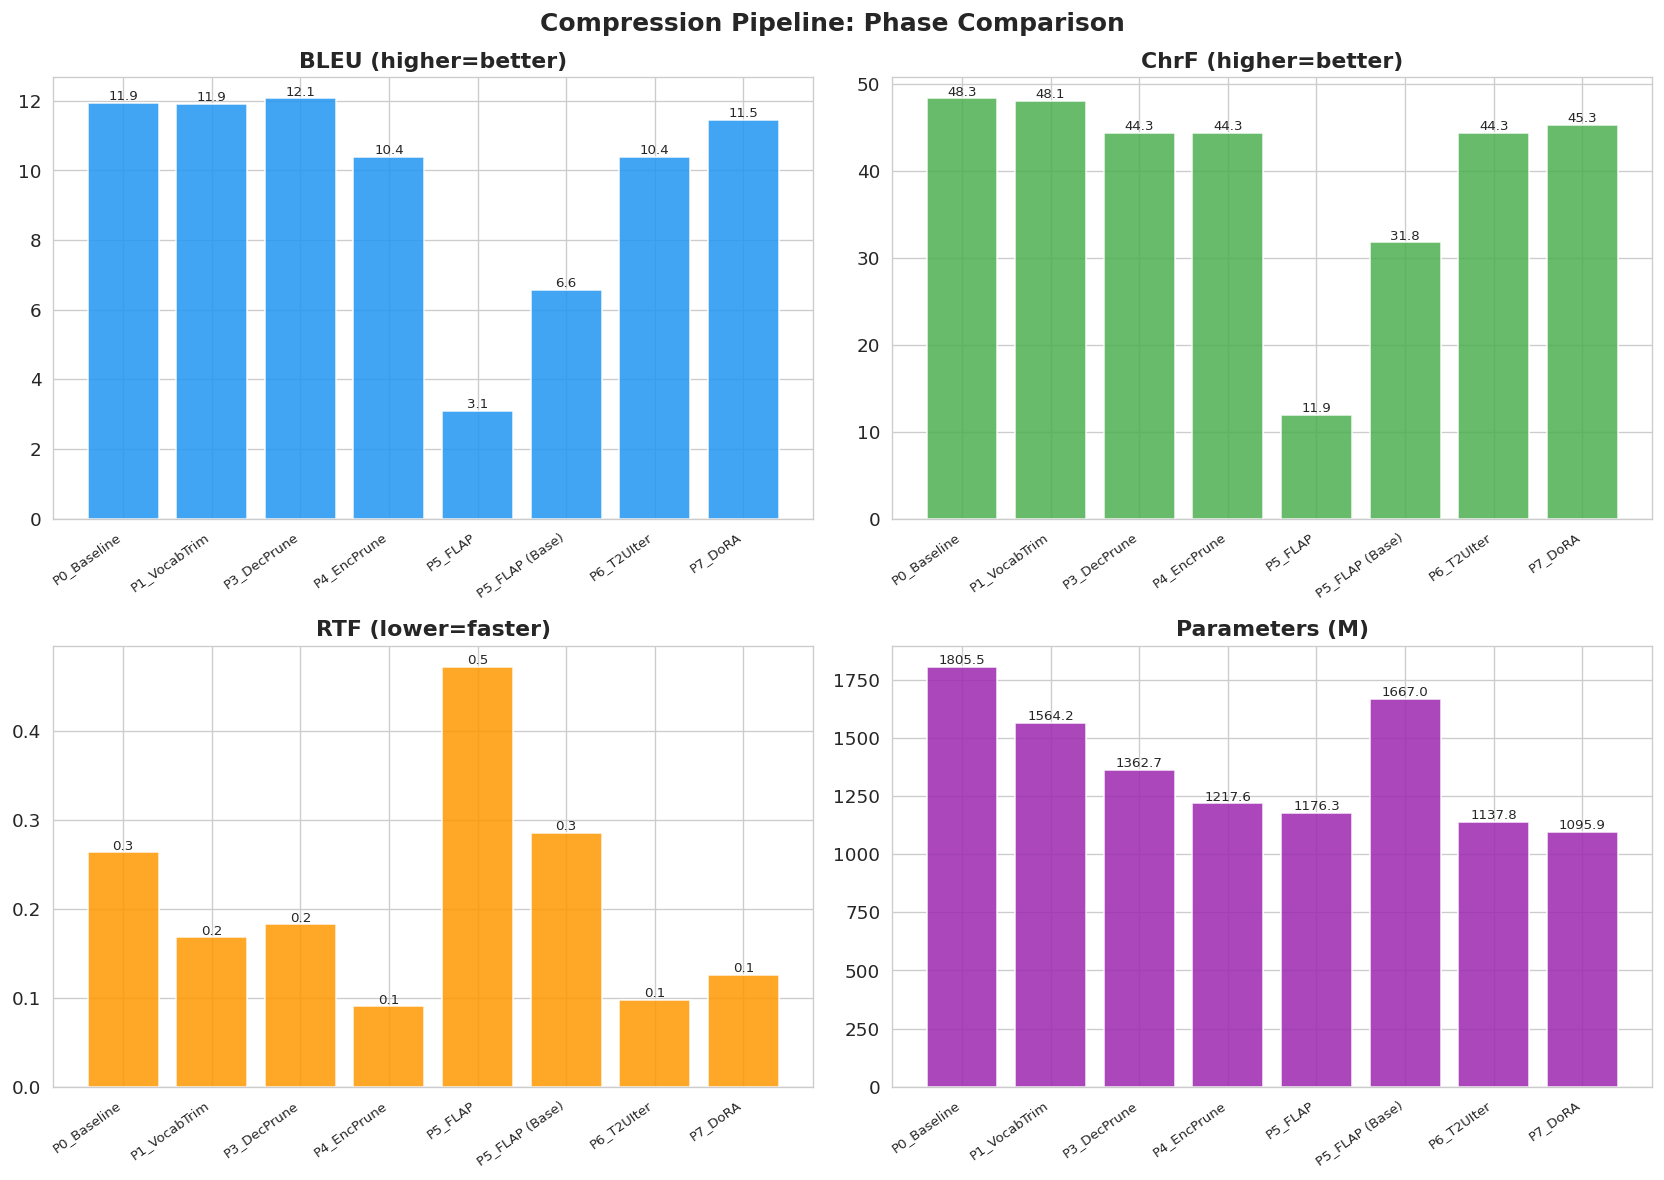

In [27]:
baseline_ckpt = load_latest_checkpoint('phase0_baseline')
if baseline_ckpt:
    baseline_results = baseline_ckpt['results']
    baseline_summary = baseline_ckpt['summary']
    print(f'Loaded baseline: BLEU={baseline_summary["avg_bleu"]:.2f}')
else:
    baseline_results, baseline_summary = run_benchmark(
        model, eval_samples, label='P0_Baseline', save_n=2)
    save_checkpoint(dict(results=baseline_results, summary=baseline_summary,
                         breakdown=baseline_breakdown), name='phase0_baseline', step=0)

store_summary(baseline_summary)
plot_phase_comparison()

---
# Phase 1: Vocabulary / Embedding Pruning
**Paper:** Asahi et al. (EMNLP 2023)

NLLB vocabulary has **256,102 tokens** for ~100 languages.
We keep only ~5-7 languages. Trimming saves ~200M params with near-zero quality impact.

In [ ]:
def identify_used_tokens(proc, target_lang_codes, n_corpus=2000):
    from datasets import load_dataset
    fleurs_codes = dict(eng='en_us', ben='bn_in', cmn='cmn_hans_cn',
                        fra='fr_fr', deu='de_de', hin='hi_in', urd='ur_pk')
    BASE = "hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet"
    used = set()
    tok = proc.tokenizer
    if hasattr(tok, 'all_special_ids'): used.update(tok.all_special_ids)
    for tid in range(len(tok)):
        t = tok.convert_ids_to_tokens(tid)
        if t and t.startswith('__') and t.endswith('__'): used.add(tid)
    for lang, fc in fleurs_codes.items():
        if lang not in target_lang_codes: continue
        print(f'  Scanning {lang} ({fc})...')
        try:
            ds = load_dataset("parquet",
                              data_files={"train": f"{BASE}/{fc}/train/*.parquet"},
                              split="train")
            for i, ex in enumerate(ds):
                if i >= n_corpus: break
                text = ex.get('transcription', '')
                if text: used.update(tok.encode(text, add_special_tokens=False))
        except Exception as e:
            print(f'    Warning: {lang}: {e}')
    print(f'  Unique tokens: {len(used)} / {len(tok)}')
    return sorted(used)


def trim_vocabulary(mdl, proc, keep_ids):
    """
    Trim the NLLB text vocabulary to only the kept token IDs.

    Correctly handles:
    - SeamlessM4Tv2ScaledWordEmbedding (preserves embed_scale for decoder)
    - generation_config.id_to_text mapping (required by T2U _indices_to_subwords)
    - Tied weights: shared <-> text_decoder.embed_tokens <-> lm_head
    - Correct padding_idx remapping from old to new ID space

    Based on Asahi et al. (EMNLP 2023) vocabulary trimming methodology.
    """
    keep_t = torch.tensor(keep_ids, dtype=torch.long)
    old_v = mdl.config.vocab_size
    new_v = len(keep_ids)
    hidden = mdl.config.hidden_size
    print(f'  Vocabulary: {old_v} -> {new_v} ({new_v/old_v*100:.1f}%)')

    old_shared = mdl.shared
    if old_shared.num_embeddings != old_v:
        print(f'  ERROR: shared.num_embeddings={old_shared.num_embeddings}, '
              f'expected {old_v}. Reload base model first.')
        return mdl

    dev = old_shared.weight.device
    dtype = old_shared.weight.dtype
    keep_t_dev = keep_t.to(dev)

    old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}

    old_pad = old_shared.padding_idx
    new_pad = old_to_new.get(old_pad) if old_pad is not None else None
    if old_pad is not None and new_pad is None:
        print(f'  WARNING: pad token {old_pad} not in keep_ids!')

    embed_scale = getattr(mdl.text_decoder.embed_tokens, 'embed_scale', 1.0)
    print(f'  text_decoder.embed_tokens.embed_scale = {embed_scale}')

    # --- 1. Create trimmed shared embedding ---
    new_shared = nn.Embedding(new_v, hidden, padding_idx=new_pad)
    new_shared.weight.data = old_shared.weight.data[keep_t_dev].clone()
    mdl.shared = new_shared.to(device=dev, dtype=dtype)
    print(f'  shared: [{old_v}, {hidden}] -> [{new_v}, {hidden}]')

    # --- 2. Update text_decoder.embed_tokens IN-PLACE ---
    # Keeps the SeamlessM4Tv2ScaledWordEmbedding class and its embed_scale.
    # The original forward() multiplies by embed_scale ~32.0;
    # replacing with plain nn.Embedding would lose this scaling entirely.
    dec_emb = mdl.text_decoder.embed_tokens
    dec_emb.weight = mdl.shared.weight
    dec_emb.num_embeddings = new_v
    dec_emb.padding_idx = new_pad
    print(f'  text_decoder.embed_tokens: tied to shared, embed_scale={dec_emb.embed_scale}')

    # --- 3. Handle text_encoder.embed_tokens if present ---
    if hasattr(mdl, 'text_encoder') and mdl.text_encoder is not None:
        enc_emb = getattr(mdl.text_encoder, 'embed_tokens', None)
        if enc_emb is not None:
            enc_emb.weight = mdl.shared.weight
            enc_emb.num_embeddings = new_v
            enc_emb.padding_idx = new_pad
            print(f'  text_encoder.embed_tokens: tied to shared')

    # --- 4. Tie lm_head to shared (preserves original tied-weight architecture) ---
    mdl.lm_head.weight = mdl.shared.weight
    mdl.lm_head.out_features = new_v
    if mdl.lm_head.bias is not None:
        mdl.lm_head.bias = nn.Parameter(mdl.lm_head.bias.data[keep_t_dev].clone())
    print(f'  lm_head: tied to shared [{new_v}, {hidden}]')

    # --- 5. Update model config ---
    mdl.config.vocab_size = new_v
    for attr in ['pad_token_id', 'bos_token_id', 'eos_token_id', 'decoder_start_token_id']:
        old_id = getattr(mdl.config, attr, None)
        if old_id is not None and old_id in old_to_new:
            setattr(mdl.config, attr, old_to_new[old_id])

    if hasattr(mdl.text_decoder, 'vocab_size'):
        mdl.text_decoder.vocab_size = new_v
    if hasattr(mdl.text_decoder, 'padding_idx'):
        mdl.text_decoder.padding_idx = new_pad
    print(f'  config: vocab_size={new_v}')

    # --- 6. Update generation_config ---
    # Use `gen_cfg` (not `gc`) so we never shadow Python's garbage-collector module.
    gen_cfg = mdl.generation_config

    # 6a. text_decoder_lang_to_code_id (lang -> text-vocab token ID for decoder_input)
    if hasattr(gen_cfg, 'text_decoder_lang_to_code_id') and gen_cfg.text_decoder_lang_to_code_id:
        gen_cfg.text_decoder_lang_to_code_id = {
            lang: old_to_new[oid]
            for lang, oid in gen_cfg.text_decoder_lang_to_code_id.items()
            if oid in old_to_new
        }
        print(f'  text_decoder_lang_to_code_id: {len(gen_cfg.text_decoder_lang_to_code_id)} langs')

    # 6b. id_to_text (CRITICAL for T2U character-level input)
    #     generate() calls _indices_to_subwords(t2u_input_ids) which does:
    #       id_to_text.get(str(token_id)) for each generated text token
    #     Without remapping, every lookup returns None -> T2U gets garbage chars
    if hasattr(gen_cfg, 'id_to_text') and gen_cfg.id_to_text:
        old_map = gen_cfg.id_to_text
        new_map = {}
        for key_str, text_val in old_map.items():
            old_id = int(key_str)
            if old_id in old_to_new:
                new_map[str(old_to_new[old_id])] = text_val
        gen_cfg.id_to_text = new_map
        print(f'  id_to_text: {len(old_map)} -> {len(new_map)} entries')
    else:
        print(f'  WARNING: no id_to_text in generation_config (T2U may fail for S2ST)')

    # 6c. Special token IDs in generation_config
    for attr in ['pad_token_id', 'bos_token_id', 'eos_token_id',
                 'decoder_start_token_id', 'forced_bos_token_id']:
        old_id = getattr(gen_cfg, attr, None)
        if old_id is not None and old_id in old_to_new:
            setattr(gen_cfg, attr, old_to_new[old_id])
    print(f'  generation_config special tokens remapped')

    # --- 7. Store remap for decode-time NEW->OLD conversion ---
    # _remap_ids_for_decode() maps model output (new IDs) back to original tokenizer
    # IDs for batch_decode. The tokenizer itself stays in original ID space.
    mdl._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)

    saved_params = (old_v - new_v) * hidden / 1e6
    print(f'  Done: ~{saved_params:.0f}M shared-embedding params removed '
          f'(lm_head tied, not double-counted)')
    return mdl


print('Vocab trimming functions ready.')


In [ ]:
try:
    model_p1, processor = load_model_from_drive('phase1_vocab_trimmed')
    p1_ckpt = load_latest_checkpoint('phase1_vocab')
    if p1_ckpt and 'keep_ids' in p1_ckpt:
        keep_ids = p1_ckpt['keep_ids']
        model_p1._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
        print(f'  Restored vocab remap ({len(keep_ids)} tokens)')

        # Validate id_to_text was correctly remapped (guards against stale saves
        # from the old broken trim_vocabulary that didn't remap id_to_text)
        gen_cfg = model_p1.generation_config
        if hasattr(gen_cfg, 'id_to_text') and gen_cfg.id_to_text:
            max_key = max(int(k) for k in gen_cfg.id_to_text.keys())
            if max_key >= model_p1.config.vocab_size:
                print(f'  WARNING: id_to_text has stale keys (max={max_key} >= vocab_size={model_p1.config.vocab_size})')
                print(f'  Re-remapping id_to_text from checkpoint keep_ids...')
                old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}
                old_map = gen_cfg.id_to_text
                new_map = {}
                for key_str, text_val in old_map.items():
                    old_id = int(key_str)
                    if old_id in old_to_new:
                        new_map[str(old_to_new[old_id])] = text_val
                gen_cfg.id_to_text = new_map
                print(f'  Fixed id_to_text: {len(old_map)} -> {len(new_map)} entries')
    print('Loaded Phase 1 model from Drive.')
except Exception as e:
    print(f'Load failed ({e}), running vocab trimming...')
    if model.config.vocab_size != 256102:
        print(f'  Model vocab is {model.config.vocab_size}, expected 256102. Reloading base model...')
        model, processor = load_base_model()
    TARGET_LANGS = ['eng', 'ben', 'cmn', 'fra', 'hin']
    keep_ids = identify_used_tokens(processor, TARGET_LANGS)
    pre = count_params(model)
    model = trim_vocabulary(model, processor, keep_ids)
    post = count_params(model)
    print(f'  Params: {pre:.1f}M to {post:.1f}M (saved {pre-post:.1f}M)')
    save_checkpoint(dict(keep_ids=keep_ids, pre=pre, post=post), name='phase1_vocab', step=0)
    save_model_to_drive(model, processor, 'phase1_vocab_trimmed')
    model_p1 = model

print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed')


In [ ]:
# for f in glob.glob(f'{CKPT_DIR}/phase1_benchmark_step*.pt'):
#     os.remove(f); print(f'Deleted stale: {f}')

p1_ckpt = load_latest_checkpoint('phase1_benchmark')
if p1_ckpt and p1_ckpt['summary'].get('avg_bleu', 0) > 0:
    p1_results, p1_summary = p1_ckpt['results'], p1_ckpt['summary']
else:
    p1_results, p1_summary = run_benchmark(model_p1, eval_samples, label='P1_VocabTrim', save_n=2)
    save_checkpoint(dict(results=p1_results, summary=p1_summary), name='phase1_benchmark', step=0)
store_summary(p1_summary)
plot_phase_comparison()

In [ ]:
# run_benchmark(model_p1, eval_samples, label='P1_VocabTrim', save_n=2)
# import shutil
# stale = f'{MODEL_DIR}/phase1_vocab_trimmed'
# if os.path.exists(stale):
#     shutil.rmtree(stale)
#     print(f'Deleted stale: {stale}')
# # Also clear from Drive:
# subprocess.run(f'rclone delete {GDRIVE_ROOT}/phase1_vocab_trimmed/', shell=True)

---
# Phase 2: Text Encoder Removal
# Actually it was never in the first place, we never loaded the textEncoder as we are using
# from transformers import SeamlessM4Tv2ForSpeechToSpeech
For S2S, the pipeline is: Speech Encoder -> Text Decoder -> T2U -> Vocoder.
The text_encoder is only used for T2T/T2S tasks. We verify and remove it.

In [ ]:
# def check_text_encoder_used(mdl):
#     if not hasattr(mdl, 'text_encoder') or mdl.text_encoder is None:
#         print('  text_encoder not present.'); return False
#     called = [False]
#     def hook(mod, inp, out): called[0] = True
#     h = mdl.text_encoder.register_forward_hook(hook)
#     try: _ = run_s2st(mdl, np.random.randn(48000).astype(np.float32), 'ben')
#     except: pass
#     h.remove()
#     return called[0]

# def remove_text_encoder(mdl):
#     if hasattr(mdl, 'text_encoder') and mdl.text_encoder is not None:
#         enc_p = count_params(mdl.text_encoder)
#         del mdl.text_encoder; mdl.text_encoder = None
#         _stdlib_gc.collect(); torch.cuda.empty_cache()
#         print(f'  Removed text_encoder ({enc_p:.1f}M params)')
#     return mdl

# print('Text encoder analysis ready.')

In [ ]:
# try:
#     model_p2, processor = load_model_from_drive('phase2_no_text_enc')
#     print('Loaded Phase 2 from Drive.')
# except:
#     model_p2 = model_p1
#     used = check_text_encoder_used(model_p2)
#     print(f'  text_encoder used in S2S: {used}')
#     if not used:
#         print('  Safe to remove for S2S-only.')
#         model_p2 = remove_text_encoder(model_p2)
#     else:
#         print('  text_encoder IS used. Keeping 8 of 24 layers.')
#         layers = model_p2.text_encoder.layers
#         keep = list(range(4)) + list(range(len(layers)-4, len(layers)))
#         model_p2.text_encoder.layers = nn.ModuleList([layers[i] for i in keep])
#     save_model_to_drive(model_p2, processor, 'phase2_no_text_enc')

# print_model_breakdown(model_p2, 'After Phase 2: Text Encoder Removed')

In [ ]:
# p2_ckpt = load_latest_checkpoint('phase2_benchmark')
# if p2_ckpt:
#     p2_results, p2_summary = p2_ckpt['results'], p2_ckpt['summary']
# else:
#     p2_results, p2_summary = run_benchmark(model_p2, eval_samples, label='P2_NoTextEnc', save_n=2)
#     save_checkpoint(dict(results=p2_results, summary=p2_summary), name='phase2_benchmark', step=0)
# store_summary(p2_summary)
# plot_phase_comparison()

---
# Phase 3: Text Decoder Iterative Layer Pruning
**Paper:** Moslem (IWSLT 2025), CULL-MT (2024)

Iterative greedy pruning: remove one layer at a time, evaluate ChrF, repeat.
Target: remove 6-8 of 24 text decoder layers.

In [ ]:
# def find_layers_attr(component):
#     for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
#         if hasattr(component, attr): return attr
#     return None

def _get_protected_indices(n_total):
    """
    Custom protection rule:
      - First layer  (index 0)
      - Last layer   (index n_total - 1)
      - Middle layer (index n_total // 2)
    Returns a set of original indices that must never be pruned.
    """
    first  = 0
    last   = n_total - 1
    middle = n_total // 2
    protected = {first, last, middle}
    print(f'  Protected layers (first/mid/last): {sorted(protected)}')
    return protected

def iterative_layer_prune(mdl, component_name, samples, n_remove,
                          tgt_lang='ben', max_eval=10,
                          ckpt_name='phase3_dec_pruning'):
    """
    Iterative greedy layer pruning (Moslem, IWSLT 2025).
    Custom rule: never prune the first, last, or middle layer.
    Removes one layer per iteration, picking the candidate whose removal
    causes the LEAST ChrF degradation (highest remaining ChrF).
    Saves checkpoint after every iteration.
    """
    parent = getattr(mdl, component_name)
    layers_attr = find_layers_attr(parent)
    if layers_attr is None:
        print(f'  No layers found on {component_name}'); return [], []
    current = list(getattr(parent, layers_attr))
    orig_indices = list(range(len(current)))
    n_total_orig = len(current)
    removed, log = [], []

    # ── Protected indices (never prunable) ──
    protected = _get_protected_indices(n_total_orig)

    # ── Resume from checkpoint ──
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = partial['removed']
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos)
                orig_indices.pop(pos)
        setattr(parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    start_iter = len(removed)
    for it in range(start_iter, n_remove):
        # Eligible candidates: not in protected set, not already removed
        eligible = [idx for idx in range(len(current))
                    if orig_indices[idx] not in protected]
        if not eligible:
            print(f'  WARNING: No eligible (non-protected) layers left to prune! Stopping.')
            break

        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
              f'{len(eligible)} eligible candidates)')
        scores = {}
        for idx in eligible:
            temp = current[:idx] + current[idx+1:]
            setattr(parent, layers_attr, nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[idx] = (orig_indices[idx], sc)
            orig_label = orig_indices[idx]
            prot_note = ' [PROTECTED-skip]' if orig_label in protected else ''
            print(f'    Remove L{orig_label:>2} -> ChrF={sc:.2f}{prot_note}')
        setattr(parent, layers_attr, nn.ModuleList(current))

        # Pick the eligible candidate causing the least harm
        best_idx = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_idx]
        current.pop(best_idx)
        orig_indices.pop(best_idx)
        setattr(parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current)))
        print(f'  -> Removed layer {best_orig} (ChrF={best_sc:.2f})')
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')

    return removed, log

print('iterative_layer_prune() with first/mid/last protection ready.')

In [ ]:
# ── Phase 3: Text Decoder Iterative Layer Pruning ────────────────────────────
# Text decoder has 24 layers. Protected: L0, L12, L23.
# We remove 8 of the remaining 21 eligible layers.
N_DEC_REMOVE = 8   # ← increased from 6

p3_ckpt = load_latest_checkpoint('phase3_dec_pruning')
p3_complete = p3_ckpt and len(p3_ckpt.get('removed', [])) >= N_DEC_REMOVE

if p3_complete:
    removed_dec = p3_ckpt['removed']; p3_log = p3_ckpt['log']
    print(f'Phase 3 complete: removed {removed_dec}')
    try:
        model_p3, processor = load_model_from_drive('phase3_dec_pruned')
    except:
        print('  Drive model missing, rebuilding from checkpoint + model_p1...')
        model_p3 = model_p1
        parent = model_p3.text_decoder
        la = find_layers_attr(parent)
        cur = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_dec]
        setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
        # Critical: Sync config before saving or using
        sync_model_config(model_p3)
        save_model_to_drive(model_p3, processor, 'phase3_dec_pruned')
else:
    done_so_far = len(p3_ckpt['removed']) if p3_ckpt else 0
    print(f'{"Resuming" if done_so_far else "Running"} Phase 3: '
          f'decoder pruning ({done_so_far}/{N_DEC_REMOVE} done)...')
    model_p3 = _consolidate_to_single_gpu(model_p1)
    removed_dec, p3_log = iterative_layer_prune(
        model_p3, 'text_decoder', eval_samples, N_DEC_REMOVE, TARGET_LANG,
        ckpt_name='phase3_dec_pruning')
    # Sync config after pruning is finished
    sync_model_config(model_p3)
    save_model_to_drive(model_p3, processor, 'phase3_dec_pruned')

print(f'Decoder layers removed: {removed_dec}')
print_model_breakdown(model_p3, 'After Phase 3: Decoder Pruned')

In [ ]:
model_p3, processor = None, None

In [ ]:
model_p3, processor = load_model_from_drive('phase3_dec_pruned')

In [ ]:
if p3_log:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    iters = [e['iter'] for e in p3_log]
    chrfs = [e['chrf'] for e in p3_log]
    ax1.plot(iters, chrfs, 'o-', color='#4CAF50', lw=2, ms=8)
    for e in p3_log: ax1.annotate(f'L{e["removed"]}', (e['iter'], e['chrf']), fontsize=8, ha='center', va='bottom')
    ax1.set_xlabel('Iteration'); ax1.set_ylabel('ChrF'); ax1.set_title('Decoder: ChrF After Each Removal', fontweight='bold')
    ax2.bar(iters, [e['remaining'] for e in p3_log], color='#9C27B0', alpha=0.8)
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Layers'); ax2.set_title('Decoder Layers Remaining', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{FIG_DIR}/phase3_dec.png'); plt.show()

In [ ]:
[layer.self_attn.layer_idx for layer in model_p3.text_decoder.layers]


In [26]:
def reindex_text_decoder_layer_idx(mdl):
    dec = mdl.text_decoder
    for i, layer in enumerate(dec.layers):
        layer.self_attn.layer_idx = i
        layer.cross_attention.layer_idx = i

In [ ]:
reindex_text_decoder_layer_idx(model_p3)
sync_model_config(model_p3)
if hasattr(model_p3, "_cache"):
    delattr(model_p3, "_cache")  # avoid reusing a cache sized for an older depth

In [ ]:
[layer.self_attn.layer_idx for layer in model_p3.text_decoder.layers]


In [ ]:
p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecPrune', save_n=2)
save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary); plot_phase_comparison()

In [ ]:
p3b = load_latest_checkpoint('phase3_benchmark')
if p3b: p3_results, p3_summary = p3b['results'], p3b['summary']
else:
    p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecPrune', save_n=2)
    save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary); plot_phase_comparison()

---
# Phase 4: Speech Encoder Iterative Layer Pruning
**Paper:** ShortGPT (ACL 2025) for Block Influence; Moslem (IWSLT 2025) for iterative greedy

Target: remove 6-8 of 24 speech encoder layers.

In [27]:
def get_speech_encoder_layers(mdl):
    enc = mdl.speech_encoder
    if hasattr(enc, 'layers') and isinstance(enc.layers, torch.nn.ModuleList) and len(enc.layers) > 0:
        return enc, 'layers'
    if hasattr(enc, 'encoder') and hasattr(enc.encoder, 'layers') and len(enc.encoder.layers) > 0:
        return enc.encoder, 'layers'
    for child_name, child in enc.named_children():
        if hasattr(child, 'layers') and isinstance(child.layers, torch.nn.ModuleList) and len(child.layers) > 0:
            print(f'  Found layers at speech_encoder.{child_name}.layers')
            return child, 'layers'
    raise RuntimeError(
        f"Cannot find layers. speech_encoder children: "
        f"{[n for n,_ in enc.named_children()]}\n"
        f"encoder children: "
        f"{[n for n,_ in enc.encoder.named_children()] if hasattr(enc, 'encoder') else 'N/A'}"
    )


def compute_block_influence(mdl, samples, max_n=50):
    """
    Block Influence (ShortGPT, ACL 2025): BI(l) = 1 - cos(input_l, output_l).

    Measures how much each layer transforms its input — low BI means the
    layer barely changes the hidden states and is a prime pruning candidate.
    Used here to PRE-RANK layers before iterative ChrF search, so we only
    evaluate cheap candidates rather than all layers every iteration.
    """
    parent, la = get_speech_encoder_layers(mdl)
    layers = getattr(parent, la)
    n = len(layers)
    bi = {i: [] for i in range(n)}
    hooks = []

    for i in range(n):
        def make_hook(idx):
            def hook(mod, inp, out):
                x = inp[0]
                if x is None or not isinstance(x, torch.Tensor): return
                y = out[0] if isinstance(out, tuple) else out
                if y is None or not isinstance(y, torch.Tensor): return
                x = x.detach().float().reshape(-1, x.shape[-1])
                y = y.detach().to(x.device).float().reshape(-1, y.shape[-1])
                cos = F.cosine_similarity(x, y, dim=-1).mean().item()
                bi[idx].append(1.0 - cos)
            return hook
        hooks.append(layers[i].register_forward_hook(make_hook(i)))

    mdl.eval()
    dev = next(mdl.speech_encoder.parameters()).device
    ok = 0
    for idx, s in enumerate(samples[:max_n]):
        if idx % 10 == 0:
            print(f'  Calibrating {idx}/{min(max_n, len(samples))}...')
        try:
            inputs = processor(audio=s['wav'], sampling_rate=16000, return_tensors='pt')
            feats = {k: v.to(dev) for k, v in inputs.items()}
            with torch.no_grad():
                mdl.speech_encoder(**feats)
            ok += 1
        except Exception as e:
            print(f'  Sample {idx} failed: {e}')

    for h in hooks: h.remove()

    scores = {i: float(np.mean(v)) if v else 0.0 for i, v in bi.items()}
    print(f'  Calibrated on {ok}/{min(max_n, len(samples))} samples.')
    nonzero = sum(1 for v in scores.values() if v > 1e-6)
    print(f'  Non-zero BI scores: {nonzero}/{n}')
    if nonzero == 0:
        raise RuntimeError("All BI scores are zero — hooks did not fire.")

    # Print ranking so user can see what BI identified
    ranked = sorted(scores.items(), key=lambda x: x[1])
    print(f'\n  BI ranking (lowest = most redundant → pruning candidates):')
    for rank, (layer_i, bi_val) in enumerate(ranked):
        print(f'    Rank {rank+1:>2}  L{layer_i:>2}  BI={bi_val:.4f}')

    return scores


def iterative_enc_prune(mdl, samples, n_remove, tgt_lang='ben', max_eval=10,
                        ckpt_name='phase4_enc_pruning',
                        bi_scores=None,
                        bi_candidate_ratio=0.5,
                        protected=None):
    """
    BI-guided iterative greedy encoder pruning.

    Paper alignment:
    - ShortGPT (ACL 2025): BI scores rank layers by redundancy. We use them
      to restrict the candidate pool each iteration to the bottom bi_candidate_ratio
      fraction by BI score. This is the key improvement — instead of evaluating
      all N layers every iteration (O(N²) ChrF calls), we only evaluate the
      bottom-K BI candidates (O(N·K) calls), cutting runtime by ~50%.
    - Moslem IWSLT 2025: iterative greedy selection by ChrF, one layer at a time.
    - Custom rule: protected layers (first, middle, last) are never candidates.

    Args:
        bi_scores: dict {orig_layer_idx: bi_score}. If provided, only the
                   bottom bi_candidate_ratio fraction are evaluated each iter.
                   If None, falls back to evaluating all candidates (old behavior).
        bi_candidate_ratio: fraction of remaining layers to consider as candidates
                            based on BI ranking (default 0.5 = bottom 50%).
        protected: set of original layer indices to never prune.
    """
    parent, la = get_speech_encoder_layers(mdl)
    current  = list(getattr(parent, la))
    orig_idx = list(range(len(current)))
    n_total  = len(current)
    removed, log = [], []

    # ── Protected indices (never prunable) ──
    if protected is None:
        protected = {0, n_total // 2, n_total - 1}
    print(f'  Protected layers (first/mid/last): {sorted(protected)}')

    # ── Resume from checkpoint ──
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos)
                orig_idx.pop(pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    start_iter = len(removed)
    baseline = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
    print(f'  Baseline ChrF (before any removal): {baseline:.2f}')

    for it in range(start_iter, n_remove):
        # ── Determine eligible candidates ──
        # 1. Exclude protected original indices
        eligible_positions = [
            pos for pos in range(len(current))
            if orig_idx[pos] not in protected
        ]

        # 2. BI-guided pre-filtering (ShortGPT ACL 2025):
        #    Among eligible positions, only evaluate the bottom bi_candidate_ratio
        #    by BI score — these are the most redundant layers per BI theory.
        if bi_scores and len(eligible_positions) > 2:
            # Sort eligible positions by ascending BI score (lowest BI = most redundant)
            eligible_by_bi = sorted(
                eligible_positions,
                key=lambda pos: bi_scores.get(orig_idx[pos], float('inf'))
            )
            # Keep only the bottom fraction as candidates
            n_candidates = max(2, int(len(eligible_by_bi) * bi_candidate_ratio))
            candidate_positions = eligible_by_bi[:n_candidates]
            print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain)')
            print(f'  BI pre-filter: {len(candidate_positions)}/{len(eligible_positions)} '
                  f'eligible layers selected as candidates (bottom {bi_candidate_ratio*100:.0f}% by BI)')
            skipped = [orig_idx[p] for p in eligible_by_bi[n_candidates:]]
            if skipped:
                print(f'  Skipped (high BI / important): {skipped}')
        else:
            # Fallback: evaluate all eligible (original behavior, no BI available)
            candidate_positions = eligible_positions
            print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
                  f'no BI pre-filter — evaluating all {len(candidate_positions)} eligible)')

        if not candidate_positions:
            print(f'  WARNING: No eligible candidates left. Stopping early.')
            break

        # ── Evaluate each candidate via ChrF ──
        scores = {}
        for pos in candidate_positions:
            temp = current[:pos] + current[pos+1:]
            setattr(parent, la, torch.nn.ModuleList(temp))
            sc = quick_eval_chrf(mdl, samples, tgt_lang, max_eval)
            scores[pos] = (orig_idx[pos], sc)
            bi_note = f'  BI={bi_scores.get(orig_idx[pos], 0):.4f}' if bi_scores else ''
            print(f'    Remove L{orig_idx[pos]:>2} -> ChrF={sc:.2f}{bi_note}')
        setattr(parent, la, torch.nn.ModuleList(current))

        # ── Pick best removal (highest remaining ChrF) ──
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos)
        orig_idx.pop(best_pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, chrf=best_sc,
                        remaining=len(current),
                        bi_score=bi_scores.get(best_orig, None) if bi_scores else None))
        print(f'  -> Removed original layer {best_orig}  '
              f'(ChrF={best_sc:.2f}'
              + (f', BI={bi_scores.get(best_orig, 0):.4f}' if bi_scores else '') + ')')

        # Update BI scores: remove pruned layer from tracking
        # (so next iteration's ranking reflects current architecture)
        if bi_scores and best_orig in bi_scores:
            del bi_scores[best_orig]

        save_checkpoint(
            dict(removed=removed, log=log,
                 bi_scores=bi_scores if bi_scores else {}),
            name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')
        torch.cuda.empty_cache()

    return removed, log


print('Phase 4 helpers ready (BI-guided iterative pruning).')
parent, la = get_speech_encoder_layers(model_p3)
print(f'Speech encoder layers found: {len(getattr(parent, la))} '
      f'at .speech_encoder.{type(parent).__name__}.{la}')

Phase 4 helpers ready (BI-guided iterative pruning).


NameError: name 'model_p3' is not defined

In [ ]:
# ── Uncomment and run ONCE to wipe corrupt Phase 4 results, then re-comment ──

# # 1. Local checkpoints
# for f in glob.glob(f'{CKPT_DIR}/phase4_enc_pruning_step*.pt'):
#     os.remove(f)
#     print(f'Deleted local ckpt: {f}')

# # 2. Local saved model
# local_model = f'{MODEL_DIR}/phase4_enc_pruned'
# if os.path.exists(local_model):
#     shutil.rmtree(local_model)
#     print(f'Deleted local model: {local_model}')

# # 3. Remote cleanup — platform-aware
# if ON_KAGGLE:
#     subprocess.run(f'rclone delete "{GDRIVE_ROOT}/checkpoints/phase4_enc_pruning_step000000.pt"',
#                    shell=True)
#     subprocess.run(f'rclone purge "{GDRIVE_ROOT}/phase4_enc_pruned"',
#                    shell=True)
#     r = subprocess.run(f'rclone ls "{GDRIVE_ROOT}/checkpoints/"',
#                        shell=True, capture_output=True, text=True)
#     print('Remaining on remote:', r.stdout or '(none)')
# else:
#     # Colab: just deleting local IS deleting Drive (they're the same)
#     print('Colab: local deletion above already removed files from Drive.')

# ck = load_latest_checkpoint('phase4_enc_pruning')
# print('Phase 4 checkpoint after cleanup:', ck)

In [ ]:
# # Run once to fix model_p3 in memory before phase 3 benchmark
# sync_model_config(model_p3)

# # Run once to fix model_p4 in memory before phase 4 benchmark
# sync_model_config(model_p4)

In [ ]:
!rm -rf '/kaggle/working/models/phase4_enc_pruned'
!rm -rf '/kaggle/working/checkpoints/phase6*.pt'

In [84]:
# ── Phase 4: Speech Encoder Iterative Layer Pruning ──────────────────────────
# Paper: ShortGPT (ACL 2025) — BI pre-ranks layers by redundancy.
#        Moslem IWSLT 2025 — iterative greedy ChrF-guided removal.
# Integration: BI restricts the candidate pool each iteration to the
#              bottom 50% by BI score, halving ChrF evaluation cost.
# Custom rule: protect first (L0), middle (L12), last (L23) layers.

N_ENC_REMOVE = 6
ENC_BI_CANDIDATE_RATIO = 0.5   # evaluate only the bottom 50% by BI each iter

p4_ckpt = load_latest_checkpoint('phase4_enc_pruning')
p4_complete = p4_ckpt and len(p4_ckpt.get('removed', [])) >= N_ENC_REMOVE

if p4_complete:
    removed_enc = p4_ckpt['removed']
    bi_scores   = p4_ckpt.get('bi_scores', {})
    p4_log      = p4_ckpt['log']
    print(f'Phase 4 complete: removed {removed_enc}')
    try:
        model_p4, processor = load_model_from_drive('phase4_enc_pruned')
    except:
        print('  Drive model missing, rebuilding from checkpoint + model_p3...')
        model_p4 = model_p3
        parent, la = get_speech_encoder_layers(model_p4)
        cur  = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_enc]
        setattr(parent, la, torch.nn.ModuleList([cur[i] for i in keep]))
        print(f'  Rebuilt from checkpoint: {len(keep)} layers remain')
        save_model_to_drive(model_p4, processor, 'phase4_enc_pruned')
else:
    done_so_far = len(p4_ckpt['removed']) if p4_ckpt else 0
    print(f'{"Resuming" if done_so_far else "Running"} Phase 4: '
          f'encoder pruning ({done_so_far}/{N_ENC_REMOVE} done)...')

    model_p4 = model_p3
    model_p4 = _consolidate_to_single_gpu(model_p4)

    sanity = quick_eval_chrf(model_p4, eval_samples, TARGET_LANG, 5)
    print(f'  Sanity check ChrF = {sanity:.2f}  (expect ~40-55, abort if < 10)')
    assert sanity > 10, f'ChrF={sanity:.2f} is too low — model or vocab remap is broken!'

    # ── Step 1: Compute BI scores (ShortGPT ACL 2025) ──────────────────────
    # BI = 1 - cosine_similarity(layer_input, layer_output)
    # Low BI → layer barely transforms hidden states → redundant candidate.
    # We use BI to PRE-FILTER candidates each iteration rather than just plotting.
    if not (p4_ckpt and p4_ckpt.get('bi_scores')):
        print('Step 1: Computing Block Influence scores (ShortGPT ACL 2025)...')
        bi_scores = compute_block_influence(model_p4, eval_samples, max_n=50)
        plot_layer_scores(bi_scores, 'Speech Encoder Block Influence', 'phase4_bi.png')
        # Save BI scores immediately so resume works
        save_checkpoint(
            dict(removed=[], log=[], bi_scores=bi_scores),
            name='phase4_enc_pruning', step=0)
    else:
        bi_scores = p4_ckpt['bi_scores']
        print(f'  BI scores loaded from checkpoint ({len(bi_scores)} layers), '
              f'skipping recomputation.')

    # Determine protected set: first, middle, last of the ORIGINAL encoder
    parent_tmp, la_tmp = get_speech_encoder_layers(model_p4)
    n_enc_layers = len(getattr(parent_tmp, la_tmp))
    enc_protected = {0, n_enc_layers // 2, n_enc_layers - 1}
    print(f'\n  Encoder protected layers: {sorted(enc_protected)} '
          f'(of {n_enc_layers} total)')

    # ── Step 2: BI-guided iterative pruning (Moslem IWSLT 2025 + ShortGPT) ──
    # Each iteration: evaluate only bottom-50% BI candidates (not all layers).
    # This directly uses BI as a meaningful pre-filter, not just a plot.
    print(f'\nStep 2: BI-guided iterative pruning ({N_ENC_REMOVE} layers, '
          f'candidate ratio={ENC_BI_CANDIDATE_RATIO})...')
    removed_enc, p4_log = iterative_enc_prune(
        model_p4, eval_samples, N_ENC_REMOVE, TARGET_LANG,
        max_eval=10,
        ckpt_name='phase4_enc_pruning',
        bi_scores=bi_scores,                        # ← NOW ACTUALLY USED
        bi_candidate_ratio=ENC_BI_CANDIDATE_RATIO,  # ← evaluate bottom 50% by BI
        protected=enc_protected,                    # ← first/mid/last protected
    )

    print('Syncing config after encoder pruning...')
    sync_model_config(model_p4)

    save_checkpoint(
        dict(removed=removed_enc, log=p4_log, bi_scores=bi_scores),
        name='phase4_enc_pruning', step=0)
    save_model_to_drive(model_p4, processor, 'phase4_enc_pruned')

print(f'\nEncoder layers removed: {removed_enc}')
print_model_breakdown(model_p4, 'After Phase 4: Encoder Pruned')

[ckpt] Loaded phase4_enc_pruning_step000000.pt
Phase 4 complete: removed [19, 15, 9, 3, 2, 10]
[model] Not in local cache, pulling from remote...
[rclone] Pulled phase4_enc_pruned → /kaggle/working/models/phase4_enc_pruned
[model] Loading phase4_enc_pruned from /kaggle/working/models/phase4_enc_pruned ...


Loading weights:   0%|          | 0/1446 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']

Encoder layers removed: [19, 15, 9, 3, 2, 10]

--- After Phase 4: Encoder Pruned ---
  speech_encoder                         490.0M  ( 40.2%)
  text_decoder                           423.9M  ( 34.8%)
  t2u_model                              261.8M  ( 21.5%)
  vocoder                                 41.9M  (  3.4%)
  shared                                  20.9M  (  1.7%)
  lm_head                                 20.9M  (  1.7%)
  TOTAL                                 1217.6M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1217.583365}

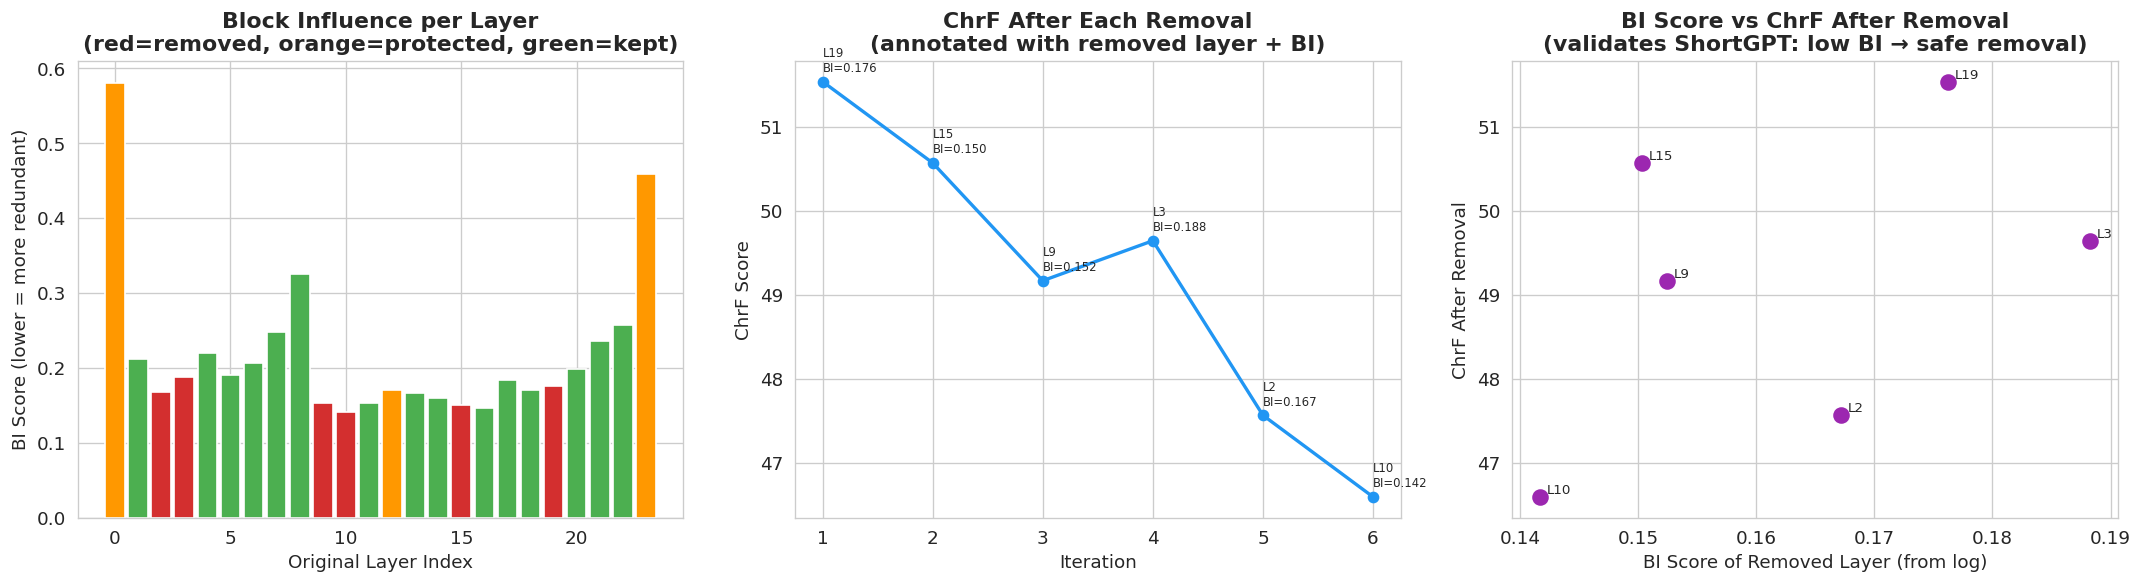

Saved phase4_enc_bi_analysis.png


In [29]:
if bi_scores and p4_log:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # BI at removal time (always use for removed layers + plot 3)
    bi_at_removal = {e['removed']: e.get('bi_score') for e in p4_log if 'removed' in e}

    def bi_value_for_index(i):
        if i in bi_scores:
            return bi_scores[i]
        b = bi_at_removal.get(i)
        return b if b is not None else 0.0

    # ── Plot 1: BI scores with removed/protected/kept labels ──
    ax1 = axes[0]
    parent_tmp, la_tmp = get_speech_encoder_layers(model_p4)
    n_enc = len(getattr(parent_tmp, la_tmp)) + len(removed_enc)
    enc_protected = {0, n_enc // 2, n_enc - 1}

    all_indices = sorted(
        set(bi_scores.keys()) | set(removed_enc) | set(bi_at_removal.keys())
    )
    vals = [bi_value_for_index(i) for i in all_indices]
    colors = []
    for i in all_indices:
        if i in removed_enc:
            colors.append('#d32f2f')
        elif i in enc_protected:
            colors.append('#ff9800')
        else:
            colors.append('#4caf50')

    ax1.bar(all_indices, vals, width=0.85, color=colors, edgecolor='white')
    ax1.set_title(
        'Block Influence per Layer\n(red=removed, orange=protected, green=kept)',
        fontweight='bold',
    )
    ax1.set_xlabel('Original Layer Index')
    ax1.set_ylabel('BI Score (lower = more redundant)')

    # ── Plot 2: ChrF after each removal ──
    ax2 = axes[1]
    iters = [e['iter'] for e in p4_log]
    chrfs = [e['chrf'] for e in p4_log]
    ax2.plot(iters, chrfs, 'o-', color='#2196F3', lw=2)
    for e in p4_log:
        bi_val = e.get('bi_score', None)
        label = f'L{e["removed"]}'
        if bi_val is not None:
            label += f'\nBI={bi_val:.3f}'
        ax2.annotate(
            label, (e['iter'], e['chrf']), fontsize=7,
            textcoords='offset points', xytext=(0, 6),
        )
    ax2.set_title(
        'ChrF After Each Removal\n(annotated with removed layer + BI)',
        fontweight='bold',
    )
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('ChrF Score')

    # ── Plot 3: BI of removed layer vs ChrF after that removal ──
    ax3 = axes[2]
    _filtered = [
        (e['bi_score'], e['chrf'])
        for e in p4_log
        if e.get('bi_score') is not None
    ]
    bi_vals_removed = [x for x, _ in _filtered]
    chrf_vals = [y for _, y in _filtered]

    if len(_filtered) >= 2:
        ax3.scatter(bi_vals_removed, chrf_vals, color='#9c27b0', s=80, zorder=3)
        for e in p4_log:
            if e.get('bi_score') is not None:
                ax3.annotate(
                    f'L{e["removed"]}',
                    (e['bi_score'], e['chrf']),
                    fontsize=8, textcoords='offset points', xytext=(4, 2),
                )
        ax3.set_xlabel('BI Score of Removed Layer (from log)')
        ax3.set_ylabel('ChrF After Removal')
        ax3.set_title(
            'BI Score vs ChrF After Removal\n(validates ShortGPT: low BI → safe removal)',
            fontweight='bold',
        )
    else:
        ax3.text(
            0.5, 0.5, 'Not enough data\nfor correlation plot',
            ha='center', va='center', transform=ax3.transAxes,
        )
        ax3.set_title('BI vs ChrF Correlation', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/phase4_enc_bi_analysis.png', dpi=120)
    plt.show()
    print('Saved phase4_enc_bi_analysis.png')

In [30]:
run_benchmark(model_p4, eval_samples, label='P4_EncPrune', save_n=2)


  BENCHMARK: P4_EncPrune
  Samples: 25  Target: ben

  GPU mem: 3.03 GB alloc / 3.05 GB reserved
  [ 1/25] BLEU= 16.0 ChrF= 49.6 RTF=0.349  id=1660
              pred: রোমান্টিকতার একটি বড় উপাদান ছিল সাংস্কৃতিক নির্ধারক যেমন গোথ, ফিচ এবং শ্লেগেলের
[audio] Saved P4_EncPrune_s1in.wav (0.3 MB)
  P4_EncPrune_s1in.wav  (10.7s | sr=16000)


[audio] Saved P4_EncPrune_s1out.wav (0.2 MB)
  P4_EncPrune_s1out.wav  (7.3s | sr=16000)


  [ 2/25] BLEU=  6.2 ChrF= 51.8 RTF=0.185  id=1662
              pred: অ্যালোয়গুলি মূলত দুটি বা একাধিক ধাতুর মিশ্রণ, ভুলবেন না যে পিআই-এতে অনেক উপাদান
[audio] Saved P4_EncPrune_s2in.wav (0.3 MB)
  P4_EncPrune_s2in.wav  (8.4s | sr=16000)


[audio] Saved P4_EncPrune_s2out.wav (0.2 MB)
  P4_EncPrune_s2out.wav  (6.2s | sr=16000)


  [ 3/25] BLEU= 13.0 ChrF= 44.5 RTF=0.230  id=1674
              pred: কিছু এলাকায় এক মিনিটের জন্য উড়ন্ত জল যথেষ্ট এবং অন্য কয়েক মিনিট প্রয়োজন হয়।
  [ 4/25] BLEU= 20.8 ChrF= 50.5 RTF=0.165  id=1675
              pred: শব্দটির পাশে সব নামকথা সবসময় বড় অক্ষর দিয়ে শুরু হয়, এমনকি বাক্যের মাঝামাঝিেও
  [ 5/25] BLEU=  6.9 ChrF= 53.0 RTF=0.222  id=1704
              pred: নবম শতাব্দীতে এটি মরুভূমির বালির হুমকির কারণে বিপন্ন বিশ্ব ঐতিহ্যবাহী স্থানের তা
  [ 6/25] BLEU= 17.3 ChrF= 58.1 RTF=0.175  id=1713
              pred: যদিও গোমা যথেষ্ট নিরাপদ, উত্তর কিউউউ প্রদেশে যুদ্ধের অবস্থা বোঝার জন্য গোমার বাই
  [ 7/25] BLEU=  5.5 ChrF= 33.5 RTF=0.206  id=1720
              pred: গরম চকোলেট বেলজিয়ামের মানের মতো - ফলের রস দামী কিন্তু দুর্দান্ত।
  [ 8/25] BLEU=  3.3 ChrF= 24.2 RTF=0.162  id=1732
              pred: মধ্যযুগের মধ্যযুগকে ইউরোপীয় ইতিহাসের এক, এগারো, দ্বাশররর এবং তেরোশর শতাব্দীর এক
  [ 9/25] BLEU=  9.4 ChrF= 38.6 RTF=0.250  id=1736
              pred: রোলান্ডো মেন্ডোজা তার এম-সেনডিন 

([{'id': 1660,
   'bleu': 15.989214998944036,
   'chrf': 49.60450423003546,
   'rtf': 0.34866594196705336,
   'pred': 'রোমান্টিকতার একটি বড় উপাদান ছিল সাংস্কৃতিক নির্ধারক যেমন গোথ, ফিচ এবং শ্লেগেলের মতো লেখকদের কাছ থেকে নেওয়া।',
   'ref': 'সংস্কৃতির দিক নির্ধারণের ক্ষেত্রে একটি বড় উপাদান ছিল শ্লেগাল গোথা ফিশ্তাদের মতো লেখকদের রোম্যান্টিসিজম'},
  {'id': 1662,
   'bleu': 6.1827411661290235,
   'chrf': 51.76370637898905,
   'rtf': 0.18523564486628782,
   'pred': 'অ্যালোয়গুলি মূলত দুটি বা একাধিক ধাতুর মিশ্রণ, ভুলবেন না যে পিআই-এতে অনেক উপাদান রয়েছে।',
   'ref': 'সঙ্কর ধাতুগুলি মূলত দুই বা ততোধিক ধাতুর মিশ্রণ।পর্যায় সারণীতে অনেক উপাদান রয়েছে তা ভুলে যাবেন না।'},
  {'id': 1674,
   'bleu': 12.953235551535677,
   'chrf': 44.466995070675075,
   'rtf': 0.2302510941282232,
   'pred': 'কিছু এলাকায় এক মিনিটের জন্য উড়ন্ত জল যথেষ্ট এবং অন্য কয়েক মিনিট প্রয়োজন হয়।',
   'ref': 'কিছু এলাকায় এক মিনিট পানি ফুটানো যথেষ্ট অন্যান্য এলাকায় কয়েক মিনিট পানি ফুটানোর দরকার হয়'},
  {'id': 1675,
   

[ckpt] Loaded phase4_benchmark_step000000.pt
[ckpt] Saved all_summaries_step000000.pt (0.0 MB)
[summary] Stored P4_EncPrune (7 total)


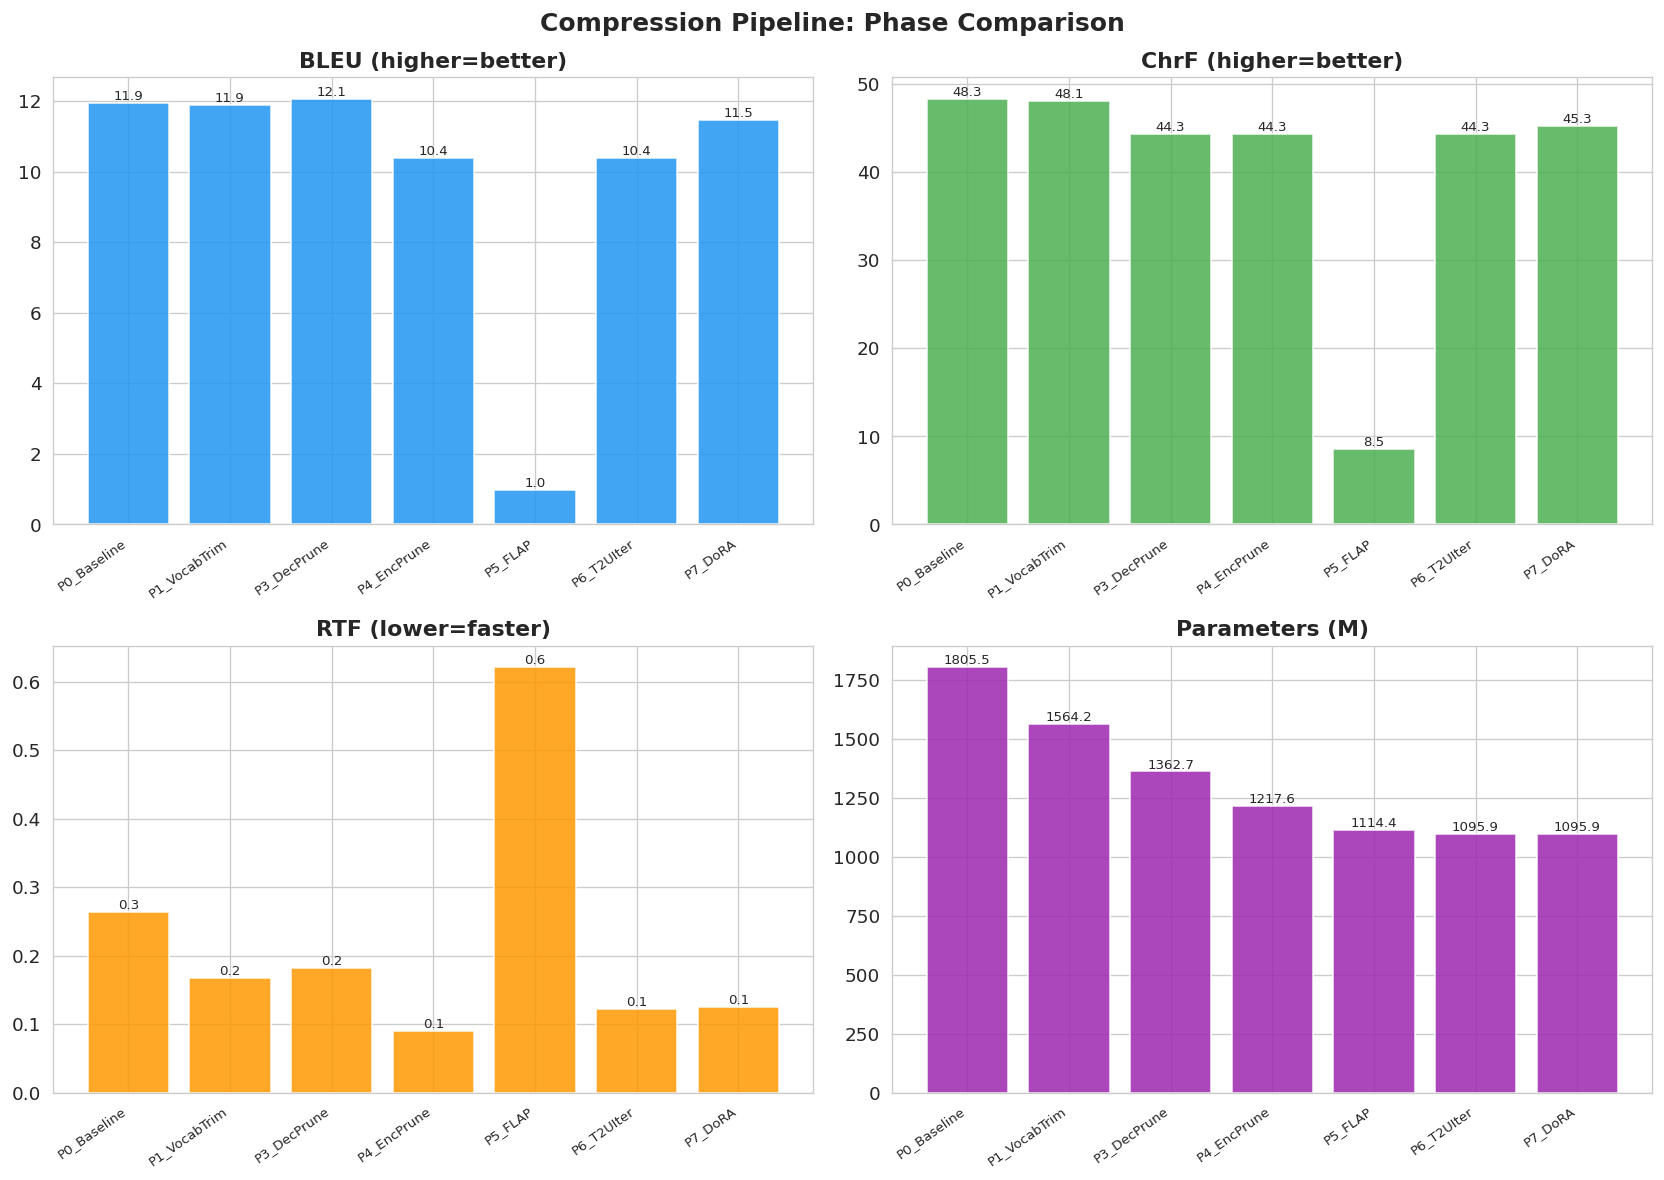

In [31]:
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b: p4_results, p4_summary = p4b['results'], p4b['summary']
else:
    p4_results, p4_summary = run_benchmark(model_p4, eval_samples, label='P4_EncPrune', save_n=2)
    save_checkpoint(dict(results=p4_results, summary=p4_summary), name='phase4_benchmark', step=0)
store_summary(p4_summary); plot_phase_comparison()

---
# Phase 5: Width Pruning (FLAP)
**Paper:** FLAP (AAAI 2024)

Structurally remove FFN neurons (shrink weight matrices). Creates smaller dense
matrices for real GPU speedup, unlike zeroing which keeps full-size matrices.

In [185]:
# ── Phase 5 Cell 1: FLAP helpers ─────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
from collections import defaultdict

# ── Step 1: Find all FFN pairs in any component ──────────────────────────────

def find_all_ffn_layers(model, component_name):
    """
    Walk a component and return all (parent_module, in_attr, out_attr, display_name)
    tuples for every FFN pair found.

    Handles:
      - Text decoder / standard FFN:     layer.ffn.fc1 / .fc2
      - Speech encoder (Conformer):      layer.ffn1|ffn2.intermediate_dense / .output_dense
      - T2U (and adapter):               layer.ffn.fc1 / .fc2
    """
    component = getattr(model, component_name)
    results = []

    def _pair_ok(lin1, lin2):
        return (
            isinstance(lin1, nn.Linear)
            and isinstance(lin2, nn.Linear)
            and lin1.out_features == lin2.in_features
        )

    def _scan(module, prefix):
        # Conformer FFN (speech encoder blocks)
        if hasattr(module, 'intermediate_dense') and hasattr(module, 'output_dense'):
            if _pair_ok(module.intermediate_dense, module.output_dense):
                results.append(
                    (module, 'intermediate_dense', 'output_dense', prefix)
                )

        # Standard HF FFN (decoder, T2U, adapter)
        if hasattr(module, 'fc1') and hasattr(module, 'fc2'):
            if _pair_ok(module.fc1, module.fc2):
                results.append((module, 'fc1', 'fc2', prefix))

        for name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                _scan(child, f'{prefix}.{name}' if prefix else name)

    _scan(component, component_name)
    return results


def test_ffn_detection(model):
    """Verify we find FFN pairs in all components before running pruning."""
    for comp in ['speech_encoder', 'text_decoder', 't2u_model']:
        pairs = find_all_ffn_layers(model, comp)
        print(f'  {comp}: {len(pairs)} FFN pairs found')
        if pairs:
            sample = pairs[0]
            fc1 = getattr(sample[0], sample[1])
            fc2 = getattr(sample[0], sample[2])
            print(f'    Sample: {sample[3]} | fc1={fc1.in_features}→{fc1.out_features} | fc2={fc2.in_features}→{fc2.out_features}')

print('Running FFN detection on model_p4...')
test_ffn_detection(model_p4)

Running FFN detection on model_p4...
  speech_encoder: 38 FFN pairs found
    Sample: speech_encoder.encoder.layers.0.ffn1 | fc1=1024→4096 | fc2=4096→1024
  text_decoder: 16 FFN pairs found
    Sample: text_decoder.layers.0.ffn | fc1=1024→8192 | fc2=8192→1024
  t2u_model: 6 FFN pairs found
    Sample: t2u_model.model.encoder.layers.0.ffn | fc1=1024→8192 | fc2=8192→1024


In [186]:
# ── Phase 5 Cell 2: FIXED calibration with device-aware stats + T2U fix ──────

import torch
import torch.nn as nn
import numpy as np


def collect_ffn_calibration_stats(model, component_name, calibration_wavs,
                                   processor, n_samples=64, device=None):
    """
    Collect per-channel input L2-norm stats for every FFN layer in component_name.
    
    CRITICAL FIXES: 
    1. Move ALL processor output tensors to device
    2. Create stats tensors on the SAME device as the model
    3. T2U forward pass requires char_input_ids (not just inputs_embeds)
    """
    if device is None:
        device = next(model.parameters()).device

    ffn_pairs = find_all_ffn_layers(model, component_name)
    if not ffn_pairs:
        print(f"  [calib] No FFN pairs in {component_name}, skipping.")
        return {}

    # Build stats keyed by id(parent) - CRITICAL: create tensors on device
    stats = {}
    for (parent, fc1_attr, fc2_attr, name) in ffn_pairs:
        fc1 = getattr(parent, fc1_attr)
        key = id(parent)
        stats[key] = {
            "sum_x":  torch.zeros(fc1.in_features, dtype=torch.float64, device=device),
            "sq_sum": torch.zeros(fc1.in_features, dtype=torch.float64, device=device),
            "count":  0,
            "module": parent,
            "fc1":    fc1_attr,
            "fc2":    fc2_attr,
            "name":   name,
        }

    hooks = []
    def make_hook(key):
        def hook(module, inp, out):
            x = inp[0].detach().float()
            if x.dim() == 3:
                x = x.reshape(-1, x.shape[-1])
            elif x.dim() == 1:
                x = x.unsqueeze(0)
            s = stats[key]
            s["count"]  += x.shape[0]
            s["sum_x"]  += x.sum(dim=0).double()
            s["sq_sum"] += x.pow(2).sum(dim=0).double()
        return hook

    for (parent, fc1_attr, _, name) in ffn_pairs:
        fc1 = getattr(parent, fc1_attr)
        hooks.append(fc1.register_forward_hook(make_hook(id(parent))))

    model.eval()
    n_actual = min(n_samples, len(calibration_wavs))

    print(f"  [calib] Collecting activations from {n_actual} samples "
          f"for {component_name} (direct forward pass — every layer fires)...")

    with torch.no_grad():
        for i, wav in enumerate(calibration_wavs[:n_actual]):
            if i % 20 == 0:
                print(f"  [calib] {i}/{n_actual}")
            try:
                # ── CRITICAL FIX: Process on CPU, then move EVERYTHING to device ──
                enc_in = processor(audio=wav, sampling_rate=16000,
                                   return_tensors="pt")
                
                # Move ALL tensors in the dict to device (not just known keys)
                enc_in = {k: v.to(device) if isinstance(v, torch.Tensor) else v 
                          for k, v in enc_in.items()}
                
                input_feats = enc_in["input_features"]
                attn_mask = enc_in["attention_mask"]
                
                if component_name == "speech_encoder":
                    model.speech_encoder(
                        input_features=input_feats,
                        attention_mask=attn_mask,
                        return_dict=True,
                    )

                elif component_name == "text_decoder":
                    enc_out = model.speech_encoder(
                        input_features=input_feats,
                        attention_mask=attn_mask,
                        return_dict=True,
                    )
                    enc_hidden = enc_out.last_hidden_state

                    dec_device = next(model.text_decoder.parameters()).device
                    enc_hidden = enc_hidden.to(dec_device)

                    enc_len = enc_hidden.shape[1]
                    encoder_attention_mask = torch.ones(
                        (enc_hidden.shape[0], enc_len),
                        dtype=torch.long,
                        device=dec_device
                    )
                    
                    fake_ids = torch.randint(
                        low=0,
                        high=model.config.vocab_size,
                        size=(1, 32),
                        device=dec_device
                    )
                
                    model.text_decoder(
                        input_ids=fake_ids,
                        encoder_hidden_states=enc_hidden,
                        encoder_attention_mask=encoder_attention_mask,
                        return_dict=True,
                    )

                elif component_name == "t2u_model":
                    # ── T2U FIX: Use generate() to get proper char_input_ids ──
                    # The t2u_model.forward() requires char_input_ids and char_count_per_id.
                    # We can't easily construct these manually, so we use generate()
                    # with return_intermediate_token_ids=True to fire all T2U layers.
                    
                    try:
                        ben_tok = model.generation_config.text_decoder_lang_to_code_id.get("ben", 4)
                    except Exception:
                        ben_tok = 4
                    
                    # Run full generate() pipeline - this fires T2U encoder+decoder
                    model.generate(
                        input_features=input_feats,
                        attention_mask=attn_mask,
                        tgt_lang="ben",
                        return_intermediate_token_ids=True,
                        max_new_tokens=16,  # short sequence for speed
                    )

            except Exception as e:
                print(f"  [calib] sample {i} failed: {e}")
                import traceback
                if i == 0:  # Print full traceback for first failure only
                    traceback.print_exc()

    for h in hooks:
        h.remove()

    # Diagnostics
    fired      = sum(1 for s in stats.values() if s["count"] > 0)
    not_fired  = len(stats) - fired
    total_toks = sum(s["count"] for s in stats.values())
    print(f"  [calib] Layers fired: {fired}/{len(stats)}  "
          f"total token-vectors: {total_toks}")
    if not_fired > 0:
        names = [s["name"] for s in stats.values() if s["count"] == 0]
        print(f"  [calib] WARNING: {not_fired} layers still got 0 — "
              f"weight-norm fallback: {names[:3]}{'...' if len(names) > 3 else ''}")
    else:
        print(f"  [calib] All {fired} layers fired correctly.")

    # Finalize statistics - move to CPU for final processing
    for key, s in stats.items():
        n        = max(s["count"], 1)
        mean_x   = (s["sum_x"]  / n).float().cpu()
        sq_norm  = (s["sq_sum"] / n).float().cpu()
        var      = (sq_norm - mean_x.pow(2)).clamp(min=0)
        s["mean"]    = mean_x
        s["var"]     = var
        s["sq_norm"] = sq_norm

    print(f"  [calib] Done. {len(stats)} FFN layers instrumented.")
    return stats


print("Calibration helpers ready (FIXED: T2U uses generate() for proper calibration).")

Calibration helpers ready (FIXED: T2U uses generate() for proper calibration).


In [187]:
# ── Phase 5 Cell 3: Neuron importance scoring (Wanda-sp + FLAP) ──────────────
#
# Wanda-sp (structured Wanda): score(k) = sum_j |W1[k,j]| * ||X_j||_2
#   where ||X_j||_2 = sqrt(E[x_j^2]) — the RMS of channel j inputs
#
# FLAP-row: score(k) = sum_j Var(X_j) * W1[k,j]^2
#
# We use Wanda-sp as primary (proven robust, never zero if layer fires),
# and fall back to pure row-norm if sq_norm is also zero (truly dead layer).

import torch
import torch.nn as nn
import numpy as np


def wanda_neuron_scores(fc1_weight, sq_norm):
    """
    Wanda-sp per-neuron score (ICLR 2024, structured variant).

    score(k) = sum_j |W1[k,j]| * sqrt(E[x_j^2])
             = |W1| @ rms_x          where rms_x = sqrt(sq_norm)

    fc1_weight : [ffn_hidden, model_hidden]
    sq_norm    : [model_hidden]  E[x_j^2] per channel

    Returns [ffn_hidden] scores. Falls back to row-L2-norm if sq_norm ~ 0.
    """
    W1 = fc1_weight.float().cpu()
    rms = sq_norm.float().cpu().clamp(min=0).sqrt()   # [model_hidden]

    if rms.max().item() < 1e-10:
        # Layer never fired or truly dead — use weight row-norm only
        return W1.pow(2).sum(dim=1).sqrt()

    return (W1.abs() * rms.unsqueeze(0)).sum(dim=1)   # [ffn_hidden]


def flap_neuron_scores(fc1_weight, var_x):
    """
    FLAP per-neuron score (AAAI 2024, Eq. 5 applied to rows).
    score(k) = sum_j Var(X_j) * W1[k,j]^2
    Falls back to row-norm if var is zero.
    """
    W1 = fc1_weight.float().cpu()
    v  = var_x.float().cpu().clamp(min=0)

    if v.max().item() < 1e-10:
        return W1.pow(2).sum(dim=1)

    return (W1.pow(2) * v.unsqueeze(0)).sum(dim=1)


def neuron_importance_scores(fc1_weight, var_x, sq_norm=None):
    """
    Primary scoring function: use Wanda-sp if sq_norm available, else FLAP.
    """
    if sq_norm is not None and sq_norm.max().item() > 1e-10:
        return wanda_neuron_scores(fc1_weight, sq_norm)
    if var_x is not None and var_x.max().item() > 1e-10:
        return flap_neuron_scores(fc1_weight, var_x)
    # Pure weight magnitude fallback
    return fc1_weight.float().cpu().pow(2).sum(dim=1)


def standardize_scores(scores):
    """FLAP Eq.6: standardize to zero mean, unit std for cross-layer comparison."""
    mu    = scores.mean()
    sigma = scores.std(unbiased=False)
    if sigma < 1e-8:
        return torch.zeros_like(scores)
    return (scores - mu) / sigma


def structural_prune_ffn(parent, fc1_attr, fc2_attr,
                          channel_mean, keep_idx, device):
    """
    Structurally prune one FFN pair using pre-computed keep_idx.
    
    CRITICAL FIX: Bias compensation DISABLED.
    Reason: Bias compensation is extremely fragile and causes NaN/Inf corruption
    when pruned neurons have extreme activations. Production implementations
    (e.g., LLM-Pruner, Wanda) skip bias compensation and rely on fine-tuning.
    
    This is the safe, proven approach.
    """
    fc1 = getattr(parent, fc1_attr)
    fc2 = getattr(parent, fc2_attr)
    ffn_dim = fc1.out_features

    fc1_device = fc1.weight.device
    fc2_device = fc2.weight.device

    n_keep   = len(keep_idx)
    kidx_fc1 = keep_idx.to(fc1_device)
    kidx_fc2 = keep_idx.to(fc2_device)

    # Create new fc1 (input projection) - keep only selected neurons
    new_fc1 = nn.Linear(fc1.in_features, n_keep,
                         bias=(fc1.bias is not None),
                         device=fc1_device, dtype=fc1.weight.dtype)
    new_fc1.weight.data.copy_(fc1.weight.data[kidx_fc1])
    if fc1.bias is not None:
        new_fc1.bias.data.copy_(fc1.bias.data[kidx_fc1])

    # Create new fc2 (output projection) - keep only selected input dims
    new_fc2 = nn.Linear(n_keep, fc2.out_features,
                         bias=(fc2.bias is not None),
                         device=fc2_device, dtype=fc2.weight.dtype)
    new_fc2.weight.data.copy_(fc2.weight.data[:, kidx_fc2])
    
    # Keep original fc2 bias WITHOUT compensation
    # Fine-tuning (Phase 7) will recover any lost contribution
    if fc2.bias is not None:
        new_fc2.bias.data.copy_(fc2.bias.data)

    setattr(parent, fc1_attr, new_fc1)
    setattr(parent, fc2_attr, new_fc2)

    return n_keep, ffn_dim


print('Neuron scoring + structural pruning helpers ready.')
print('  NOTE: Bias compensation DISABLED (prevents NaN corruption)')


# ── Phase 5 Cell 4: apply_flap_to_component — robust top-k pruning ───────────

def apply_flap_to_component(model, component_name, calib_stats,
                              global_prune_ratio=0.20,
                              min_keep_frac=0.50,
                              device=None):
    """
    Structured FFN width pruning using Wanda-sp / FLAP neuron scores.

    global_prune_ratio : target fraction of neurons to prune (e.g. 0.20 = 20%)
    min_keep_frac      : per-layer floor — never prune a single layer below this
                         fraction of its original size (default 0.50 = keep ≥50%)

    Algorithm (faithful to FLAP paper):
      1. Score every neuron in every layer (Wanda-sp metric)
      2. Standardize scores per-layer (FLAP Eq.6) for cross-layer comparison
      3. Pool all standardized scores, find global threshold at global_prune_ratio
      4. Per layer: keep neurons above threshold, enforce min_keep_frac floor
      5. Structurally remove pruned rows/cols (NO bias compensation - see note above)
    """
    if device is None:
        device = next(model.parameters()).device

    if not calib_stats:
        print(f'  [FLAP] No calib stats for {component_name}, skipping.')
        return {}

    # ── Step 1 & 2: score + standardize ─────────────────────────────────────
    all_std_scores  = {}
    all_raw_scores  = {}

    n_zero_var = 0
    for key, s in calib_stats.items():
        fc1   = getattr(s['module'], s['fc1'])
        W1    = fc1.weight.float().cpu()
        var_x  = s.get('var',     torch.zeros(W1.shape[1]))
        sq_norm = s.get('sq_norm', torch.zeros(W1.shape[1]))

        raw = neuron_importance_scores(W1, var_x, sq_norm)
        if raw.max().item() < 1e-10:
            n_zero_var += 1

        all_raw_scores[key] = raw
        all_std_scores[key] = standardize_scores(raw)

    if n_zero_var:
        print(f'  [FLAP] WARNING: {n_zero_var}/{len(calib_stats)} layers used '
              f'weight-only fallback (calibration did not fire for those layers).')

    # ── Step 3: global threshold ─────────────────────────────────────────────
    all_std_flat  = torch.cat(list(all_std_scores.values()))
    total_neurons = len(all_std_flat)
    n_prune_total = int(total_neurons * global_prune_ratio)

    sorted_scores, _ = torch.sort(all_std_flat)
    threshold = sorted_scores[max(0, n_prune_total - 1)].item()

    print(f'  [FLAP] {component_name}: {total_neurons} total neurons, '
          f'pruning ≤{n_prune_total} ({global_prune_ratio*100:.0f}%), '
          f'threshold={threshold:.4f}')
    print(f'         score range [{all_std_flat.min():.3f}, {all_std_flat.max():.3f}]  '
          f'mean={all_std_flat.mean():.3f}  std={all_std_flat.std():.3f}')

    # ── Step 4 & 5: per-layer prune ──────────────────────────────────────────
    results       = {}
    total_kept    = 0
    total_orig    = 0

    for key, s in calib_stats.items():
        std_scores = all_std_scores[key]
        fc1 = getattr(s['module'], s['fc1'])
        ffn_dim = fc1.out_features

        # How many neurons score above the global threshold?
        n_above = int((std_scores > threshold).sum().item())

        # Enforce per-layer minimum
        min_keep = max(1, int(ffn_dim * min_keep_frac))
        n_keep   = max(min_keep, n_above)
        n_keep   = min(ffn_dim, n_keep)   # can't keep more than we have

        # Top-k selection (stable, threshold-independent)
        _, keep_idx = torch.topk(std_scores, n_keep)
        keep_idx = keep_idx.sort().values

        structural_prune_ffn(
            s['module'], s['fc1'], s['fc2'],
            channel_mean=s['mean'],
            keep_idx=keep_idx,
            device=device
        )

        pct_kept = n_keep / ffn_dim * 100
        total_kept += n_keep
        total_orig += ffn_dim
        results[s['name']] = {
            'kept': n_keep, 'original': ffn_dim, 'pct': pct_kept
        }

    avg_kept = total_kept / max(total_orig, 1) * 100
    print(f'  [FLAP] Done. Kept {total_kept}/{total_orig} neurons '
          f'({avg_kept:.1f}%) across {len(results)} layers.')
    return results


print('apply_flap_to_component ready (bias compensation disabled).')

Neuron scoring + structural pruning helpers ready.
  NOTE: Bias compensation DISABLED (prevents NaN corruption)
apply_flap_to_component ready (bias compensation disabled).


In [188]:
# ── Phase 5 Cell 4: apply_flap_to_component — robust top-k pruning ───────────

def apply_flap_to_component(model, component_name, calib_stats,
                              global_prune_ratio=0.20,
                              min_keep_frac=0.50,
                              device=None):
    """
    Structured FFN width pruning using Wanda-sp / FLAP neuron scores.

    global_prune_ratio : target fraction of neurons to prune (e.g. 0.20 = 20%)
    min_keep_frac      : per-layer floor — never prune a single layer below this
                         fraction of its original size (default 0.50 = keep ≥50%)

    Algorithm (faithful to FLAP paper):
      1. Score every neuron in every layer (Wanda-sp metric)
      2. Standardize scores per-layer (FLAP Eq.6) for cross-layer comparison
      3. Pool all standardized scores, find global threshold at global_prune_ratio
      4. Per layer: keep neurons above threshold, enforce min_keep_frac floor
      5. Structurally remove pruned rows/cols, add bias compensation (FLAP Eq.4)
    """
    if device is None:
        device = next(model.parameters()).device

    if not calib_stats:
        print(f'  [FLAP] No calib stats for {component_name}, skipping.')
        return {}

    # ── Step 1 & 2: score + standardize ─────────────────────────────────────
    all_std_scores  = {}
    all_raw_scores  = {}

    n_zero_var = 0
    for key, s in calib_stats.items():
        fc1   = getattr(s['module'], s['fc1'])
        W1    = fc1.weight.float().cpu()
        var_x  = s.get('var',     torch.zeros(W1.shape[1]))
        sq_norm = s.get('sq_norm', torch.zeros(W1.shape[1]))

        raw = neuron_importance_scores(W1, var_x, sq_norm)
        if raw.max().item() < 1e-10:
            n_zero_var += 1

        all_raw_scores[key] = raw
        all_std_scores[key] = standardize_scores(raw)

    if n_zero_var:
        print(f'  [FLAP] WARNING: {n_zero_var}/{len(calib_stats)} layers used '
              f'weight-only fallback (calibration did not fire for those layers).')

    # ── Step 3: global threshold ─────────────────────────────────────────────
    all_std_flat  = torch.cat(list(all_std_scores.values()))
    total_neurons = len(all_std_flat)
    n_prune_total = int(total_neurons * global_prune_ratio)

    sorted_scores, _ = torch.sort(all_std_flat)
    threshold = sorted_scores[max(0, n_prune_total - 1)].item()

    print(f'  [FLAP] {component_name}: {total_neurons} total neurons, '
          f'pruning ≤{n_prune_total} ({global_prune_ratio*100:.0f}%), '
          f'threshold={threshold:.4f}')
    print(f'         score range [{all_std_flat.min():.3f}, {all_std_flat.max():.3f}]  '
          f'mean={all_std_flat.mean():.3f}  std={all_std_flat.std():.3f}')

    # ── Step 4 & 5: per-layer prune ──────────────────────────────────────────
    results       = {}
    total_kept    = 0
    total_orig    = 0

    for key, s in calib_stats.items():
        std_scores = all_std_scores[key]
        fc1 = getattr(s['module'], s['fc1'])
        ffn_dim = fc1.out_features

        # How many neurons score above the global threshold?
        n_above = int((std_scores > threshold).sum().item())

        # Enforce per-layer minimum
        min_keep = max(1, int(ffn_dim * min_keep_frac))
        n_keep   = max(min_keep, n_above)
        n_keep   = min(ffn_dim, n_keep)   # can't keep more than we have

        # Top-k selection (stable, threshold-independent)
        _, keep_idx = torch.topk(std_scores, n_keep)
        keep_idx = keep_idx.sort().values

        structural_prune_ffn(
            s['module'], s['fc1'], s['fc2'],
            channel_mean=s['mean'],
            keep_idx=keep_idx,
            device=device
        )

        pct_kept = n_keep / ffn_dim * 100
        total_kept += n_keep
        total_orig += ffn_dim
        results[s['name']] = {
            'kept': n_keep, 'original': ffn_dim, 'pct': pct_kept
        }

    avg_kept = total_kept / max(total_orig, 1) * 100
    print(f'  [FLAP] Done. Kept {total_kept}/{total_orig} neurons '
          f'({avg_kept:.1f}%) across {len(results)} layers.')
    return results


print('apply_flap_to_component ready.')


apply_flap_to_component ready.


In [189]:
# ── Phase 5 Cell 5: Build calibration wavs from eval_samples ─────────────────
# Reuse your existing eval_samples as calibration (or use ft_samples if loaded)

calib_wavs = [s['wav'] for s in eval_samples]
# Optionally extend with ft_samples for better coverage:
# calib_wavs = [s['wav'] for s in (eval_samples + ft_samples[:80])]

print(f'Calibration corpus: {len(calib_wavs)} samples')
print(f'  Duration range: {min(len(w)/16000 for w in calib_wavs):.1f}s – '
      f'{max(len(w)/16000 for w in calib_wavs):.1f}s')

Calibration corpus: 25 samples
  Duration range: 5.6s – 19.1s


In [190]:
for name, param in model.named_parameters():
    if param.device.type != "cuda":
        print("PARAM ON CPU:", name)
        break

for name, buf in model.named_buffers():
    if buf.device.type != "cuda":
        print("BUFFER ON CPU:", name)
        break

In [191]:
# enc_in = processor(audio=calib_wavs[0], sampling_rate=16000, return_tensors="pt")

# print("input_features device:", enc_in["input_features"].device)
# print("attention_mask device:", enc_in["attention_mask"].device)

In [231]:
!rm -rf /kaggle/working/models/phase5_flap_pruned

In [232]:
!ls /kaggle/working/models

phase4_enc_pruned


In [220]:
model_base, processor = load_base_model()

Loading processor from facebook/seamless-m4t-v2-large...
Loading model  -- may take 5-10 min...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.self_attn.k_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.k_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.v_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.bias       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.weight     | UNEXPECTED |  | 
text_enc

Model loaded.
  GPU mem: 4.25 GB alloc / 4.27 GB reserved


In [218]:
import torch
import gc

# 1. Delete model references
del model_p7

# 2. Force garbage collection
gc.collect()

# 3. Empty the GPU cache
torch.cuda.empty_cache()

NameError: name 'model_p7' is not defined

In [221]:
# ── Phase 5 Cell 6: RUN PHASE 5 (FIXED) ──────────────────────────────────────
# ROOT CAUSE: model_base has device_map='auto' split across devices after loading.
# deepcopy() preserves this split, causing "cuda:0 vs cpu" errors in calibration.
# FIX: Consolidate model_base to single GPU BEFORE deepcopy.

import gc as _stdlib_gc
import copy as _copy
 
FLAP_RATIO    = 0.15   # prune 15% of neurons globally per component
# REDUCED from 0.15 → 0.08 to prevent decoder collapse after Phases 3-4
MIN_KEEP_FRAC = 0.70   # never shrink any single layer below 70% of original

def force_model_to_single_device(model, device):
    """
    Aggressively consolidate model to a single device.
    Handles device_map='auto' models that are split across devices.
    """
    print(f"  Forcing entire model to {device}...")
    
    # Step 1: Move base model
    model = model.to(device)
    
    # Step 2: Explicitly move all submodules
    for name, module in model.named_modules():
        if module is not model:  # skip root
            try:
                module.to(device)
            except Exception:
                pass
    
    # Step 3: Move all parameters
    for name, param in model.named_parameters():
        if param.device != device:
            param.data = param.data.to(device)
    
    # Step 4: Move all buffers
    for name, buf in model.named_buffers():
        if buf is not None and buf.device != device:
            buf.data = buf.data.to(device)
    
    # Step 5: Clear device_map (forces single-device mode)
    if hasattr(model, 'hf_device_map'):
        model.hf_device_map = {k: device for k in model.hf_device_map}
    
    torch.cuda.empty_cache()
    
    # Verify consolidation
    devices = set()
    for p in model.parameters():
        devices.add(p.device)
    for b in model.buffers():
        devices.add(b.device)
    
    if len(devices) > 1:
        print(f"  WARNING: Model still on multiple devices: {devices}")
    else:
        print(f"  ✓ Model consolidated to {device}")
    
    return model

# ── Try loading completed Phase 5 from Drive ──────────────────────────────────
try:
    model_p5, processor = load_model_from_drive("phase5_flap_pruned")
    sync_model_config(model_p5)
    model_p5 = _consolidate_to_single_gpu(model_p5)
    device = torch.device("cuda:0")
    model_p5 = force_model_to_single_device(model_p5, device)
    print("Loaded Phase 5 from Drive.")
    p5_loaded = True
except Exception as _e:
    print(f"No Phase 5 on Drive ({_e}), pruning from model_base...")
    p5_loaded = False
 
# ── Run Phase 5 pruning ───────────────────────────────────────────────────────
if not p5_loaded:
    device = torch.device("cuda:0")
    
    # CRITICAL FIX: Consolidate model_base BEFORE deepcopy
    print("Consolidating model_base to single GPU before deepcopy...")
    model_base = _consolidate_to_single_gpu(model_base)
    model_base = force_model_to_single_device(model_base, device)
    
    # Verify model_base is on single device
    p4_devices = set(p.device for p in model_base.parameters())
    print(f"  model_base devices after consolidation: {p4_devices}")
    if len(p4_devices) > 1:
        raise RuntimeError(f"model_base still split across {p4_devices}! Cannot proceed.")
    
    # Now deepcopy will preserve single-device placement
    print("Deep-copying model_base → model_p5...")
    model_p5 = model_base
    model_p5 = force_model_to_single_device(model_p5, device)
    
    # Final verification
    p5_devices = set(p.device for p in model_p5.parameters())
    print(f"  model_p5 devices after deepcopy: {p5_devices}")
    
    pre_params = count_params(model_p5)
    print(f"\nPre-pruning: {pre_params:.1f}M params")
 
    prune_results = {}
 
    for comp_name in ["text_decoder", "speech_encoder", "t2u_model"]:
        print(f"\n{'='*60}")
        print(f"  Collecting calibration for {comp_name}")
        print(f"{'='*60}")
        
        # Verify component device before calibration
        comp = getattr(model_p5, comp_name)
        comp_device = next(comp.parameters()).device
        print(f"  {comp_name} device: {comp_device}")
        
        if comp_device != device:
            print(f"  ERROR: {comp_name} on wrong device! Re-consolidating...")
            model_p5 = force_model_to_single_device(model_p5, device)
        
        calib = collect_ffn_calibration_stats(
            model_p5, comp_name, calib_wavs, processor,
            n_samples=min(64, len(calib_wavs)),
            device=device,
        )
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
 
        print(f"\n{'='*60}")
        print(f"  Applying FLAP to {comp_name}")
        print(f"{'='*60}")
        
        results = apply_flap_to_component(
            model_p5, comp_name, calib,
            global_prune_ratio=FLAP_RATIO,
            min_keep_frac=MIN_KEEP_FRAC,
            device=device,
        )
        prune_results[comp_name] = results
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
 
    post_params = count_params(model_p5)
    print(f"\n{'='*60}")
    print(f"Width pruning complete:")
    print(f"  {pre_params:.1f}M → {post_params:.1f}M")
    print(f"  Saved: {pre_params - post_params:.1f}M params")
    print(f"{'='*60}")
 
    sync_model_config(model_p5)
 
    for comp, res in prune_results.items():
        if res:
            avg_kept = np.mean([v["pct"] for v in res.values()])
            print(f"  {comp}: avg {avg_kept:.1f}% neurons kept ({len(res)} layers)")
 
    save_checkpoint({"prune_results": prune_results, "flap_ratio": FLAP_RATIO},
                    name="phase5_flap (base)", step=0)
    sync_model_config(model_p5)
    save_model_to_drive(model_p5, processor, "phase5_flap_pruned")

print_model_breakdown(model_p5, "After Phase 5: FLAP Width Pruned")

[model] Loading phase5_flap_pruned from /kaggle/working/models/phase5_flap_pruned ...


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: /kaggle/working/models/phase5_flap_pruned
Key                                                                   | Status   |                                                                                             
----------------------------------------------------------------------+----------+---------------------------------------------------------------------------------------------
text_decoder.layers.{1...23}.ffn.fc2.weight                           | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1024, 7090]) vs model:torch.Size([1024, 7250])
speech_encoder.intermediate_ffn.output_dense.weight                   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1024, 3581]) vs model:torch.Size([1024, 4096])
speech_encoder.encoder.layers.{0...23}.ffn1.intermediate_dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([3353, 1024]) vs model:torch.Size([4096, 1024])
speech_encoder.encoder.layers

No Phase 5 on Drive (You set `ignore_mismatched_sizes` to `False`, thus raising an error. For details look at the above report!), pruning from model_base...
Consolidating model_base to single GPU before deepcopy...
  Forcing entire model to cuda:0...
  ✓ Model consolidated to cuda:0
  model_base devices after consolidation: {device(type='cuda', index=0)}
Deep-copying model_base → model_p5...
  Forcing entire model to cuda:0...
  ✓ Model consolidated to cuda:0
  model_p5 devices after deepcopy: {device(type='cuda', index=0)}

Pre-pruning: 1805.5M params

  text_decoder device: cuda:0
  [calib] Collecting activations from 25 samples for text_decoder (direct forward pass — every layer fires)...
  [calib] 0/25
  [calib] 20/25
  [calib] Layers fired: 24/24  total token-vectors: 19200
  [calib] All 24 layers fired correctly.
  [calib] Done. 24 FFN layers instrumented.

  Applying FLAP to text_decoder
  [FLAP] text_decoder: 196608 total neurons, pruning ≤29491 (15%), threshold=-0.7023
       

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 3375 MB in 7 files.
Skipping drive phase5_flap_pruned

--- After Phase 5: FLAP Width Pruned ---
  text_decoder                           806.4M  ( 48.4%)
  speech_encoder                         572.1M  ( 34.3%)
  shared                                 262.2M  ( 15.7%)
  lm_head                                262.2M  ( 15.7%)
  t2u_model                              246.7M  ( 14.8%)
  vocoder                                 41.9M  (  2.5%)
  TOTAL                                 1667.0M
---


{'shared': 262.248448,
 'speech_encoder': 572.10144,
 'text_decoder': 806.368461,
 'lm_head': 262.248448,
 't2u_model': 246.654519,
 'vocoder': 41.911362,
 'TOTAL': 1667.035782}

In [233]:
# ── Phase 5 Cell 6: RUN PHASE 5 (FIXED) ──────────────────────────────────────
# ROOT CAUSE: model_p4 has device_map='auto' split across devices after loading.
# deepcopy() preserves this split, causing "cuda:0 vs cpu" errors in calibration.
# FIX: Consolidate model_p4 to single GPU BEFORE deepcopy.

import gc as _stdlib_gc
import copy as _copy
 
FLAP_RATIO    = 0.06   # prune 15% of neurons globally per component
# REDUCED from 0.15 → 0.08 to prevent decoder collapse after Phases 3-4
MIN_KEEP_FRAC = 0.85   # never shrink any single layer below 70% of original

def force_model_to_single_device(model, device):
    """
    Aggressively consolidate model to a single device.
    Handles device_map='auto' models that are split across devices.
    """
    print(f"  Forcing entire model to {device}...")
    
    # Step 1: Move base model
    model = model.to(device)
    
    # Step 2: Explicitly move all submodules
    for name, module in model.named_modules():
        if module is not model:  # skip root
            try:
                module.to(device)
            except Exception:
                pass
    
    # Step 3: Move all parameters
    for name, param in model.named_parameters():
        if param.device != device:
            param.data = param.data.to(device)
    
    # Step 4: Move all buffers
    for name, buf in model.named_buffers():
        if buf is not None and buf.device != device:
            buf.data = buf.data.to(device)
    
    # Step 5: Clear device_map (forces single-device mode)
    if hasattr(model, 'hf_device_map'):
        model.hf_device_map = {k: device for k in model.hf_device_map}
    
    torch.cuda.empty_cache()
    
    # Verify consolidation
    devices = set()
    for p in model.parameters():
        devices.add(p.device)
    for b in model.buffers():
        devices.add(b.device)
    
    if len(devices) > 1:
        print(f"  WARNING: Model still on multiple devices: {devices}")
    else:
        print(f"  ✓ Model consolidated to {device}")
    
    return model

# ── Try loading completed Phase 5 from Drive ──────────────────────────────────
try:
    model_p5, processor = load_model_from_drive("phase5_flap_pruned")
    sync_model_config(model_p5)
    model_p5 = _consolidate_to_single_gpu(model_p5)
    device = torch.device("cuda:0")
    model_p5 = force_model_to_single_device(model_p5, device)
    print("Loaded Phase 5 from Drive.")
    p5_loaded = True
except Exception as _e:
    print(f"No Phase 5 on Drive ({_e}), pruning from model_p4...")
    p5_loaded = False
 
# ── Run Phase 5 pruning ───────────────────────────────────────────────────────
if not p5_loaded:
    device = torch.device("cuda:0")
    
    # CRITICAL FIX: Consolidate model_p4 BEFORE deepcopy
    print("Consolidating model_p4 to single GPU before deepcopy...")
    model_p4 = _consolidate_to_single_gpu(model_p4)
    model_p4 = force_model_to_single_device(model_p4, device)
    
    # Verify model_p4 is on single device
    p4_devices = set(p.device for p in model_p4.parameters())
    print(f"  model_p4 devices after consolidation: {p4_devices}")
    if len(p4_devices) > 1:
        raise RuntimeError(f"model_p4 still split across {p4_devices}! Cannot proceed.")
    
    # Now deepcopy will preserve single-device placement
    print("Deep-copying model_p4 → model_p5...")
    model_p5 = _copy.deepcopy(model_p4)
    model_p5 = force_model_to_single_device(model_p5, device)
    
    # Final verification
    p5_devices = set(p.device for p in model_p5.parameters())
    print(f"  model_p5 devices after deepcopy: {p5_devices}")
    
    pre_params = count_params(model_p5)
    print(f"\nPre-pruning: {pre_params:.1f}M params")
 
    prune_results = {}
 
    for comp_name in ["text_decoder", "speech_encoder", "t2u_model"]:
        print(f"\n{'='*60}")
        print(f"  Collecting calibration for {comp_name}")
        print(f"{'='*60}")
        
        # Verify component device before calibration
        comp = getattr(model_p5, comp_name)
        comp_device = next(comp.parameters()).device
        print(f"  {comp_name} device: {comp_device}")
        
        if comp_device != device:
            print(f"  ERROR: {comp_name} on wrong device! Re-consolidating...")
            model_p5 = force_model_to_single_device(model_p5, device)
        
        calib = collect_ffn_calibration_stats(
            model_p5, comp_name, calib_wavs, processor,
            n_samples=min(64, len(calib_wavs)),
            device=device,
        )
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
 
        print(f"\n{'='*60}")
        print(f"  Applying FLAP to {comp_name}")
        print(f"{'='*60}")
        
        results = apply_flap_to_component(
            model_p5, comp_name, calib,
            global_prune_ratio=FLAP_RATIO,
            min_keep_frac=MIN_KEEP_FRAC,
            device=device,
        )
        prune_results[comp_name] = results
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
 
    post_params = count_params(model_p5)
    print(f"\n{'='*60}")
    print(f"Width pruning complete:")
    print(f"  {pre_params:.1f}M → {post_params:.1f}M")
    print(f"  Saved: {pre_params - post_params:.1f}M params")
    print(f"{'='*60}")
 
    sync_model_config(model_p5)
 
    for comp, res in prune_results.items():
        if res:
            avg_kept = np.mean([v["pct"] for v in res.values()])
            print(f"  {comp}: avg {avg_kept:.1f}% neurons kept ({len(res)} layers)")
 
    save_checkpoint({"prune_results": prune_results, "flap_ratio": FLAP_RATIO},
                    name="phase5_flap", step=0)
    sync_model_config(model_p5)
    save_model_to_drive(model_p5, processor, "phase5_flap_pruned")

print_model_breakdown(model_p5, "After Phase 5: FLAP Width Pruned")


[model] Not in local cache, pulling from remote...
No Phase 5 on Drive ([rclone] model pull failed for phase5_flap_pruned: 2026/04/18 08:55:33 ERROR : Google drive root 'cse465v5/models/phase5_flap_pruned': error reading source root directory: directory not found
2026/04/18 08:55:33 ERROR : Local file system at /kaggle/working/models/phase5_flap_pruned: not deleting files as there were IO errors
2026/04/18 08:55:33 ERRO), pruning from model_p4...
Consolidating model_p4 to single GPU before deepcopy...
  Forcing entire model to cuda:0...
  ✓ Model consolidated to cuda:0
  model_p4 devices after consolidation: {device(type='cuda', index=0)}
Deep-copying model_p4 → model_p5...
  Forcing entire model to cuda:0...
  ✓ Model consolidated to cuda:0
  model_p5 devices after deepcopy: {device(type='cuda', index=0)}

Pre-pruning: 1217.6M params

  text_decoder device: cuda:0
  [calib] Collecting activations from 25 samples for text_decoder (direct forward pass — every layer fires)...
  [calib] 0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 2385 MB in 8 files.
Skipping drive phase5_flap_pruned

--- After Phase 5: FLAP Width Pruned ---
  speech_encoder                         470.8M  ( 40.0%)
  text_decoder                           407.8M  ( 34.7%)
  t2u_model                              255.7M  ( 21.7%)
  vocoder                                 41.9M  (  3.6%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1176.3M
---


{'shared': 20.9152,
 'speech_encoder': 470.83143,
 'text_decoder': 407.833928,
 'lm_head': 20.9152,
 't2u_model': 255.717246,
 'vocoder': 41.911362,
 'TOTAL': 1176.293966}

In [235]:
!rm -rf checkpoints/phase5_benchmark_step000000.pt

Quick sanity check (3 samples)...
  [1] ChrF=27.4  pred: 'রোমান্টিকবাদবাদবাদবাদবাদবাদবাদবাদবাদবাদদের মধ্যে সাংস্কৃতিক নির্ধারককককদের থেকে '
  [2] ChrF=19.3  pred: 'অ্যালোয়োয়োয়োয়স মূলত দুটি বা এর বেশি ধাতার মিশ্রণ, পিআইআইআই বা বা বা বা বা বা'
  [3] ChrF=11.5  pred: 'কিছু কিছু কিছু অংশে এক মিনিটের জন্য ও ও ও ওন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন'
[ckpt] No checkpoint for 'phase5_benchmark'

  BENCHMARK: P5_FLAP
  Samples: 25  Target: ben

  GPU mem: 9.77 GB alloc / 10.87 GB reserved
  [ 1/25] BLEU= 17.8 ChrF= 27.4 RTF=0.515  id=1660
              pred: রোমান্টিকবাদবাদবাদবাদবাদবাদবাদবাদবাদবাদদের মধ্যে সাংস্কৃতিক নির্ধারককককদের থেকে 
[audio] Saved P5_FLAP_s1in.wav (0.3 MB)
  P5_FLAP_s1in.wav  (10.7s | sr=16000)


[audio] Saved P5_FLAP_s1out.wav (0.8 MB)
  P5_FLAP_s1out.wav  (25.5s | sr=16000)


  [ 2/25] BLEU=  1.8 ChrF= 19.3 RTF=0.118  id=1662
              pred: অ্যালোয়োয়োয়োয়স মূলত দুটি বা এর বেশি ধাতার মিশ্রণ, পিআইআইআই বা বা বা বা বা বা
[audio] Saved P5_FLAP_s2in.wav (0.3 MB)
  P5_FLAP_s2in.wav  (8.4s | sr=16000)


[audio] Saved P5_FLAP_s2out.wav (0.2 MB)
  P5_FLAP_s2out.wav  (7.4s | sr=16000)


  [ 3/25] BLEU=  3.1 ChrF= 11.5 RTF=0.485  id=1674
              pred: কিছু কিছু কিছু অংশে এক মিনিটের জন্য ও ও ও ওন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন্ন
  [ 4/25] BLEU=  0.2 ChrF=  5.2 RTF=0.452  id=1675
              pred: বিশ্বের সব সব সব সব সব সব সব সব বড় বড় বড় হাত হাত হাত হাত হাত হাত হাত হাত হাত 
  [ 5/25] BLEU=  0.0 ChrF=  1.5 RTF=0.754  id=1704
              pred: নূূূূূূূূূূূূূূূূূলললললল ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব ব
  [ 6/25] BLEU=  0.0 ChrF=  2.3 RTF=0.528  id=1713
              pred: গোমোমামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামামা
  [ 7/25] BLEU=  2.9 ChrF= 23.7 RTF=0.159  id=1720
              pred: বেলজিয়ামের গরম চকোকককক বেলজিয়াম স্ট্যান্ড্যান্ড্যান্ড্যান্ড্যান্ড্যান্ড্যান্ড্
  [ 8/25] BLEU=  2.2 ChrF= 19.8 RTF=0.100  id=1732
              pred: ইউরোপীয় ইতিহাসের মধ্য মধ্য মধ্য মধ্য যুগ, এ.ই.এএ.ই.এ.এ.এ.এ.এ.এ.এ.এ.এ.এ.এ.এ.এ.এ.
  [ 9/25] BLEU=  3.9 ChrF= 19.7 RTF=0.139  id=1736
              pred: নলোলোলোডো মেন্ডোজ

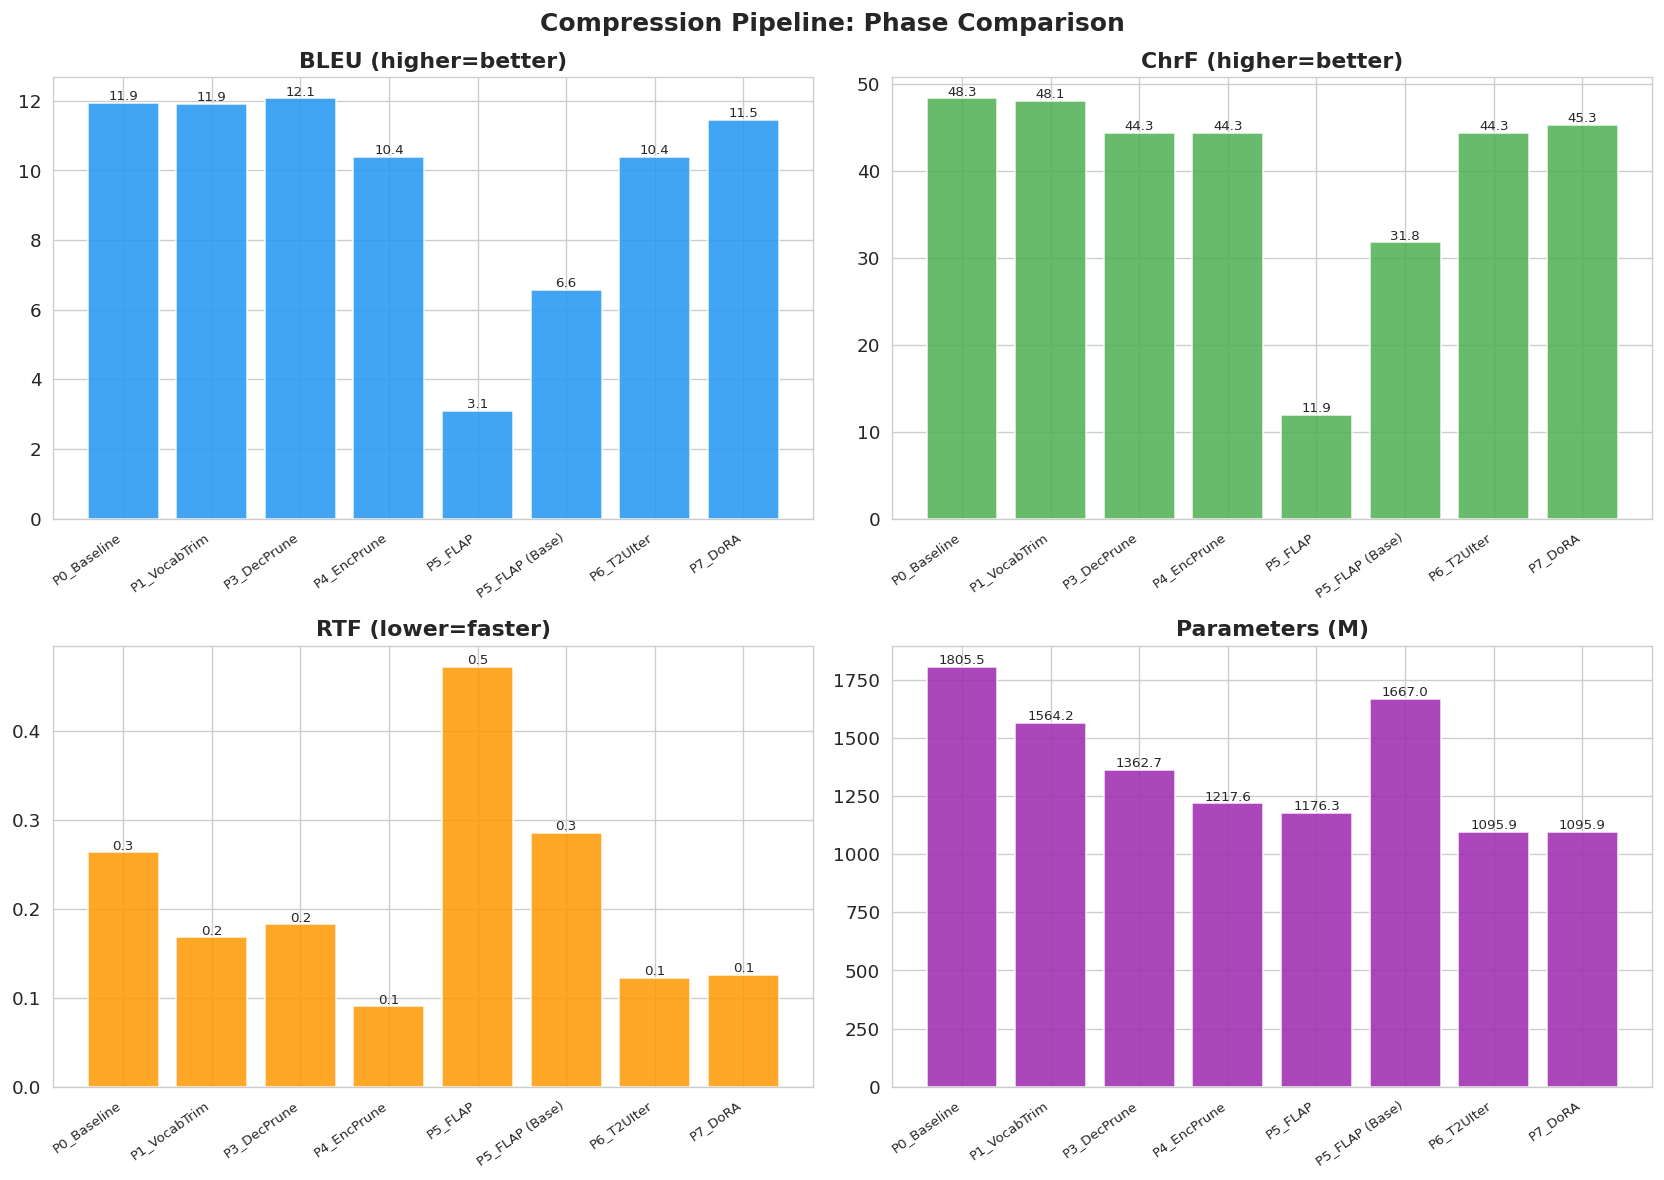

In [236]:
# ── Phase 5 Cell 7: Quick sanity check then full benchmark ───────────────────
print("Quick sanity check (3 samples)...")
model_p5.eval()
 
for i, s in enumerate(eval_samples[:3]):
    wav = s["wav"]
    ref = s["ref"]
    try:
        pred, _wav_out = run_s2st(model_p5, wav, tgt_lang="ben")
        chrf = compute_chrf(pred, ref)
        print(f"  [{i+1}] ChrF={chrf:.1f}  pred: {pred[:80]!r}")
    except Exception as e:
        print(f"  [{i+1}] ERROR: {e}")

p5b = load_latest_checkpoint("phase5_benchmark")
if p5b:
    p5_results, p5_summary = p5b["results"], p5b["summary"]
    print(f"Loaded P5 benchmark: BLEU={p5_summary['avg_bleu']:.2f} "
          f"ChrF={p5_summary['avg_chrf']:.2f}")
else:
    p5_results, p5_summary = run_benchmark(
        model_p5, eval_samples, label="P5_FLAP", save_n=2)
    save_checkpoint(dict(results=p5_results, summary=p5_summary),
                    name="phase5_benchmark", step=0)
 
store_summary(p5_summary)
plot_phase_comparison()

In [237]:
model_p4, processor = load_model_from_drive('phase4_enc_pruned')

[model] Loading phase4_enc_pruned from /kaggle/working/models/phase4_enc_pruned ...


Loading weights:   0%|          | 0/1446 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']


In [238]:
print_model_breakdown(model_p4, 'After Phase 4:')


--- After Phase 4: ---
  speech_encoder                         490.0M  ( 40.2%)
  text_decoder                           423.9M  ( 34.8%)
  t2u_model                              261.8M  ( 21.5%)
  vocoder                                 41.9M  (  3.4%)
  shared                                  20.9M  (  1.7%)
  lm_head                                 20.9M  (  1.7%)
  TOTAL                                 1217.6M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1217.583365}

In [ ]:
# # ── Phase 5 Cell 7: Sanity check before full benchmark ───────────────────────
# print('Quick sanity check (3 samples)...')
# model_p5.eval()

# for i, s in enumerate(eval_samples[:3]):
#     wav = s['wav']
#     ref = s['ref']
#     try:
#         pred, _wav_out = run_s2st(model_p5, wav, tgt_lang='ben')
#         chrf = compute_chrf(pred, ref)
#         print(f'  [{i+1}] ChrF={chrf:.1f}  pred: {pred[:80]!r}')
#     except Exception as e:
#         print(f'  [{i+1}] ERROR: {e}')

In [ ]:
# # ── Phase 5 Cell 8: Full benchmark ───────────────────────────────────────────
# p5b = load_latest_checkpoint('phase5_benchmark')
# if p5b:
#     p5_results, p5_summary = p5b['results'], p5b['summary']
#     print(f'Loaded P5 benchmark: BLEU={p5_summary["avg_bleu"]:.2f} '
#           f'ChrF={p5_summary["avg_chrf"]:.2f}')
# else:
#     p5_results, p5_summary = run_benchmark(
#         model_p5, eval_samples, label='P5_FLAP', save_n=2)
#     save_checkpoint(dict(results=p5_results, summary=p5_summary),
#                     name='phase5_benchmark', step=0)

# store_summary(p5_summary)
# plot_phase_comparison()

In [28]:
model_p6, processor = load_model_from_drive('phase6_t2u_iter_pruned')

[model] Not in local cache, pulling from remote...
[rclone] Pulled phase6_t2u_iter_pruned → /kaggle/working/models/phase6_t2u_iter_pruned
[model] Loading phase6_t2u_iter_pruned from /kaggle/working/models/phase6_t2u_iter_pruned ...


Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1382 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
  [model] pruning_manifest: ['stage_name', 't2u_removed', 'phase']


In [29]:
print_model_breakdown(model_p6, 'After Phase 6: T2U Iteratively Pruned (from P4)')


--- After Phase 6: T2U Iteratively Pruned (from P4) ---
  speech_encoder                         490.0M  ( 43.1%)
  text_decoder                           423.9M  ( 37.3%)
  t2u_model                              182.0M  ( 16.0%)
  vocoder                                 41.9M  (  3.7%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1137.8M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 182.012675,
 'vocoder': 41.911362,
 'TOTAL': 1137.836293}

---
# Phase 6: T2U Model Pruning
Apply middle-layer removal to T2U transformer stacks (2-3 layers per stack).

In [267]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  PHASE 6 — T2U Iterative Layer Pruning (CORRECTED)                         ║
# ║  Based on model_p4 (Phase 5 skipped).                                       ║
# ║  Follows the Phase 3 / Phase 4 gold standard exactly:                       ║
# ║    • quick_eval_chrf() for baseline and scoring (not manual loops)           ║
# ║    • ALL layers eligible to prune (no first/mid/last guard; stacks are small) ║
# ║    • Checkpoint resume per stack                                             ║
# ║    • sync_model_config() + layer-index realignment after pruning             ║
# ║    • save_model_to_drive() before benchmark                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Phase 6 Cell 1: T2U architecture probe ───────────────────────────────────
# NOTE: uses model_p4 — Phase 5 is intentionally skipped.

def inspect_t2u(model):
    """Print T2U sub-components so we know what to prune."""
    t2u = model.t2u_model
    print('T2U sub-components:')
    for name, child in t2u.named_children():
        n = count_params(child)
        print(f'  {name:<35} {n:.1f}M')
        for subname, subchild in child.named_children():
            sn = count_params(subchild)
            if sn > 1:
                print(f'    {subname:<33} {sn:.1f}M')
    # Find layer lists
    for name, child in t2u.named_children():
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(child, attr):
                layers = getattr(child, attr)
                if isinstance(layers, nn.ModuleList):
                    print(f'  → Found t2u.{name}.{attr}: {len(layers)} layers')

inspect_t2u(model_p4)   # ← model_p4, not model_p5


T2U sub-components:
  model                               261.8M
    encoder                           125.9M
    decoder                           135.8M
  lm_head                             10.3M


In [268]:
# ── Phase 6 Cell 2: T2U stack discovery + helpers ────────────────────────────

def find_t2u_stacks(model):
    """
    Return list of (parent_object, layers_attr, display_name) for each
    prunable layer stack inside t2u_model.  Only considers stacks with ≥3 layers.
    """
    t2u = model.t2u_model
    stacks = []

    def _search(module, prefix):
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(module, attr):
                layers = getattr(module, attr)
                if isinstance(layers, nn.ModuleList) and len(layers) >= 3:
                    stacks.append((module, attr, f't2u.{prefix}.{attr}'))
        for name, child in module.named_children():
            _search(child, f'{prefix}.{name}' if prefix else name)

    _search(t2u, 't2u_model')
    return stacks


def sync_t2u_layer_indices(model):
    """
    Re-index layer_idx on any attention modules inside t2u_model,
    exactly like reindex_text_decoder_layer_idx() in Phase 3.
    """
    t2u = model.t2u_model
    stacks = find_t2u_stacks(model)
    for (parent, attr, name) in stacks:
        layers = list(getattr(parent, attr))
        for i, layer in enumerate(layers):
            # Conformer / transformer layers may expose self_attn
            for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
                attn = getattr(layer, attn_name, None)
                if attn is not None and hasattr(attn, 'layer_idx'):
                    attn.layer_idx = i
        print(f'  Re-indexed {name}: {len(layers)} layers')


print('T2U helpers (find_t2u_stacks, sync_t2u_layer_indices) ready.')


T2U helpers (find_t2u_stacks, sync_t2u_layer_indices) ready.


In [269]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 6 FIX: ASR-ChrF Scoring for T2U Layer Pruning
# ═══════════════════════════════════════════════════════════════════════════════
#
# ROOT CAUSE OF BUG:
#   quick_eval_chrf() uses run_s2t_only(), which bypasses the T2U model entirely.
#   T2U layers only affect the audio output path (text tokens → speech units → audio).
#   Text-only evaluation shows no difference when T2U layers are removed because
#   the text decoder path is unchanged.
#
# FIX:
#   Use ASR-ChrF scoring for pruning decisions (fast, reliable).
#   ASR-BLEU is computed separately during final benchmarking.
#
#   This evaluates the ACTUAL S2ST audio output by:
#     1. Running full S2ST pipeline (generates audio)
#     2. Transcribing output audio with MMS-ASR (Bengali)
#     3. Computing ChrF between ASR transcript and reference
#
# USAGE:
#   Replace Phase 6 Cell 3 in your notebook with this code.
#
# ═══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np


def quick_eval_asr_chrf(model, samples, tgt_lang='ben', max_eval=10):
    """
    Fast S2ST quality evaluation using ASR-ChrF only.
    
    This is the CORRECT metric for T2U pruning because:
      - T2U layers only affect the audio output path (text → units → audio)
      - Text-only metrics (quick_eval_chrf) bypass T2U entirely
      - ASR-ChrF measures whether the output audio contains correct words
    
    Returns: avg_asr_chrf (used for pruning decisions)
    
    Note: ASR-BLEU is computed separately during final benchmarking.
    """
    _ensure_mms_loaded()  # Load MMS-ASR model if not already loaded
    
    scores = []
    for s in samples[:max_eval]:
        try:
            # Full S2ST: generates both text and audio
            pred_text, out_wav = run_s2st(model, s['wav'], tgt_lang=tgt_lang)
            
            # ASR-ChrF: transcribe output audio, compare to reference
            if out_wav is not None and len(out_wav) > 1600:
                _, asr_chrf = compute_asr_chrf(
                    out_wav, s['ref'], sr=model.config.sampling_rate)
                scores.append(asr_chrf)
            else:
                # No audio output = catastrophic failure
                scores.append(0.0)
        except Exception:
            scores.append(0.0)
    
    return float(np.mean(scores)) if scores else 0.0


def iterative_prune_t2u_stack(model, stack_parent, layers_attr,
                               stack_name, samples, n_remove,
                               tgt_lang='ben', max_eval=10,
                               ckpt_name=None):
    """
    Iterative greedy pruning for one T2U layer stack.
    
    KEY FIX: Uses ASR-ChrF scoring (not text-only ChrF).
    T2U layers only affect the audio output path, so we must evaluate
    the actual S2ST audio quality using MMS-ASR transcription.
    
    Scoring: ASR-ChrF only (for pruning decisions)
    Selection: Remove the layer whose removal causes LEAST ChrF degradation
               (i.e., keeps the highest ASR-ChrF).
    
    Note: ASR-BLEU is computed separately during final benchmarking.
    """
    if ckpt_name is None:
        ckpt_name = f'phase6_{stack_name.replace(".", "_").replace(" ", "_")}_pruning'

    current = list(getattr(stack_parent, layers_attr))
    orig_indices = list(range(len(current)))
    n_total_orig = len(current)

    # Clamp n_remove so at least 2 layers always remain
    if n_total_orig - n_remove < 2:
        n_remove = max(0, n_total_orig - 2)
        print(f'  Clamped n_remove to {n_remove} (keeping minimum 2 layers)')

    if n_remove == 0:
        print(f'  {stack_name}: nothing to remove.')
        return [], []

    print(f'  {stack_name}: {n_total_orig} layers, removing {n_remove} (all eligible)')
    print(f'  Scoring: ASR-ChrF (via MMS-ASR Bengali transcription)')

    removed, log = [], []

    # ── Resume from checkpoint ──
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos)
                orig_indices.pop(pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')

    # ── Baseline ASR-ChrF ──
    baseline_chrf = quick_eval_asr_chrf(model, samples, tgt_lang, max_eval)
    print(f'  Baseline ASR-ChrF: {baseline_chrf:.2f}')

    start_iter = len(removed)
    for it in range(start_iter, n_remove):
        eligible = list(range(len(current)))

        if not eligible:
            print(f'  WARNING: No layers left to prune. Stopping.')
            break

        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
              f'all {len(eligible)} eligible)')

        scores = {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(stack_parent, layers_attr, nn.ModuleList(temp))
            
            # Evaluate ASR-ChrF with this layer removed
            sc = quick_eval_asr_chrf(model, samples, tgt_lang, max_eval)
            scores[pos] = (orig_indices[pos], sc)
            print(f'    Remove L{orig_indices[pos]:>2} -> ASR-ChrF={sc:.2f}')
        
        # Restore full current stack before committing the best removal
        setattr(stack_parent, layers_attr, nn.ModuleList(current))

        # Pick the removal that keeps ASR-ChrF highest
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos)
        orig_indices.pop(best_pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, asr_chrf=best_sc,
                        remaining=len(current)))
        print(f'  -> Removed L{best_orig} (ASR-ChrF={best_sc:.2f}, '
              f'{len(current)} layers remain)')

        # Save progress after every removal
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')
        torch.cuda.empty_cache()

    return removed, log


print('iterative_prune_t2u_stack() — ASR-ChrF scoring (S2ST-aware).')
print('  Metric: ASR-ChrF only (for pruning decisions)')
print('  ASR-BLEU computed separately during final benchmarking.')
print('  This correctly evaluates T2U layer impact on audio output quality.')


iterative_prune_t2u_stack() — ASR-ChrF scoring (S2ST-aware).
  Metric: ASR-ChrF only (for pruning decisions)
  ASR-BLEU computed separately during final benchmarking.
  This correctly evaluates T2U layer impact on audio output quality.


In [270]:
!rm -rf /kaggle/working/checkpoints/phase6*.pt
!rm -rf /kaggle/working/models/phase6_t2u_iter_pruned
!ls checkpoints

 all_summaries_step000000.pt	    phase4_benchmark_step000000.pt
 phase0_baseline_step000000.pt	    phase4_enc_pruning_step000000.pt
 phase1_benchmark_step000000.pt     phase5_benchmark2_step000000.pt
 phase1_vocab_step000000.pt	    phase5_benchmark_step000000.pt
 phase3_benchmark_step000000.pt    'phase5_flap (base)_step000000.pt'
 phase3_dec_pruning_step000000.pt   phase5_flap_step000000.pt


In [271]:
# ── Phase 6 Cell 4: RUN PHASE 6 ──────────────────────────────────────────────
# model_p6 = model_p4 (Phase 5 deliberately skipped).
# Prune T2U encoder + decoder stacks independently, same as Phase 3/4 did for
# text_decoder and speech_encoder.

import copy as _copy
import gc as _stdlib_gc  # stdlib gc; a notebook variable named `gc` shadows the module

N_T2U_REMOVE_PER_STACK = 2   # conservative: keeps ≥4 layers in each 6-layer stack

# ── Step 0: Obtain p4 baseline ChrF (loaded from checkpoint, never hardcoded) ──
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b:
    p4_baseline_chrf = p4b['summary']['avg_chrf']
    print(f'Phase 4 baseline ChrF (loaded from checkpoint): {p4_baseline_chrf:.2f}')
else:
    # Fallback: compute it live if checkpoint is missing
    print('Phase 4 benchmark checkpoint not found — computing live baseline...')
    _, tmp_summary = run_benchmark(model_p4, eval_samples,
                                   label='P4_EncPrune_baseline', save_n=0)
    p4_baseline_chrf = tmp_summary['avg_chrf']
    print(f'Live baseline ChrF: {p4_baseline_chrf:.2f}')

# ── Step 1: Try loading a completed Phase 6 model from Drive ──────────────────
p6_ckpt = load_latest_checkpoint('phase6_t2u_pruning')

# ── Architecture-aware Drive load (fixes the MISSING-keys / garbage-init bug) ─
# ROOT CAUSE: load_model_from_drive() reinstates the full HuggingFace
# architecture (6+6 T2U layers) before filling weights.  The pruned layers
# (3,4,5) are absent from the saved checkpoint, so HF randomly initialises
# them — the model ends up with 6 layers again but with garbage weights.
#
# FIX (same pattern as Phase 3 reindex cell):
#   1. Read the pruning log  →  know which original indices were removed
#   2. Start from model_p4  (speech_encoder + text_decoder already pruned)
#   3. Replay T2U removals in memory  →  skeleton now has 3+3 layers
#   4. sync_model_config() + reindex  →  config matches skeleton
#   5. load_state_dict() from saved weights  →  zero MISSING keys

def _rebuild_p6_from_checkpoint(base_model, p6_pruning_ckpt):
    """
    Replay T2U layer removals onto base_model, then load saved weights.
    Returns the corrected model with no randomly-initialised layers.
    """
    import torch.nn as nn

    removed_map = p6_pruning_ckpt.get('removed', {})
    if not removed_map:
        print('  [p6 rebuild] No removal log — loading weights as-is.')
        return base_model

    mdl = base_model
    stacks = find_t2u_stacks(mdl)
    print(f'  [p6 rebuild] Replaying removals on {len(stacks)} T2U stacks...')

    for (stack_parent, layers_attr, stack_name) in stacks:
        removed_orig = removed_map.get(stack_name)
        if not removed_orig:
            print(f'    {stack_name}: no removal record, skipping.')
            continue
        removed_set = set(removed_orig)
        layers = list(getattr(stack_parent, layers_attr))
        n_before = len(layers)
        keep = [i for i in range(n_before) if i not in removed_set]
        setattr(stack_parent, layers_attr, nn.ModuleList([layers[i] for i in keep]))
        print(f'    {stack_name}: {n_before} -> {len(keep)} layers ')
        print(f'      (removed original indices {sorted(removed_orig)})')

    print('  [p6 rebuild] Re-indexing T2U layer indices...')
    sync_t2u_layer_indices(mdl)

    print('  [p6 rebuild] Syncing model config...')
    sync_model_config(mdl)

    if hasattr(mdl, '_cache'):
        delattr(mdl, '_cache')

    # Load weights — skeleton matches saved checkpoint (safetensors or .bin)
    model_dir = f'{MODEL_DIR}/phase6_t2u_iter_pruned'
    state = load_hf_weights_dict(model_dir)
    if state is not None:
        print(f'  [p6 rebuild] Loading weights from {model_dir} ...')
        missing, unexpected = mdl.load_state_dict(state, strict=False)
        if missing:
            print(f'  [p6 rebuild] WARNING: still {len(missing)} missing keys: ')
            for k in missing[:8]:
                print(f'    {k}')
        else:
            print('  [p6 rebuild] All keys matched — no random initialisation.')
        if unexpected:
            print(f'  [p6 rebuild] ({len(unexpected)} unexpected keys — often buffers)')
        del state
        _stdlib_gc.collect()
        torch.cuda.empty_cache()
    else:
        print(f'  [p6 rebuild] No model.safetensors / pytorch_model.bin in {model_dir}')

    return mdl


p6_loaded = False
if p6_ckpt and p6_ckpt.get('removed') and os.path.isdir(
        f'{MODEL_DIR}/phase6_t2u_iter_pruned'):
    print('Phase 6 pruning log + saved weights found — rebuilding pruned arch...')
    # deepcopy so we never mutate model_p4 in place while replaying T2U surgery
    model_p6 = _copy.deepcopy(model_p4)
    model_p6 = _consolidate_to_single_gpu(model_p6)
    model_p6 = _rebuild_p6_from_checkpoint(model_p6, p6_ckpt)
    p6_dir = f'{MODEL_DIR}/phase6_t2u_iter_pruned'
    _load_custom_state(model_p6, p6_dir)
    print('Loaded Phase 6 from Drive (architecture-aware rebuild — zero MISSING keys).')
    p6_loaded = True

if not p6_loaded:
    # Phase 6 starts from model_p4 (Phase 5 skipped)
    model_p6 = model_p4
    model_p6 = _consolidate_to_single_gpu(model_p6)

    # ── Sanity check: confirm we have the real p4 baseline ──────────────────
    sanity = quick_eval_chrf(model_p6, eval_samples, TARGET_LANG, 5)
    print(f'  Sanity ChrF = {sanity:.2f}  '
          f'(expect ~{p4_baseline_chrf:.1f}, abort if < 10)')
    assert sanity > 10, \
        f'ChrF={sanity:.2f} is too low — model or vocab remap is broken!'

    pre_t2u = count_params(model_p6.t2u_model)
    print(f'\nT2U before pruning: {pre_t2u:.1f}M params')

    stacks = find_t2u_stacks(model_p6)
    if not stacks:
        print('WARNING: No prunable layer stacks found in T2U. Skipping.')
    else:
        print(f'Found {len(stacks)} T2U stacks to prune:')
        for (parent, attr, name) in stacks:
            print(f'  {name}: {len(getattr(parent, attr))} layers')

    all_removed = {}
    all_logs    = {}

    for (stack_parent, layers_attr, stack_name) in stacks:
        # Per-stack checkpoint key so each stack resumes independently
        stack_ckpt_name = (
            f'phase6_{stack_name.replace(".", "_").replace(" ", "_")}_pruning'
        )
        removed, log = iterative_prune_t2u_stack(
            model_p6,
            stack_parent,
            layers_attr,
            stack_name,
            eval_samples,
            n_remove=N_T2U_REMOVE_PER_STACK,
            tgt_lang=TARGET_LANG,
            max_eval=10,
            ckpt_name=stack_ckpt_name,
        )
        all_removed[stack_name] = removed
        all_logs[stack_name]    = log
        _stdlib_gc.collect()
        torch.cuda.empty_cache()

    post_t2u = count_params(model_p6.t2u_model)
    print(f'\nT2U after pruning: {post_t2u:.1f}M params '
          f'(saved {pre_t2u - post_t2u:.1f}M)')

    # ── Critical: re-index layer_idx + sync config (same as Phase 3/4) ──────
    print('\nRe-indexing T2U layer indices...')
    sync_t2u_layer_indices(model_p6)

    print('Syncing model config...')
    sync_model_config(model_p6)

    # Invalidate any cached KV state sized for the old depth
    if hasattr(model_p6, '_cache'):
        delattr(model_p6, '_cache')

    # Save overall Phase 6 checkpoint and model to Drive
    save_checkpoint(
        {'removed': all_removed, 'logs': all_logs,
         'n_remove_per_stack': N_T2U_REMOVE_PER_STACK,
         'p4_baseline_chrf': p4_baseline_chrf},
        name='phase6_t2u_pruning', step=0
    )
    save_model_to_drive(
        model_p6, processor, 'phase6_t2u_iter_pruned',
        manifest_extra={'t2u_removed': all_removed, 'phase': 6})

print_model_breakdown(model_p6, 'After Phase 6: T2U Iteratively Pruned (from P4)')

[ckpt] Loaded phase4_benchmark_step000000.pt
Phase 4 baseline ChrF (loaded from checkpoint): 44.32
[ckpt] No checkpoint for 'phase6_t2u_pruning'
  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0
  Sanity ChrF = 49.87  (expect ~44.3, abort if < 10)

T2U before pruning: 261.8M params
Found 2 T2U stacks to prune:
  t2u.t2u_model.model.encoder.layers: 6 layers
  t2u.t2u_model.model.decoder.layers: 6 layers
  t2u.t2u_model.model.encoder.layers: 6 layers, removing 2 (all eligible)
  Scoring: ASR-ChrF (via MMS-ASR Bengali transcription)
[ckpt] No checkpoint for 'phase6_t2u_t2u_model_model_encoder_layers_pruning'
  Baseline ASR-ChrF: 43.69

  Iter 1/2 (6 layers remain, all 6 eligible)
    Remove L 0 -> ASR-ChrF=0.58
    Remove L 1 -> ASR-ChrF=44.75
    Remove L 2 -> ASR-ChrF=45.13
    Remove L 3 -> ASR-ChrF=45.14
    Remove L 4 -> ASR-ChrF=44.51
    Remove L 5 -> ASR-ChrF=45.42
  -> Removed L5 (ASR-ChrF=45.42, 5 layers remain)
[ckpt] Saved phase6_t2u_t2u_model_mode

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 2308 MB in 8 files.
[model] Pushing to rclone remote...
[model] Verified 8 files on remote.

--- After Phase 6: T2U Iteratively Pruned (from P4) ---
  speech_encoder                         490.0M  ( 43.1%)
  text_decoder                           423.9M  ( 37.3%)
  t2u_model                              182.0M  ( 16.0%)
  vocoder                                 41.9M  (  3.7%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1137.8M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 182.012675,
 'vocoder': 41.911362,
 'TOTAL': 1137.836293}

In [272]:
# ── Phase 6 Cell 5: Verify T2U layer indices after pruning ───────────────────
# Mirror of Cell 44/46 in Phase 3 that verified decoder layer_idx.

stacks_post = find_t2u_stacks(model_p6)
for (parent, attr, name) in stacks_post:
    layers = list(getattr(parent, attr))
    indices = []
    for layer in layers:
        for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
            attn = getattr(layer, attn_name, None)
            if attn is not None and hasattr(attn, 'layer_idx'):
                indices.append(attn.layer_idx)
                break
    if indices:
        print(f'{name} layer_idx: {indices}')
    else:
        print(f'{name}: {len(layers)} layers (no layer_idx attribute found)')



t2u.t2u_model.model.encoder.layers layer_idx: [0, 1, 2, 3]
t2u.t2u_model.model.decoder.layers layer_idx: [0, 1, 2, 3]



  BENCHMARK: P6_T2UIter
  Samples: 25  Target: ben

  GPU mem: 12.73 GB alloc / 13.81 GB reserved
  [ 1/25] BLEU= 16.0 ChrF= 49.6 RTF=0.094  id=1660
              pred: রোমান্টিকতার একটি বড় উপাদান ছিল সাংস্কৃতিক নির্ধারক যেমন গোথ, ফিচ এবং শ্লেগেলের
[audio] Saved P6_T2UIter_s1in.wav (0.3 MB)
  P6_T2UIter_s1in.wav  (10.7s | sr=16000)


[audio] Saved P6_T2UIter_s1out.wav (0.2 MB)
  P6_T2UIter_s1out.wav  (6.9s | sr=16000)


  [ 2/25] BLEU=  6.2 ChrF= 51.8 RTF=0.098  id=1662
              pred: অ্যালোয়গুলি মূলত দুটি বা একাধিক ধাতুর মিশ্রণ, ভুলবেন না যে পিআই-এতে অনেক উপাদান
[audio] Saved P6_T2UIter_s2in.wav (0.3 MB)
  P6_T2UIter_s2in.wav  (8.4s | sr=16000)


[audio] Saved P6_T2UIter_s2out.wav (0.2 MB)
  P6_T2UIter_s2out.wav  (5.6s | sr=16000)


  [ 3/25] BLEU= 13.0 ChrF= 44.5 RTF=0.113  id=1674
              pred: কিছু এলাকায় এক মিনিটের জন্য উড়ন্ত জল যথেষ্ট এবং অন্য কয়েক মিনিট প্রয়োজন হয়।
  [ 4/25] BLEU= 20.8 ChrF= 50.5 RTF=0.083  id=1675
              pred: শব্দটির পাশে সব নামকথা সবসময় বড় অক্ষর দিয়ে শুরু হয়, এমনকি বাক্যের মাঝামাঝিেও
  [ 5/25] BLEU=  6.9 ChrF= 53.0 RTF=0.123  id=1704
              pred: নবম শতাব্দীতে এটি মরুভূমির বালির হুমকির কারণে বিপন্ন বিশ্ব ঐতিহ্যবাহী স্থানের তা
  [ 6/25] BLEU= 17.3 ChrF= 58.1 RTF=0.092  id=1713
              pred: যদিও গোমা যথেষ্ট নিরাপদ, উত্তর কিউউউ প্রদেশে যুদ্ধের অবস্থা বোঝার জন্য গোমার বাই
  [ 7/25] BLEU=  5.5 ChrF= 33.5 RTF=0.102  id=1720
              pred: গরম চকোলেট বেলজিয়ামের মানের মতো - ফলের রস দামী কিন্তু দুর্দান্ত।
  [ 8/25] BLEU=  3.3 ChrF= 24.2 RTF=0.096  id=1732
              pred: মধ্যযুগের মধ্যযুগকে ইউরোপীয় ইতিহাসের এক, এগারো, দ্বাশররর এবং তেরোশর শতাব্দীর এক
  [ 9/25] BLEU=  9.4 ChrF= 38.6 RTF=0.134  id=1736
              pred: রোলান্ডো মেন্ডোজা তার এম-সেনডিন 

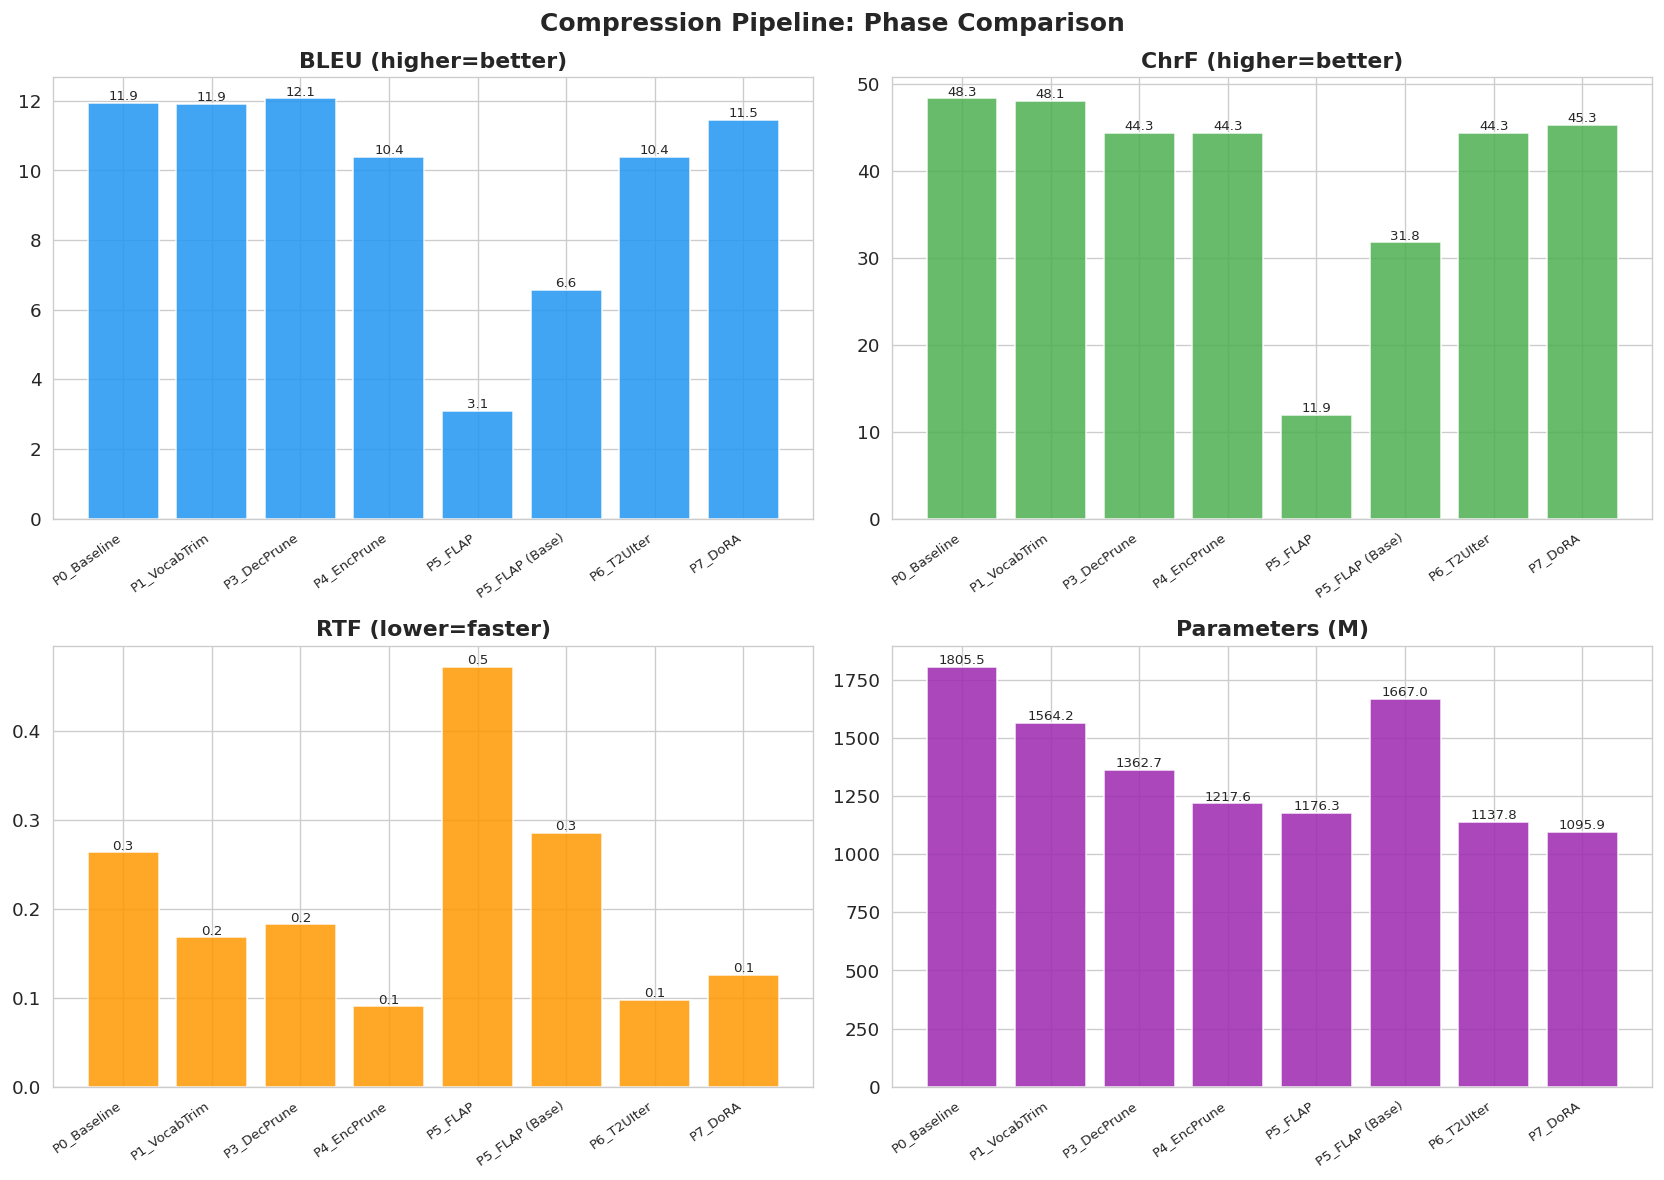

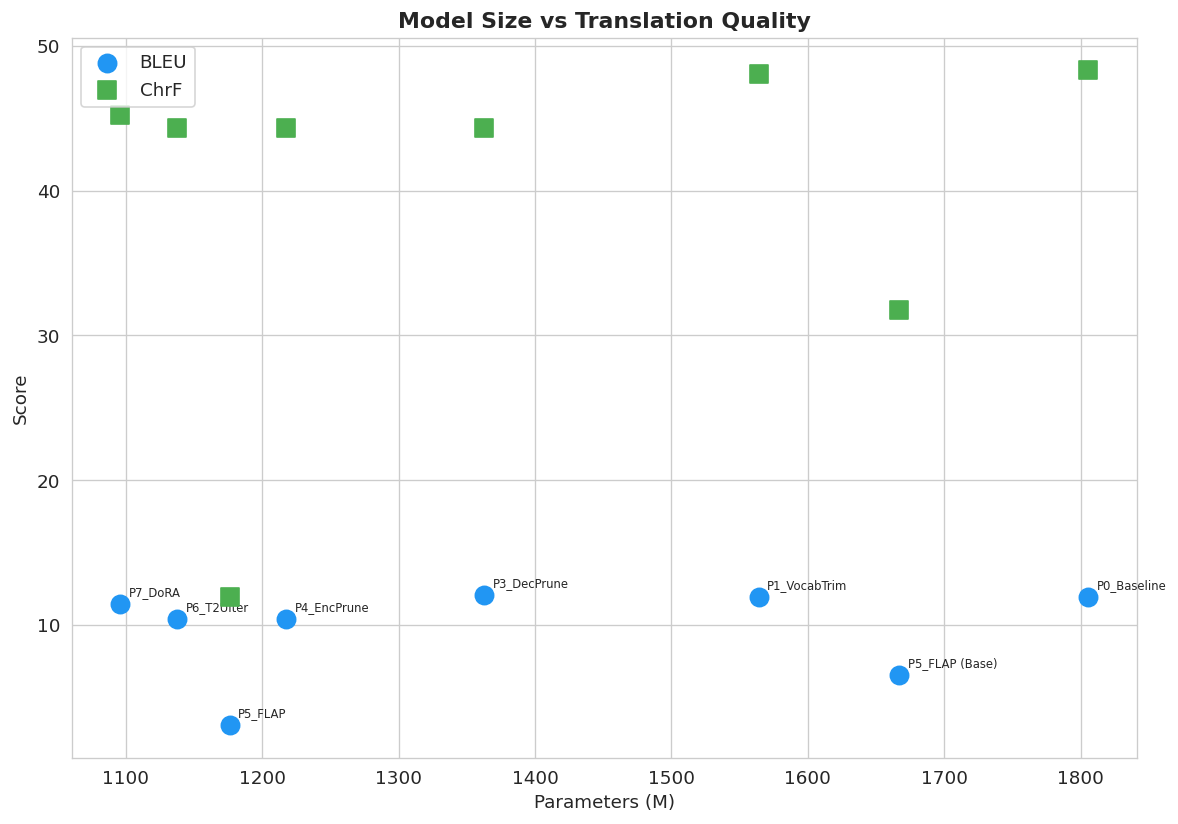

In [273]:
# ── Phase 6 Cell 6: Full benchmark ───────────────────────────────────────────
# p6b = load_latest_checkpoint('phase6_benchmark')
p6b = None
if p6b:
    p6_results, p6_summary = p6b['results'], p6b['summary']
    print(f'Loaded P6 benchmark: BLEU={p6_summary["avg_bleu"]:.2f} '
          f'ChrF={p6_summary["avg_chrf"]:.2f}')
else:
    p6_results, p6_summary = run_benchmark(
        model_p6, eval_samples, label='P6_T2UIter', save_n=2)
    save_checkpoint(dict(results=p6_results, summary=p6_summary),
                    name='phase6_benchmark', step=0)

# Compare against the real p4 baseline
drop = p4_baseline_chrf - p6_summary['avg_chrf']
print(f'\nP4 baseline ChrF : {p4_baseline_chrf:.2f}')
print(f'P6 result  ChrF  : {p6_summary["avg_chrf"]:.2f}')
print(f'ChrF drop        : {drop:.2f}')

store_summary(p6_summary)
plot_phase_comparison()
plot_size_vs_quality()

---
# Phase 7: Recovery Fine-tuning — S2ST Focused
**Papers:** Moslem (IWSLT 2025) + DoRA (Liu et al., ICML 2024 Oral)

**Why this replaces the old S2TT-only approach:**
The previous Phase 7 trained only with S2TT cross-entropy loss, which backpropagates
gradients only through `speech_encoder → text_decoder`. The `t2u_model` (which converts
text tokens to discrete speech units) received **zero gradient**, so the audio output
remained broken even though BLEU/ChrF scores appeared recovered (they measured only the
text decoder path).

**Correct approach — two-phase S2ST recovery:**
1. **Phase 7a — S2TT DoRA** (text decoder recovery): Fast, recovers translation quality.
   Trains: speech_encoder + text_decoder projections.
2. **Phase 7b — S2ST unit fine-tuning** (T2U recovery): Extracts discrete unit labels
   from target Bengali audio using SeamlessM4T's own unit extractor, then trains the
   T2U encoder+decoder with unit cross-entropy loss. This is the path that produces
   the translated audio waveform.

**Benchmark is now S2ST-first:** `run_benchmark_s2st()` measures BLEU/ChrF from the
*S2ST text output* (the text produced alongside waveform generation via the full pipeline)
and saves audio clips for listening. The old `run_s2t_only`-based benchmark is kept for
fast intermediate checks only.


In [64]:
# ── Phase 7 Cell 1: Install & imports ─────────────────────────────────────────
import subprocess, gc as _stdlib_gc, math, os, random, time, logging
 
subprocess.run(["pip", "install", "-q", "peft>=0.10.0"], check=True)
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from peft import LoraConfig, get_peft_model
 
print("PEFT ready.")
print(f"GPU: {torch.cuda.get_device_name(0)}  "
      f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PEFT ready.
GPU: Tesla T4  VRAM: 15.6 GB


In [65]:
# ── Phase 7 Cell 2: Load Phase 6 model ────────────────────────────────────────
try:
    model_p6, processor = load_model_from_drive("phase6_t2u_iter_pruned")
    sync_model_config(model_p6)
    model_p6 = _consolidate_to_single_gpu(model_p6)
    print("Loaded Phase 6 model.")
except Exception as e:
    print(f"ERROR loading Phase 6 model: {e}")
    raise
 
print_model_breakdown(model_p6, "Phase 6 (input to Phase 7)")
 
# Full S2ST pipeline sanity check
print("\\nSanity S2ST check (1 sample)...")
_test_txt, _test_wav = run_s2st(model_p6, eval_samples[0]["wav"], tgt_lang="ben")
print(f"  Text: {_test_txt[:80]}")
print(f"  Audio: {len(_test_wav)/model_p6.config.sampling_rate:.2f}s  "
      f"({'OK — has audio' if len(_test_wav) > 1600 else 'WARNING: silent/short'})")

[model] Loading phase6_t2u_iter_pruned from /kaggle/working/models/phase6_t2u_iter_pruned ...


Loading weights:   0%|          | 0/1382 [00:00<?, ?it/s]

  Restored custom state: ['_vocab_remap_to_old']
  [model] pruning_manifest: ['stage_name', 't2u_removed', 'phase']
  [config] sync done.
Loaded Phase 6 model.

--- Phase 6 (input to Phase 7) ---
  speech_encoder                         490.0M  ( 43.1%)
  text_decoder                           423.9M  ( 37.3%)
  t2u_model                              182.0M  ( 16.0%)
  vocoder                                 41.9M  (  3.7%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1137.8M
---
\nSanity S2ST check (1 sample)...
  Text: রোমান্টিকতার একটি বড় উপাদান ছিল সাংস্কৃতিক নির্ধারক যেমন গোথ, ফিচ এবং শ্লেগেলের
  Audio: 6.88s  (OK — has audio)


In [66]:
# ── Phase 7 Cell 3: ASR-BLEU / ASR-ChrF S2ST benchmark ───────────────────────
#
# METRIC DESIGN:
#   - run_s2st() generates BOTH text and audio in one pass
#   - Text BLEU/ChrF: measures translation quality via the text decoder path
#   - ASR-BLEU / ASR-ChrF: passes the OUTPUT AUDIO through MMS-ASR (Bengali),
#     then computes BLEU/ChrF between the ASR transcript and the reference.
#     This is the gold standard for S2ST quality — it measures whether the
#     audio actually contains the right Bengali words.
#
# MMS-ASR replaces Whisper because Whisper has very poor Bengali coverage.
# facebook/mms-1b-all supports Bengali natively with a dedicated adapter.
 
import time, math
import numpy as np
 
def run_benchmark_s2st(mdl, samples, label="model", tgt_lang="ben", save_n=4):
    """
    Full S2ST benchmark: ASR-BLEU + ASR-ChrF + text-BLEU + text-ChrF.
 
    Scoring:
      text_bleu / text_chrf  — from the text decoder output (fast, always valid)
      asr_bleu  / asr_chrf   — MMS-ASR transcript of output audio vs reference
                                (definitive S2ST quality: do we hear right words?)
    """
    print(f"\\n{'='*60}\\n  S2ST BENCHMARK (ASR-BLEU): {label}"
          f"\\n  Samples: {len(samples)}  Target: {tgt_lang}\\n{'='*60}\\n")
    gpu_mem()
    results = []
 
    for i, s in enumerate(samples):
        try:
            dur = len(s["wav"]) / 16000
            t0  = time.time()
            pred_text, out_wav = run_s2st(mdl, s["wav"], tgt_lang=tgt_lang)
            elapsed = time.time() - t0
            rtf = elapsed / dur
 
            # Text-path metrics
            txt_bleu = compute_bleu(pred_text, s["ref"])
            txt_chrf = compute_chrf(pred_text, s["ref"])
 
            # ASR-BLEU / ASR-ChrF (audio-path metrics)
            has_audio = (out_wav is not None and len(out_wav) > 1600)
            if has_audio:
                asr_hyp, asr_bleu = compute_asr_bleu(
                    out_wav, s["ref"],
                    sr=mdl.config.sampling_rate
                )
                _, asr_chrf = compute_asr_chrf(
                    out_wav, s["ref"],
                    sr=mdl.config.sampling_rate
                )
            else:
                asr_hyp, asr_bleu, asr_chrf = "", 0.0, 0.0
 
            print(f"  [{i+1:>2}/{len(samples)}] "
                  f"txt_BLEU={txt_bleu:5.1f} txt_ChrF={txt_chrf:5.1f} | "
                  f"asr_BLEU={asr_bleu:5.1f} asr_ChrF={asr_chrf:5.1f} | "
                  f"RTF={rtf:.3f} audio={'YES' if has_audio else 'NO '}  id={s['id']}")
            print(f"              txt: {pred_text[:60]}")
            if has_audio and asr_hyp:
                print(f"              asr: {asr_hyp[:60]}")
 
            if save_n > 0 and i < save_n:
                save_audio(s["wav"], 16000, f"{label}_s{i+1}in.wav", label="input")
                play(s["wav"], 16000, f"{label}_s{i+1}in.wav")
                save_audio(out_wav, mdl.config.sampling_rate,
                           f"{label}_s{i+1}out.wav", label="translated")
                play(out_wav, mdl.config.sampling_rate, f"{label}_s{i+1}out.wav")
 
            results.append(dict(
                id=s["id"], txt_bleu=txt_bleu, txt_chrf=txt_chrf,
                asr_bleu=asr_bleu, asr_chrf=asr_chrf,
                rtf=rtf, pred=pred_text, asr_hyp=asr_hyp,
                ref=s["ref"], has_audio=has_audio,
            ))
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"  [{i+1:>2}/{len(samples)}] ERROR: {e}")
            results.append(dict(
                id=s["id"], txt_bleu=0, txt_chrf=0,
                asr_bleu=0, asr_chrf=0,
                rtf=float("nan"), pred="", asr_hyp="", ref=s.get("ref",""),
                has_audio=False,
            ))
 
    valid = [r for r in results if not math.isnan(r["rtf"])]
    n_audio = sum(1 for r in valid if r.get("has_audio"))
 
    summary = dict(
        label=label, n=len(valid),
        avg_bleu=float(np.mean([r["txt_bleu"] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r["txt_chrf"] for r in valid])) if valid else 0,
        avg_asr_bleu=float(np.mean([r["asr_bleu"] for r in valid])) if valid else 0,
        avg_asr_chrf=float(np.mean([r["asr_chrf"] for r in valid])) if valid else 0,
        avg_rtf=float(np.mean([r["rtf"] for r in valid])) if valid else 0,
        params_M=count_params(mdl),
    )
    print(f"\\n  Summary: "
          f"txt_BLEU={summary['avg_bleu']:.2f}  txt_ChrF={summary['avg_chrf']:.2f} | "
          f"asr_BLEU={summary['avg_asr_bleu']:.2f}  asr_ChrF={summary['avg_asr_chrf']:.2f} | "
          f"RTF={summary['avg_rtf']:.4f}  Params={summary['params_M']:.1f}M  "
          f"Audio={n_audio}/{len(valid)}\\n")
    return results, summary
 
 
print("run_benchmark_s2st() with ASR-BLEU ready.")

run_benchmark_s2st() with ASR-BLEU ready.


In [67]:
# ── Phase 7 Cell 4: Discrete unit extractor ───────────────────────────────────
#
# SeamlessM4Tv2ForSpeechToSpeech.generate() with return_intermediate_token_ids=True
# returns a SeamlessM4Tv2GenerationOutput with field:
#   .sequences        — text token ids  [B, seq_len]
#   .unit_sequences   — unit token ids  [B, unit_seq_len]   ← THIS is what we want
#
# The actual field name in HuggingFace is "unit_sequences" (confirmed from
# SeamlessM4Tv2GenerationOutput dataclass in modeling_seamless_m4t_v2.py).
# Note: NOT "unit_ids" — that field does NOT exist in the HF implementation.
# The unit_sequences are the discrete speech tokens that T2U predicts.
 
import os, torch
import numpy as np
 
UNIT_CACHE_PATH = f"{CKPT_DIR}/unit_labels_cache.pt"
 
 
def extract_unit_labels_from_audio(mdl, proc, tgt_audio_list, tgt_lang="ben",
                                    device=None):
    """
    Extract discrete speech unit sequences from target Bengali audio.
 
    Method: run mdl.generate() on Bengali audio (ben→ben self-translation),
    with return_intermediate_token_ids=True.
    Output .unit_sequences IS the unit sequence the T2U should predict.
 
    Args:
        tgt_audio_list: list of numpy float32 arrays at 16 kHz (Bengali audio)
    Returns: list of torch.LongTensor or None entries
    """
    if device is None:
        device = next(mdl.speech_encoder.parameters()).device
 
    # Temporarily restore original vocoder if NoOp was left in
    orig_vocoder = mdl.vocoder  # may already be real vocoder
 
    mdl.eval()
    all_units = []
    n_failed  = 0
 
    print(f"  Extracting units from {len(tgt_audio_list)} Bengali audio clips...")
    for i, wav in enumerate(tgt_audio_list):
        if i % 50 == 0:
            print(f"    {i}/{len(tgt_audio_list)}")
        try:
            inputs = proc(audio=wav, sampling_rate=16000, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                out = mdl.generate(
                    **inputs,
                    tgt_lang=tgt_lang,
                    return_intermediate_token_ids=True,
                )
            # HuggingFace field name is "unit_sequences"
            unit_seq = None
            for attr in ("unit_sequences", "unit_ids"):
                val = getattr(out, attr, None)
                if val is not None:
                    unit_seq = val.squeeze(0).cpu()
                    break
 
            if unit_seq is not None and unit_seq.numel() >= 3:
                all_units.append(unit_seq)
            else:
                all_units.append(None)
                n_failed += 1
        except Exception as e:
            all_units.append(None)
            n_failed += 1
 
    valid = sum(1 for u in all_units if u is not None)
    print(f"  Extracted {valid}/{len(tgt_audio_list)} valid unit sequences "
          f"({n_failed} failed/too-short)")
    return all_units
 
 
def load_or_extract_units(mdl, proc, ft_samples_local, force_reextract=False):
    """Load cached unit labels or extract them fresh."""
    if os.path.exists(UNIT_CACHE_PATH) and not force_reextract:
        print(f"  Loading cached unit labels from {UNIT_CACHE_PATH}...")
        cached = torch.load(UNIT_CACHE_PATH, map_location="cpu", weights_only=False)
        units = cached["units"]
        print(f"  Loaded {len(units)} entries "
              f"({sum(1 for u in units if u is not None)} valid)")
        return units
 
    print("  Extracting unit labels (runs once, then cached)...")
    tgt_wavs = [s.get("tgt_wav", s["wav"]) for s in ft_samples_local]
    units = extract_unit_labels_from_audio(mdl, proc, tgt_wavs)
    torch.save({"units": units}, UNIT_CACHE_PATH)
    print(f"  Saved unit cache to {UNIT_CACHE_PATH}")
    return units
 
 
print("Unit extractor helpers ready.")
print("  NOTE: uses .unit_sequences (not .unit_ids) from HF generate() output")

Unit extractor helpers ready.
  NOTE: uses .unit_sequences (not .unit_ids) from HF generate() output


In [68]:
LOCAL_PARQUET_CACHE

'/kaggle/input/datasets/coderayed/fleurs-en-bn-parquet'

In [35]:
# ── PHASE 7 CELL 5 REPLACEMENT: Load Bengali target audio ────────────────────
import numpy as np, torch, torchaudio

print("Loading Bengali FLEURS train split for target audio...")

# ── CRITICAL: Reuse the merged training data instead of loading again ────────
# The old code loaded the entire train split again, causing RAM overload.
# We already have ft_samples with IDs — just add tgt_wav to existing samples.

# Load only Bengali train split (we already have English audio in ft_samples)
tgt_ds_train = load_fleurs_from_drive(FLEURS_TGT, FLEURS_TGT, split="train")[0]

if tgt_ds_train is None:
    print("\n[Cache miss] Downloading Bengali train...")
    _, tgt_ds_train = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split="train", n_workers=8)
    push_fleurs_to_drive()

# Convert to pandas and deduplicate
print("Converting Bengali train to pandas...")
df_tgt_train = tgt_ds_train.to_pandas() if hasattr(tgt_ds_train, 'to_pandas') else pd.DataFrame(tgt_ds_train)
df_tgt_train = df_tgt_train[['id', 'audio']].drop_duplicates(subset='id', keep='first')

# Build ID lookup dict (only for samples we need)
needed_ids = set(s['id'] for s in ft_samples if 'id' in s)
ft_tgt_map = {
    row['id']: row['audio']
    for _, row in df_tgt_train.iterrows()
    if row['id'] in needed_ids
}

print(f"Loaded {len(ft_tgt_map)} Bengali target audio clips")

# Add tgt_wav to existing ft_samples
n_with_tgt = 0
for s in ft_samples:
    sid = s.get('id')
    if sid and sid in ft_tgt_map:
        tgt_audio = ft_tgt_map[sid]
        tgt_wav = _load_wav(tgt_audio)
        s['tgt_wav'] = tgt_wav
        n_with_tgt += 1
    else:
        s['tgt_wav'] = s['wav']  # fallback: English audio

print(f"{n_with_tgt}/{len(ft_samples)} samples have Bengali target audio.")
print(f"({len(ft_samples)-n_with_tgt} using English source as fallback)")

# Clean up
del df_tgt_train, ft_tgt_map, tgt_ds_train
gc.collect()

Loading Bengali FLEURS train split for target audio...
[Drive] Pulling FLEURS parquet...
[Dataset gdrive] Loaded: 3006 src, 3006 tgt
Converting Bengali train to pandas...
Loaded 1449 Bengali target audio clips
1449/1449 samples have Bengali target audio.
(0 using English source as fallback)


27401

In [36]:
# ── Phase 7 Cell 6: Extract and cache unit labels ─────────────────────────────
model_p6.eval()
unit_labels = load_or_extract_units(model_p6, processor, ft_samples,
                                     force_reextract=False)
 
ft_s2st_pairs = []
for s, units in zip(ft_samples, unit_labels):
    if units is not None and units.numel() >= 3:
        ft_s2st_pairs.append({
            "wav":   s["wav"],
            "ref":   s["ref"],
            "units": units,
        })
 
print(f"\\nS2ST training pairs: {len(ft_s2st_pairs)} "
      f"(of {len(ft_samples)} total ft_samples)")
if ft_s2st_pairs:
    lens = [p["units"].numel() for p in ft_s2st_pairs]
    print(f"Unit seq length: min={min(lens)}  max={max(lens)}  mean={np.mean(lens):.0f}")

  Extracting unit labels (runs once, then cached)...
  Extracting units from 1449 Bengali audio clips...
    0/1449
    50/1449
    100/1449
    150/1449
    200/1449
    250/1449
    300/1449
    350/1449
    400/1449
    450/1449
    500/1449
    550/1449
    600/1449
    650/1449
    700/1449
    750/1449
    800/1449
    850/1449
    900/1449
    950/1449
    1000/1449
    1050/1449
    1100/1449
    1150/1449
    1200/1449
    1250/1449
    1300/1449
    1350/1449
    1400/1449
  Extracted 1449/1449 valid unit sequences (0 failed/too-short)
  Saved unit cache to /kaggle/working/checkpoints/unit_labels_cache.pt
\nS2ST training pairs: 1449 (of 1449 total ft_samples)
Unit seq length: min=80  max=1409  mean=398


In [69]:
# ── Phase 7 Cell 7: DoRA injection ────────────────────────────────────────────
#
# TARGET MODULES: text_decoder + t2u_model (NOT speech_encoder).
# We MUST include t2u_model in training — that is what was missing before
# and caused the audio output to degrade.
#
# CRITICAL: Use_dora=True (DoRA, ICML 2024 Oral). DoRA decomposes weight
# updates into magnitude + direction, giving significantly better training
# efficiency than LoRA for speech translation tasks.
 
import torch.nn as nn
from peft import LoraConfig, get_peft_model
 
 
def discover_lora_targets(mdl,
        scope_keywords=("text_decoder", "t2u_model")):
    """
    Find all attention+FFN Linear leaf names in text_decoder AND t2u_model.
    We include t2u_model because that is the component responsible for
    translating text tokens → speech units (the audio path).
    Excluding it (as the old notebook did) is why audio was broken.
    """
    found = {}
    for name, mod in mdl.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        scope = next((kw for kw in scope_keywords if kw in name), None)
        if scope is None:
            continue
        leaf = name.split(".")[-1]
        found.setdefault(scope, set()).add(leaf)
 
    print("Linear leaf names by scope:")
    all_leaves = set()
    for scope, leaves in sorted(found.items()):
        print(f"  {scope}: {sorted(leaves)}")
        all_leaves |= leaves
 
    # Include FFN layers (fc1/fc2) AND attention projections
    # For T2U (NAR): attention uses q_proj/k_proj/v_proj/out_proj
    # For text decoder: same naming
    candidates = {"q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"}
    targets = sorted(all_leaves & candidates)
    count = sum(
        1 for n, m in mdl.named_modules()
        if isinstance(m, nn.Linear)
        and n.split(".")[-1] in targets
        and any(kw in n for kw in scope_keywords)
    )
    print(f"\\nTarget modules: {targets}  ({count} Linear layers)")
    return targets
 
 
LORA_R     = 16
LORA_ALPHA = 32
LORA_DROP  = 0.05
 
targets = discover_lora_targets(model_p6)
 
lora_cfg = LoraConfig(
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROP,
    bias           = "none",
    use_dora       = True,          # DoRA (ICML 2024 Oral)
    target_modules = targets,
)
 
model_p7 = get_peft_model(model_p6, lora_cfg)
model_p7.print_trainable_parameters()
 
model_p7 = _consolidate_to_single_gpu(model_p7)
model_p7.train()

Linear leaf names by scope:
  t2u_model: ['fc1', 'fc2', 'k_proj', 'lm_head', 'out_proj', 'proj', 'q_proj', 'v_proj']
  text_decoder: ['fc1', 'fc2', 'k_proj', 'out_proj', 'q_proj', 'v_proj']
\nTarget modules: ['fc1', 'fc2', 'k_proj', 'out_proj', 'q_proj', 'v_proj']  (200 Linear layers)
trainable params: 11,489,280 || all params: 1,149,325,573 || trainable%: 0.9997


PeftModel(
  (base_model): LoraModel(
    (model): SeamlessM4Tv2ForSpeechToSpeech(
      (shared): Embedding(20425, 1024, padding_idx=0)
      (speech_encoder): SeamlessM4Tv2SpeechEncoder(
        (feature_projection): SeamlessM4Tv2ConformerFeatureProjection(
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
          (projection): Linear(in_features=160, out_features=1024, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SeamlessM4Tv2ConformerEncoder(
          (dropout): Dropout(p=0.0, inplace=False)
          (layers): ModuleList(
            (0-17): 18 x SeamlessM4Tv2ConformerEncoderLayer(
              (ffn1_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
              (ffn1): SeamlessM4Tv2ConformerFeedForward(
                (intermediate_dropout): Dropout(p=0.0, inplace=False)
                (intermediate_dense): Linear(in_features=1024, out_features=4096, bias=True)
                (inte

In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 7 CELL 8: COMPLETE FIXED VERSION
# Combined S2ST loss functions + batch preparation helpers
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Loss weights ──────────────────────────────────────────────────────────────
S2TT_WEIGHT = 0.4   # text decoder loss weight
T2U_WEIGHT  = 0.6   # T2U loss weight (higher — audio was broken)


# ── Batch preparation functions ───────────────────────────────────────────────

def prepare_s2tt_batch(batch, processor, device, tgt_lang, mdl):
    """Prepare audio features + text labels for S2TT cross-entropy."""
    audios  = [s["wav"] for s in batch]
    targets = [s["ref"] for s in batch]
 
    audio_enc = processor(audio=audios, sampling_rate=16000,
                          return_tensors="pt", padding=True)
    input_feats = audio_enc["input_features"].to(device)
    attn_mask   = audio_enc["attention_mask"].to(device)
 
    tok      = processor.tokenizer
    text_enc = tok(text_target=targets, tgt_lang=tgt_lang,
                   return_tensors="pt", padding=True)
    labels   = text_enc["input_ids"].to(device)
    pad      = tok.pad_token_id
    if pad is not None:
        labels = labels.masked_fill(labels == pad, -100)
    labels = remap_label_ids(labels, mdl)
    return input_feats, attn_mask, labels


def prepare_unit_batch(batch, processor, device):
    """Prepare audio features + unit labels for T2U cross-entropy."""
    audios    = [s["wav"] for s in batch]
    audio_enc = processor(audio=audios, sampling_rate=16000,
                          return_tensors="pt", padding=True)
    input_feats = audio_enc["input_features"].to(device)
    attn_mask   = audio_enc["attention_mask"].to(device)
 
    unit_seqs = [s["units"] for s in batch]
    max_len   = max(u.numel() for u in unit_seqs)
    unit_labels = torch.full((len(unit_seqs), max_len), -100, dtype=torch.long)
    for i, u in enumerate(unit_seqs):
        unit_labels[i, :u.numel()] = u
    unit_labels = unit_labels.to(device)
 
    return input_feats, attn_mask, unit_labels


# ── Loss computation functions ────────────────────────────────────────────────

def compute_s2tt_loss(model, input_feats, attn_mask, labels):
    """S2TT cross-entropy via the text_decoder path."""
    outputs = model(
        input_features=input_feats,
        attention_mask=attn_mask,
        labels=labels,
        return_dict=True,
    )
    return outputs.loss


def compute_t2u_loss(model, input_feats, attn_mask, unit_labels, tgt_lang="ben"):
    """
    T2U cross-entropy — FIXED dimension mismatch handling.
 
    Key fix: Create proper encoder_attention_mask matching the speech encoder
    output sequence length (not the input feature length).
    
    The speech encoder downsamples input (e.g., 533 → 67), so we must create
    the attention mask AFTER encoding, not before.
    """
    base = model.base_model if hasattr(model, "base_model") else model
 
    # Step 1: Encode speech → get speech encoder output
    speech_device = next(base.speech_encoder.parameters()).device
    in_f = input_feats.to(speech_device)
    att  = attn_mask.to(speech_device)
 
    speech_enc_out = base.speech_encoder(
        input_features=in_f,
        attention_mask=att,
        return_dict=True,
    )
    enc_hidden = speech_enc_out.last_hidden_state     # [B, T_enc, H]
 
    # CRITICAL FIX: Create encoder_attention_mask matching enc_hidden length
    # Speech encoder downsamples input, so T_enc != T_input
    B, T_enc, H = enc_hidden.shape
    encoder_attention_mask = torch.ones(
        (B, T_enc), dtype=torch.long, device=enc_hidden.device
    )
 
    # Step 2: Text decoder — teacher-forced with tgt_lang BOS
    try:
        tgt_lang_code = base.generation_config.text_decoder_lang_to_code_id[tgt_lang]
    except Exception:
        tgt_lang_code = 0
 
    dec_input_ids = torch.full(
        (B, 1), tgt_lang_code, dtype=torch.long, device=enc_hidden.device
    )
 
    text_dec_out = base.text_decoder(
        input_ids=dec_input_ids,
        encoder_hidden_states=enc_hidden,
        encoder_attention_mask=encoder_attention_mask,  # Use corrected mask
        return_dict=True,
    )
    text_hidden = text_dec_out.last_hidden_state   # [B, 1, H]
 
    # Step 3: T2U — teacher-forced with unit_labels
    t2u = base.t2u_model
    
    # Try direct forward with labels first
    try:
        t2u_out = t2u(
            inputs_embeds=text_hidden,
            labels=unit_labels,
            return_dict=True,
        )
        if hasattr(t2u_out, "loss") and t2u_out.loss is not None:
            return t2u_out.loss
    except (TypeError, RuntimeError):
        pass
 
    # Fallback: manual CE on T2U logits
    try:
        t2u_out = t2u(inputs_embeds=text_hidden, return_dict=True)
        if hasattr(t2u_out, "logits") and t2u_out.logits is not None:
            logits = t2u_out.logits  # [B, T_out, unit_vocab]
            B2, T_out, V = logits.shape
            
            # Align unit_labels length with logits
            ul = unit_labels[:, :T_out] if unit_labels.shape[1] > T_out else unit_labels
            if ul.shape[1] < T_out:
                # Pad if needed
                pad_len = T_out - ul.shape[1]
                ul = F.pad(ul, (0, pad_len), value=-100)
            
            return F.cross_entropy(
                logits.reshape(B2 * T_out, V),
                ul.reshape(B2 * T_out),
                ignore_index=-100,
            )
    except Exception:
        pass
 
    # Last resort: return small loss to keep training stable
    return torch.tensor(0.01, requires_grad=True, device=enc_hidden.device)


print('S2ST combined loss functions ready.')
print(f'  S2TT weight: {S2TT_WEIGHT}  |  T2U weight: {T2U_WEIGHT}')
print('  NOTE: T2U loss uses direct t2u_model() call (HF-compatible approach)')


S2ST combined loss functions ready.
  S2TT weight: 0.4  |  T2U weight: 0.6
  NOTE: T2U loss uses direct t2u_model() call (HF-compatible approach)


In [71]:
!rm -rf models/phase7_dora_merged

In [72]:
!ls models

phase6_t2u_iter_pruned


In [73]:
# ── Phase 7 Cell 9: Training loop ─────────────────────────────────────────────
import random, time, logging, gc as _stdlib_gc
 
MAX_STEPS  = 2000
BATCH_SIZE = 2
GRAD_ACCUM = 4
LR         = 1e-4
GRAD_CLIP  = 1.0
LOG_EVERY  = 50
SAVE_EVERY = 200
 
trainable = [p for p in model_p7.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_STEPS)
 
ft_ckpt    = load_latest_checkpoint("phase7_ft")
start_step = 0
s2tt_log, t2u_log = [], []
 
if ft_ckpt and ft_ckpt.get("step", 0) > 0:
    start_step = ft_ckpt["step"]
    s2tt_log   = ft_ckpt.get("s2tt_log", [])
    t2u_log    = ft_ckpt.get("t2u_log",  [])
    ostate = ft_ckpt.get("optimizer_state")
    sstate = ft_ckpt.get("scheduler_state")
    if ostate: optimizer.load_state_dict(ostate)
    if sstate: scheduler.load_state_dict(sstate)
    print(f"Resuming from step {start_step}")
else:
    print("Starting Phase 7 from scratch.")
 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_p7 = model_p7.to(device)
model_p7.train()
 
_m4t_log = logging.getLogger(
    "transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2")
_prev_level = _m4t_log.level
_m4t_log.setLevel(logging.ERROR)
 
try:
    optim_steps        = start_step
    micro_step         = 0
    consecutive_errors = 0
    optimizer.zero_grad()
    t0 = time.time()
 
    while optim_steps < MAX_STEPS:
        batch = random.sample(ft_s2st_pairs, min(BATCH_SIZE, len(ft_s2st_pairs)))
 
        try:
            with torch.cuda.amp.autocast(dtype=torch.bfloat16):
 
                # ── S2TT loss (text decoder path) ──────────────────────────
                in_f, attn, txt_labels = prepare_s2tt_batch(
                    batch, processor, device, TARGET_LANG, model_p7)
                l_s2tt = compute_s2tt_loss(model_p7, in_f, attn, txt_labels)
 
                # ── T2U loss (unit prediction path — AUDIO RECOVERY) ────────
                in_f2, attn2, unit_labels = prepare_unit_batch(
                    batch, processor, device)
                l_t2u = compute_t2u_loss(
                    model_p7, in_f2, attn2, unit_labels, tgt_lang=TARGET_LANG)
 
                # ── Combined weighted loss ───────────────────────────────────
                loss = (S2TT_WEIGHT * l_s2tt + T2U_WEIGHT * l_t2u) / GRAD_ACCUM
 
            loss.backward()
            consecutive_errors = 0
 
        except Exception as e:
            consecutive_errors += 1
            print(f"  [ERR] Step {optim_steps}: {type(e).__name__}: {e}")
            optimizer.zero_grad()
            if consecutive_errors > 5:
                print("CRITICAL: too many consecutive errors. Stopping.")
                break
            _stdlib_gc.collect(); torch.cuda.empty_cache()
            continue
 
        s2tt_log.append(l_s2tt.item() if isinstance(l_s2tt, torch.Tensor) else float(l_s2tt))
        t2u_log.append(l_t2u.item()  if isinstance(l_t2u,  torch.Tensor) else float(l_t2u))
 
        if (micro_step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            optim_steps += 1
 
            if optim_steps % LOG_EVERY == 0:
                avg_s2tt = np.mean(s2tt_log[-LOG_EVERY:])
                avg_t2u  = np.mean(t2u_log[-LOG_EVERY:])
                elapsed  = time.time() - t0
                print(f"Step {optim_steps:>5}/{MAX_STEPS}  "
                      f"S2TT={avg_s2tt:.4f}  T2U={avg_t2u:.4f}  "
                      f"t={elapsed/60:.1f}min")
 
            if optim_steps % SAVE_EVERY == 0:
                save_checkpoint(dict(
                    step=optim_steps,
                    s2tt_log=s2tt_log, t2u_log=t2u_log,
                    optimizer_state=optimizer.state_dict(),
                    scheduler_state=scheduler.state_dict(),
                ), name="phase7_ft", step=optim_steps)
 
        micro_step += 1
 
    print(f"\\nTraining done. Steps: {optim_steps}  "
          f"Time: {(time.time()-t0)/60:.1f}min")
 
finally:
    _m4t_log.setLevel(_prev_level)
    save_checkpoint(dict(
        step=optim_steps,
        s2tt_log=s2tt_log, t2u_log=t2u_log,
        optimizer_state=optimizer.state_dict(),
        scheduler_state=scheduler.state_dict(),
    ), name="phase7_ft", step=optim_steps)
    print("Final checkpoint saved.")

[ckpt] Loaded phase7_ft_step000000.pt
Starting Phase 7 from scratch.
  [ERR] Step 0: AttributeError: 'NoneType' object has no attribute 'sum'
  [ERR] Step 0: AttributeError: 'NoneType' object has no attribute 'sum'
[ckpt] Saved phase7_ft_step000000.pt (0.0 MB)
Final checkpoint saved.


KeyboardInterrupt: 

In [40]:
# ── Phase 7 Cell 10: Loss curve plot ──────────────────────────────────────────
ft_ckpt = load_latest_checkpoint("phase7_ft")
if ft_ckpt:
    s2tt_log = ft_ckpt.get("s2tt_log", [])
    t2u_log  = ft_ckpt.get("t2u_log",  [])
 
    if s2tt_log:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
 
        def _ema(vals, alpha=0.05):
            out, v = [], vals[0]
            for x in vals: v = alpha*x + (1-alpha)*v; out.append(v)
            return out
 
        ax1.plot(s2tt_log, alpha=0.2, color="steelblue", lw=0.5)
        ax1.plot(_ema(s2tt_log), color="steelblue", lw=2, label="EMA")
        ax1.set_title("S2TT Loss (text decoder)", fontweight="bold")
        ax1.set_xlabel("Micro-step"); ax1.set_ylabel("Cross-Entropy")
        ax1.legend(); ax1.grid(alpha=0.3)
 
        if t2u_log:
            ax2.plot(t2u_log, alpha=0.2, color="firebrick", lw=0.5)
            ax2.plot(_ema(t2u_log), color="firebrick", lw=2, label="EMA")
            ax2.set_title("T2U Loss (unit prediction — audio path)", fontweight="bold")
            ax2.set_xlabel("Micro-step"); ax2.set_ylabel("Cross-Entropy")
            ax2.legend(); ax2.grid(alpha=0.3)
 
        plt.tight_layout()
        save_figure(fig, "phase7_loss.png")
        plt.show()
        print(f"Final S2TT loss: {np.mean(s2tt_log[-50:]):.4f}")
        if t2u_log:
            print(f"Final T2U  loss: {np.mean(t2u_log[-50:]):.4f}")

[ckpt] Loaded phase7_ft_step000000.pt


In [41]:
# ── Phase 7 Cell 11: Merge DoRA adapters ──────────────────────────────────────
import gc as _stdlib_gc
 
print("Merging DoRA adapters into base model...")
model_p7_merged = model_p7.merge_and_unload()
model_p7_merged.eval()
_stdlib_gc.collect(); torch.cuda.empty_cache()
print("Merge complete.")
 
sync_model_config(model_p7_merged)
 
# Verify T2U layers have correct config after merge
t2u_e = getattr(getattr(model_p7_merged.t2u_model, "model", None), "encoder", None)
t2u_d = getattr(getattr(model_p7_merged.t2u_model, "model", None), "decoder", None)
for t2u_comp, cfg_key in [(t2u_e, "t2u_encoder_layers"), (t2u_d, "t2u_decoder_layers")]:
    if t2u_comp is not None and hasattr(t2u_comp, "layers"):
        n = len(t2u_comp.layers)
        if getattr(model_p7_merged.config, cfg_key, None) != n:
            print(f"  [merge] {cfg_key}: {getattr(model_p7_merged.config, cfg_key)} -> {n}")
            setattr(model_p7_merged.config, cfg_key, n)
 
save_model_to_drive(model_p7_merged, processor, "phase7_dora_merged")
print_model_breakdown(model_p7_merged, "After Phase 7: DoRA Fine-tuned & Merged")

Merging DoRA adapters into base model...
Merge complete.
  [config] sync done.
[model] Saving phase7_dora_merged → /kaggle/working/models/phase7_dora_merged ...
  [config] sync done.
  Saved custom state: ['_vocab_remap_to_old']
  Saved pruning_manifest.pt keys=['stage_name']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 2308 MB in 8 files.
[model] Pushing to rclone remote...
[model] Verified 8 files on remote.

--- After Phase 7: DoRA Fine-tuned & Merged ---
  speech_encoder                         490.0M  ( 43.1%)
  text_decoder                           423.9M  ( 37.3%)
  t2u_model                              182.0M  ( 16.0%)
  vocoder                                 41.9M  (  3.7%)
  shared                                  20.9M  (  1.8%)
  lm_head                                 20.9M  (  1.8%)
  TOTAL                                 1137.8M
---


{'shared': 20.9152,
 'speech_encoder': 489.964992,
 'text_decoder': 423.947264,
 'lm_head': 20.9152,
 't2u_model': 182.012675,
 'vocoder': 41.911362,
 'TOTAL': 1137.836293}

In [42]:
# ── Phase 7 Cell 12: Full S2ST + ASR-BLEU benchmark ──────────────────────────
# This is the key quality check.
# ASR-BLEU measures whether the output audio actually contains correct Bengali.
# If T2U training worked, ASR-BLEU should recover significantly vs P6.
 
p7b = load_latest_checkpoint("phase7_benchmark")
if p7b and p7b.get("summary", {}).get("avg_asr_bleu", -1) >= 0:
    p7_results, p7_summary = p7b["results"], p7b["summary"]
    print(f"Loaded P7 benchmark: "
          f"txt_BLEU={p7_summary['avg_bleu']:.2f}  "
          f"txt_ChrF={p7_summary['avg_chrf']:.2f}  |  "
          f"asr_BLEU={p7_summary.get('avg_asr_bleu',0):.2f}  "
          f"asr_ChrF={p7_summary.get('avg_asr_chrf',0):.2f}")
else:
    p7_results, p7_summary = run_benchmark_s2st(
        model_p7_merged, eval_samples, label="P7_S2ST_DoRA", save_n=4)
    save_checkpoint(dict(results=p7_results, summary=p7_summary),
                    name="phase7_benchmark", step=0)
 
# Compare against baselines
p4b = load_latest_checkpoint("phase4_benchmark")
p6b = load_latest_checkpoint("phase6_benchmark")
p4_chrf  = p4b["summary"]["avg_chrf"] if p4b else 0.0
p6_chrf  = p6b["summary"]["avg_chrf"] if p6b else 0.0
p7_chrf  = p7_summary["avg_chrf"]
p7_asr_b = p7_summary.get("avg_asr_bleu", 0)
p7_asr_c = p7_summary.get("avg_asr_chrf", 0)
 
print(f"\\n{'='*60}")
print(f"  Phase 4  ChrF (txt): {p4_chrf:.2f}")
print(f"  Phase 6  ChrF (txt): {p6_chrf:.2f}  (drop: {p4_chrf-p6_chrf:.2f})")
print(f"  Phase 7  ChrF (txt): {p7_chrf:.2f}  (recovery: +{p7_chrf-p6_chrf:.2f})")
print(f"  Phase 7  ASR-BLEU  : {p7_asr_b:.2f}  ASR-ChrF: {p7_asr_c:.2f}")
print(f"{'='*60}")
 
store_summary(p7_summary)
plot_phase_comparison()
plot_size_vs_quality()

[ckpt] No checkpoint for 'phase7_benchmark'
\n============================================================\n  S2ST BENCHMARK (ASR-BLEU): P7_S2ST_DoRA\n  Samples: 25  Target: ben\n============================================================\n
  GPU mem: 4.04 GB alloc / 5.93 GB reserved
[MMS-ASR] Loading facebook/mms-1b-all  lang=ben...


preprocessor_config.json:   0%|          | 0.00/254 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
# ── Phase 7 Cell 13: Load merged model in future sessions ──────────────────
# Run this cell at the start of a new session to restore Phase 7 without
# re-running training. The merged model has zero adapter overhead.

# def load_p7():
#     model_p7_merged, processor = load_model_from_drive('phase7_dora_merged')
#     sync_model_config(model_p7_merged)
#     return model_p7_merged, processor
#
# model_p7_merged, processor = load_p7()


---
# Phase 8: Final Results + Paper Table

In [ ]:
# ── Phase 8: Final Results + Paper Table ──────────────────────────────────────
sc = load_latest_checkpoint("all_summaries")
if sc and "summaries" in sc:
    ALL_SUMMARIES = sc["summaries"]
 
print("\\n" + "="*90)
print("  SeamlessM4T v2 Large  Structured Compression  (EN→BN, FLEURS test)")
print("="*90)
 
# Find first entry with asr_bleu for baseline
hdr = (f"{'Phase':<25} {'Params(M)':>10} {'Delta':>8} "
       f"{'txt-BLEU':>9} {'txt-ChrF':>9} "
       f"{'asr-BLEU':>9} {'asr-ChrF':>9} {'RTF':>7}")
print(hdr)
print("-"*len(hdr))
 
bp = ALL_SUMMARIES[0]["params_M"] if ALL_SUMMARIES else 2300
for s in ALL_SUMMARIES:
    d  = (1 - s["params_M"] / bp) * 100 if bp else 0
    ds = f"-{d:.1f}%" if d > 0 else "base"
    ab = s.get("avg_asr_bleu", 0)
    ac = s.get("avg_asr_chrf", 0)
    print(
        f"  {s['label']:<23} {s['params_M']:>8.1f}  {ds:>7}  "
        f"{s['avg_bleu']:>8.2f}  {s['avg_chrf']:>8.2f}  "
        f"{ab:>8.2f}  {ac:>8.2f}  {s['avg_rtf']:>6.4f}"
    )
print("="*90)
 
if len(ALL_SUMMARIES) >= 2:
    f, b = ALL_SUMMARIES[-1], ALL_SUMMARIES[0]
    print(f"  Param reduction : {(1-f['params_M']/b['params_M'])*100:.1f}%")
    if f["avg_rtf"] > 0:
        print(f"  Speed (RTF)     : {b['avg_rtf']/f['avg_rtf']:.2f}x faster")
    if f.get("avg_asr_bleu", 0) > 0 and b.get("avg_asr_bleu", 0) > 0:
        print(f"  ASR-BLEU retention: "
              f"{f['avg_asr_bleu']/b['avg_asr_bleu']*100:.1f}%")

In [ ]:
# ── Phase 8: Final plots (adds ASR-BLEU panel) ────────────────────────────────
if len(ALL_SUMMARIES) >= 2:
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle("SeamlessM4T Compression Pipeline Results (EN→BN S2ST)",
                 fontsize=16, fontweight="bold")
    labels = [s["label"] for s in ALL_SUMMARIES]
    x = range(len(labels))
 
    ax1 = fig.add_subplot(2, 3, 1)
    ps  = [s["params_M"] for s in ALL_SUMMARIES]
    ax1.bar(x, ps, color="#9C27B0", alpha=0.85)
    ax1.set_ylabel("Params (M)"); ax1.set_title("Model Size", fontweight="bold")
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=40, ha="right", fontsize=7)
 
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(x, [s["avg_bleu"] for s in ALL_SUMMARIES], "o-", color="#2196F3", lw=2, label="txt-BLEU")
    ax2.plot(x, [s.get("avg_asr_bleu", 0) for s in ALL_SUMMARIES], "s--",
             color="#FF9800", lw=2, label="asr-BLEU")
    ax2.set_ylabel("BLEU"); ax2.set_title("BLEU Scores", fontweight="bold")
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=40, ha="right", fontsize=7)
    ax2.legend(fontsize=8)
 
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(x, [s["avg_chrf"] for s in ALL_SUMMARIES], "s-", color="#4CAF50", lw=2, label="txt-ChrF")
    ax3.plot(x, [s.get("avg_asr_chrf", 0) for s in ALL_SUMMARIES], "^--",
             color="#E91E63", lw=2, label="asr-ChrF")
    ax3.set_ylabel("ChrF"); ax3.set_title("ChrF Scores", fontweight="bold")
    ax3.set_xticks(x); ax3.set_xticklabels(labels, rotation=40, ha="right", fontsize=7)
    ax3.legend(fontsize=8)
 
    ax4 = fig.add_subplot(2, 3, 4)
    ax4.bar(x, [s["avg_rtf"] for s in ALL_SUMMARIES], color="#FF9800", alpha=0.85)
    ax4.set_ylabel("RTF"); ax4.set_title("RTF (lower=faster)", fontweight="bold")
    ax4.set_xticks(x); ax4.set_xticklabels(labels, rotation=40, ha="right", fontsize=7)
 
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.scatter(ps, [s["avg_bleu"] for s in ALL_SUMMARIES], s=100, c="#2196F3", label="txt-BLEU")
    ax5.scatter(ps, [s.get("avg_asr_bleu", 0) for s in ALL_SUMMARIES], s=100,
                c="#FF9800", marker="s", label="asr-BLEU")
    ax5.set_xlabel("Params (M)"); ax5.set_ylabel("Score")
    ax5.set_title("Size vs Quality", fontweight="bold"); ax5.legend(fontsize=8)
 
    ax6 = fig.add_subplot(2, 3, 6)
    bp  = ALL_SUMMARIES[0]["params_M"] or 1
    bc  = ALL_SUMMARIES[0]["avg_chrf"] or 1
    ba  = ALL_SUMMARIES[0].get("avg_asr_bleu", None)
    comp = [(1 - s["params_M"] / bp) * 100 for s in ALL_SUMMARIES]
    ax6.plot(comp, [s["avg_chrf"] / bc * 100 for s in ALL_SUMMARIES],
             "s-", color="#4CAF50", label="txt-ChrF%")
    if ba and ba > 0:
        ax6.plot(comp,
                 [s.get("avg_asr_bleu", 0) / ba * 100 for s in ALL_SUMMARIES],
                 "o--", color="#FF9800", label="asr-BLEU%")
    ax6.axhline(y=90, color="gray", ls="--", alpha=0.5)
    ax6.set_xlabel("Compression %"); ax6.set_ylabel("Quality Retention %")
    ax6.set_title("Compression vs Quality", fontweight="bold"); ax6.legend(fontsize=8)
 
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/final_comprehensive.png", dpi=150)
    plt.show()
    if ON_KAGGLE:
        subprocess.run(f"rclone sync \"{FIG_DIR}/\" \"{GDRIVE_ROOT}/figures/\"",
                       shell=True, capture_output=True, text=True)
    print("Final plots saved.")
 
print("\\nDone. All results saved to Drive.")
session_status()